# SETUP

In [164]:
# clear workspace
rm(list=ls());
ls();

character(0)

In [165]:
# load required libraries
library(lme4);
library(Hmisc);
library(stats);
library(toolbox);
library(emmeans);
library(effects);
library(BayesRS);
library(extrafont);
library(showtext);
library(ggplot2);
library(viridis);
library(tidyverse);
library(DescTools);
library(paletteer);
library(BayesFactor);
library(RColorBrewer);
library(xtable);
library(corrplot);
library(psych);
library(sjPlot);
library(ggrepel);
library(png);
library(grid);

In [166]:
# set global font
par(family="CMU Serif");
font_add("CMU Serif", "C:/Users/annal/Downloads/cmu/cmunrm.ttf");
showtext_auto();

In [167]:
# set colour scheme
cols <- paletteer_d("MetBrewer::Degas");
cols2 <- paletteer_d("palettesForR::Named");

## Defining Functions

### D Prime

In [168]:
dPrime <- function(sbj, expectedResp, observedResp)
{
  sbjNumbers <- unique(sbj);
  dprimes <- vector(length=length(sbjNumbers), mode="numeric");
  log_beta <- vector(length=length(sbjNumbers), mode="numeric");
  c <- vector(length=length(sbjNumbers), mode="numeric");
  subjects <- vector(length=length(sbjNumbers), mode="integer");
  counter <- 1;
  for (s in sbjNumbers)
  {
    expectedRespCurrentSbj <- expectedResp[sbj==s];
    observedRespCurrentSbj <- observedResp[sbj==s];
    num_of_hits <- sum(observedRespCurrentSbj[expectedRespCurrentSbj==1])+.5;
    num_of_fa <- sum(observedRespCurrentSbj[expectedRespCurrentSbj==0])+.5;
    prop_of_hits <- num_of_hits/ (xtabs(~expectedRespCurrentSbj)[2]+1);
    prop_of_fa <- num_of_fa/ (xtabs(~expectedRespCurrentSbj)[1]+1);
    z_hits <- qnorm(prop_of_hits);
    z_fa <- qnorm(prop_of_fa); 
    dprimes[counter] <- round(z_hits - z_fa, digits = 3);
    log_beta[counter] <- round((z_fa^2 - z_hits^2)/2, digits = 3); #this is taken from Stanislaw and Todorov, PBR 1999. Log_beta=0 indicates no bias; negative values is bias for YES; positive values is bias for NO
    c[counter] <- round( -(z_hits + z_fa)/2, digits = 3); # this is taken again from Stanislaw and Todorov, PBR 1999, who note that c "...assumes that subjects respond yes when the decision variable exceeds the criterion and no otherwise; responses are based directly on the decision variable, which some researchers regard as more plausible than assuming that responses are based on a likelihood ratio [which the assumption behind beta] (Richardson, 1994). Another advantage of c is that it is unaffected by changes in d', whereas Beta is (Ingham, 1970; Macmil- lan, 1993; McNicol, 1972, pp. 63--64)". Similarly to log_beta, c=0 is no bias, negative c is bias for YES, negative c is bias for NO.
    subjects[counter] <- s;
    counter <- counter + 1;
  };
  data.frame(sbj=subjects, dprime=dprimes, log_beta=log_beta, c=c);
};

### Rounding

In [169]:
round2 <- function(x, digits) {
  posneg = sign(x)
  z = abs(x)*10^digits
  z = z + 0.5 + sqrt(.Machine$double.eps)
  z = trunc(z)
  z = z/10^digits
  z*posneg
};

### LMER Export to LaTeX

In [170]:
export_output <- function(model,name,pred_levels,
                         pred_type=c("categorical","continuous"),outcome_levels,
                         interaction=TRUE) {
  if (is.null(pred_type) || !length(pred_type) || !all(pred_type %in% c("categorical","continuous"))) {
    stop("'Predictor type' argument must be one of: 'categorical','continuous'")
  }
  
  # VARIABLES
  # trialn?
  vars <- all.vars(formula(model));
  if (vars[2] == "trialn") {
    trialn=TRUE;
  }  else {trialn=FALSE};
  
  # random effects?
  rand_vars <- toString(lme4::findbars(formula(model))[[1]])
  if (grepl("\\+",rand_vars)) {
    random_effects=TRUE
  } else {random_effects=FALSE};
  
  # interaction?
  formula_str <- toString(formula(model));
  if (grepl("\\*",formula_str)) {
    interaction=TRUE
  } else {interaction=FALSE};
  
  # FORMULA
  formula <- formula(summary(model));
  formula <- as.character(formula);
  formula <- paste(formula[2], formula[1], formula[3]);
  formula <- gsub("~", "$\\\\sim$", formula);
  formula <- gsub(" ","",formula);
  formula <- gsub("\\|", "\\\\textbar ", formula);
  formula <- gsub("expected", "string nature", formula);
  formula <- gsub("observed", "participant response", formula);
  name2 <- paste("\\multicolumn{5}{c}{\\textbf{",name,"}}",sep="");
  formula <- paste("\\multicolumn{5}{C{15cm}}{",formula,"}",sep="");
  formula <- data.frame(Groups=c(name2,formula),
                        Name=c("",""),
                        Variance=c("",""),
                        SD=c("",""),
                        Corr=c("",""));
  colnames(formula) <- c('\\textbf{Groups}','\\textbf{Name}',
                         '\\textbf{Variance}','\\textbf{SD}','\\textbf{Corr}');
  
  outcome_levels <- outcome_levels[-1];
  if (pred_type == "categorical") {
    pred_levels <- pred_levels[-1];
  }
  
  varcorr <- data.frame();
  if (random_effects) {
    # RANDOM EFFECTS
    varcorr <- data.frame(VarCorr(model));
    colnames(varcorr) <- c('Groups','Name','Var2','Variance','SD');
    if (length(outcome_levels) == 1) {
      varcorr$Corr <- c(0,varcorr$SD[nrow(varcorr)],0);
      colnames(varcorr) <- c('Groups','Name','Var2',
                             'Variance','SD','Corr');
      varcorr <- varcorr[-nrow(varcorr), ]
      varcorr <- varcorr[, -which(names(varcorr) == 'Var2')];
      varcorr[c('Variance','SD','Corr')] <- lapply(
        varcorr[c('Variance','SD','Corr')],
        function(x) round2(x,2));
      varcorr$Corr[varcorr$Corr == 0] <- "";
      varcorr$Groups[varcorr$Groups=='sbj_ID'] <- "";
      for (x in 1:length(outcome_levels)) {
        varcorr$Name[1+x] <- outcome_levels[x]
      };
      colnames(varcorr) <- c('\\textbf{Groups}','\\textbf{Name}',
                             '\\textbf{Variance}','\\textbf{SD}',
                             '\\textbf{Corr}');
      columns <- c('\\textbf{Random effects}','',
                   '\\textbf{Variance}','\\textbf{SD}','\\textbf{Corr}');
    }
    
    if (length(outcome_levels) == 2) {
      varcorr$Corr <- c(0,varcorr$SD[4],varcorr$SD[5]);
      varcorr$Corr2 <- c(0,0,varcorr$SD[6]);
      varcorr <- varcorr[-c((nrow(varcorr)-2):nrow(varcorr)), ]
      varcorr <- varcorr[, -which(names(varcorr) == 'Var2')];
      varcorr[c('Variance','SD','Corr','Corr2')] <- lapply(
        varcorr[c('Variance','SD','Corr','Corr2')],
        function(x) round2(x,2));
      varcorr$Corr[varcorr$Corr == 0] <- "";
      varcorr$Corr2[varcorr$Corr2 == 0] <- "";
      varcorr <- varcorr[, -which(names(varcorr) == 'Groups')];
      for (x in 1:length(outcome_levels)) {
        varcorr$Name[1+x] <- outcome_levels[x]
      };
      colnames(varcorr) <- c('\\textbf{Groups}','\\textbf{Name}',
                             '\\textbf{Variance}','\\textbf{SD}',
                             '\\textbf{Corr}');
      columns <- c('\\textbf{Random effects}','\\textbf{Variance}',
                   '\\textbf{SD}','\\textbf{Corr}','');
    };
    
    varcorr <- rbind(columns,varcorr)
    
    formula <- rbind(formula, varcorr);
  }
  
  # FIXED EFFECTS
  coefficients <- summary(model)$coefficients;
  coefs <- data.frame(coefficients);
  colnames(coefs) <- c('estimate','SE','z-value','p-value');
  
  coefs$sig <- "";
  coefs$sig[coefs$`p-value` < 0.1] <- " (.)";
  coefs$sig[coefs$`p-value` < 0.05] <- " (*)";
  coefs$sig[coefs$`p-value` < 0.01] <- " (**)";
  coefs$sig[coefs$`p-value` < 0.001] <- " (***)";
  
  coefs['p-value'] <- lapply(
    coefs['p-value'], 
    function(x) ifelse(
      abs(x)<=0.01,
      format(x,scientific=TRUE, digits=2),
      ifelse (x>0.04 & x<0.06, round2(x,3), round2(x,2))
    ));
  
  coefs[c('estimate','SE','z-value')] <- lapply(
    coefs[c('estimate','SE','z-value')], 
    function(x) ifelse(
      abs(x)<=0.01,
      format(x,scientific =TRUE, digits=2),
      round2(x,2)
    ));
  
  coefs$`p-value` <- paste(coefs$`p-value`,coefs$sig);
  coefs <- coefs[, -which(names(coefs) == 'sig')];
  
  columns <- c('\\textbf{Fixed effects}','$\\boldsymbol\\beta$','\\textbf{SE}',
               '\\textbf{z-value}','\\textbf{p-value}');
  rows <- c('(Intercept)');
  if (trialn) {
    rows <- c(rows,'scale(trialn)')
  };
  if (interaction == TRUE) {
    rows <- c(rows,outcome_levels);
  }
  for (level in pred_levels) {
    rows <- c(rows,level)
  }
  if (interaction == TRUE) {
    for (pred_level in pred_levels) {
      for (outcome_level in outcome_levels) {
        interaction <- paste(outcome_level,'*',pred_level,sep="")
        rows <- c(rows,interaction)
      }
    }
  }
  
  coefs <- cbind(rows,coefs);
  coefs <- rbind(columns,coefs);
  rownames(coefs) <- NULL;
  colnames(coefs) <- c('\\textbf{Groups}','\\textbf{Name}',
                       '\\textbf{Variance}','\\textbf{SD}','\\textbf{Corr}');
  
  global <- rbind(formula,coefs);
  
  filename <- paste('./analysis_tables/',name,".tex",sep="");
  
  if (random_effects) {
    hlines <- c(0,2,3,2+nrow(varcorr),3+nrow(varcorr),nrow(global));
  } else {
    hlines <- c(0,2,3,nrow(global));
  };
  
  print(xtable(global,auto=TRUE,booktabs=TRUE),
        file=filename,math.style.exponents=TRUE,latex.environments='center',
        include.rownames=FALSE,include.colnames=FALSE,
        tabular.environmen='tabularx',width="\\linewidth",
        hline.after=hlines,floating=FALSE,
        sanitize.text.function = function(x) {x});
  
  lines <- readLines(filename);
  lines <- gsub("\\\\begin\\{tabularx\\}\\{\\\\linewidth\\}\\{lllll\\}",
                "\\\\begin{tabularx}{\\\\linewidth}{{@{} >{\\\\RaggedRight}X*{5}{c}@{}}}",
                lines);
  lines <- gsub(" &  &  &  & ","",lines);
  lines <- gsub("\\\\hline","\\\\midrule",lines)
  writeLines(lines,filename);
};

## Set Directories

In [171]:
# set working directory
setwd("C:/Users/annal/Documents/GitHub/affixproject");

# set analysis image output folder
output_folder <- "C:/Users/annal/Documents/Me/SISSA/BASL/BASL analysis/exp2";

## Input Participant IDs

In [172]:
participants1 <- list('579e18fc4a84da00014c6f4f','5b6aa4aa0d748b0001fb5260','5c1a6bd8f9250d0001b7c589','5c437f6a4fe4f800016e3d52','5c840aedbad8fb000106cb44','5d696d1c55742f001af29220','5db16ce33990ed0014564873','5e248b6f0c0b31718a9d3f31','5e2b03f0005f2a02c5a64f7b','5e6449ae5932461d728d2152','5e8b85a61e16e9057a996e36','5e9dad3fd8d8010ac6a18620','5ebd8f8679146d0a116bc257','5ecba4b6ef75d53505406d57','5ed14691e983f5067842fd20','5eee55e93867d30a7771e616','5ef0b54037a90c618ad9e97f','5eff8b9ad19111064484eff7','5f1165307d03fb0009716b8e','5f21c29511084913913af654','5f316280965ec564c886f978','5f35782429beab53ef93cc2d','5f3d119b77d8ba0009a79558','5f5a5d4618746310515e2828','5f6f3d061214fe49ec2b9619','5f8af153e27f001bcc23ffc4','5f8b724dc36e8c2ac6d5fb6e','5f9c2359530d3e067a300bd6','5faacca24cd0384c1fa08be1','5fade36bdde8092117469a42','5fb2946df797088a8c405c2e','5ff3a2554cfb7d507511d89f','5ffab69a57132749844b8020','5ffd4230d96f6b2649d31f72','60204c263941fb63d9d794bc','602d2adcef81ce6b843da09b','60379326171365000ac6ae93','6046435099c3d00becdb2dfb','604d5e61486bd0622d2102c0','6057a8fe2d302939fc759940','60907b8091341e8724ba80ed','60a18093c5c040498d3addf8','60a8bd22d03adbe92cbb9a5e','60bf28df4926a8b6391df575','60c4a402716a8f9074fcd92e','60c715c89bb47f3847a690f0','60c873a65a9883b52f70db6c','60ca0b60979a23c83652c303','60cef349a1fff159b5d4853e','60d26e7cd9f0761e4d12b9f8','60d9dfd4dcc09cf57dc92cb1','60db9c9850c39eea109ef1d3','60e586145b73b702a608bace','60e5ac4f3d93f294f5fa543b','60f9739250a5c6f6e4726336','6102ee48644f517877d64d2b','6103cbc5310ffddfafa01661','6106ac34408681f3b0d07396','610d45e26c9b141264755d3c','61118c6d3c980e8b5b50e2fa','6117bb7900c0ba81f079a4ee','611d180283c1129def9284e6','611e00dc377e4fb7a27725e8','611e125063d1a52330225838','611fd297eb06449f7f0a06b9','61200d0d71bd5c0f9f9716b2','61242dd5be1a06b174975a1f','61248a51eefb6797024ecb85','612cc44439ccefbbd5d4b278','612cd9f34adcee82f65685a1','613054cf8dffc8bbb1fc9cc4','6134d182408816f4c1284496','6135f6887f5dd1472f7d3d6e','6136a1e1159dc808ad660d89','613758e7a80409ba7f5affb6','613ca0a2040055a4e87c5d71','6148b49d6ac652cefd310332','615c1372e7e639775817487e','6166ef334de9e433e83bfb79','616ad7ac6299f99ce33cdc78','616b567b3e605b7245a9aead','61717173748006894b2b54ff','6171946a19f6673fb215c0c7','6171f219ee27aa0e23d076aa','61758dd4ab7ec0d91a929f3d','628ed30ae7ff849e8bc91c86','631a1795de5efe7d3395caa3','63c5335da2b625ab1ade7e7c','6413799cf7721ee0ce637e09','646e0d2370c16a7561ae7dcb','6488afe97766c9083ffc3171','649264e0b601af80c5677791','6492c23a1a7735dfaab2b095','6495a5f76daf70e418baf5f7','6497e970e2621e753513a695','64e7533f36d388e8b31d3309','64e8bd55c9089d5bf26c90cd','64e8c14bbe184c20cb9d0583','64e9d6f596308448ac67bb95');
participants2 <- list('64f61553b5635b5e00595923','64f7a35c5f6503caaa59f79f','64fc701b223abd16ad5c940e','650330fa0cbc534b423f41e9','6505a9adbb769aeea736a2f5','650aed9eb9cc2c717ba70c30','6511e688100fd33b378fa688','651c59ec0cb6fef4208190f5','651eda4af4a809dbba0bb002','65352001dbe3e18eae5a8300','65361483b7f9881afa9b4cda','653d2df588326f6f627b8cb5','653fb764c9aed77c01457531','654632f222cb15acd453c0d3','65523123662559399b1aa48a','6557def45fc0ffbd46ad01de','655f5b404a09c686df3b0143','655f8b959477c803eb906622','65672c69a3737224f1d0bbfa','65774d879c53cc867fbe070c','657bfe6e245848c8fef0b389','6597e935328d41ae3aeef33b','6598994f0e7e5db183bfe3ee','659ada2d6df23a57d8e56752','65a97217d4fb858939a16b0f','65a97afe116a650acc588c5b','65abe33e1c79ea32da32ab0f','65ae78fc9cd81e8e26612cb2','65b901451577b2a0f18bc7ab','65b96f3bbecf5e7d0f5853cd','65c23d4dbad7238169292b54','65cba84263ac644fa79702ca','65cf6d92ac6f7932b1470fb4','65dce7715387badaf80e875d','65e7259b24116547c5512668','65f33b94cd6885d54029582d','65f7be6ac59662b24ac0f9b0','65fae6b84fa6b3101d2ca4b1','65fb18ef1c73590e7aaf1d48','65fc949678623ac83f926940','66031000461c44484ac359a8','660310c1b1a7ea09dee682e2','660678406bba1ade08345803','6606800e185d326591af6f7a','6606c9d692990fbf223f63bb','660c0d70a8f60acced0c8cc8','660c265dce47171c0dd7d359','66156fd87e14e8a60c007e17','66168e55cb60649609600268','6616a8636a12b432e8d914b5','6617af3304fe756a213cce24','661c24ab06db7f1ff0146700','661ff04db0e4a8222d5c4dd7','66271b4aaaf60fd058302f09','6634e4d4f1950b4dcd44d4d9','6634f754adfec54a4b1aaed4','66383ecf52e239b6f2ad54f4','663a5bb8f7f79c7e04abc9b3','663e08a82c273a8ea28be4e7','664b550820b57425a150d8e2','664b7cd6b5a772dd1eddca37','664f48afa42c9a4a7ed2bb88','664f70fcf77160132d600e2c','6658f0a58f1ee667f4264a93','6659ca4701d47b95a09ba736','6659ebda18cf5c43dbcc7354','665d94712b964d877bf9f132','665f79d15be62c63a74883d6','6661bf2ef4b2d0892ad7a007','6662d40766c8aa595834461d','666306b0bf2de127943c419f','6666a56ce75a18f29904e527','6666cf176a54945ba62e8ca9','6667488c5f46f3da0c085419','666f0fb7d9900bb03f5d99a1','666fd8b3dc9f2e1de77b5db4','6672ee650699d871b742ca6b','667437b20a6f1d1ebf68714b','667972671949d2e1c0c9ff54','667d631ef036f8ef4ff2f4f3','667dd7126e7a9073e0af73fd','6681625ff9dfa8a95bb0359d','6682b6d8a001b7f57c513ecc','66844cc1407c6afd0e100482','668553fe2efd22c91cf88fb9','6685e1541643171c04ec0e35','668992b2f868cb89829346c2','6692b87aad65e83d4230c307','6693f13e028361f102a9ed86','66951e094b5bd0caf94e844f','669cc52163cce3554e97d184','615c47639c04e360b0a76f58');
participants <- c(participants1,participants2);

# TESTING

In [173]:
# importing testing data
data_all_testing <- read.csv("exp2_testing_preprocessed.csv",header=T,sep=",");
data_all_testing <- subset(data_all_testing, select = -c(X)) # remove redundant column added by Pavlovia
data_testing <- data_all_testing[data_all_testing$sbj_ID %in% participants,]; # n = 191 participants

# make some variables factors
data_testing$sbj_ID <- as.factor(data_testing$sbj_ID);
data_testing$task <- as.factor(data_testing$task);
data_testing$item <- as.factor(data_testing$item);
data_testing$testing_condition <- as.factor(data_testing$testing_condition);
data_testing$correct <- as.logical(data_testing$correct);

# change coding: 0 into 'within_lang' and 1 into 'between_lang'
data_expected <- replace(data_testing$expected, data_testing$expected == 0, 'within_lang');
data_expected <- replace(data_expected, data_expected == 1, 'between_lang');
data_testing$expected <- data_expected;
data_testing$expected <- as.factor(data_testing$expected);

data_observed <- replace(data_testing$observed, data_testing$observed == 0, 'within_lang');
data_observed <- replace(data_observed, data_observed == 1, 'between_lang');
data_testing$observed <- data_observed;
data_testing$observed <- as.factor(data_testing$observed);

# exclude 1 participant who filmed experiment
unique(data_testing$strategy[data_testing$sbj_ID=='666f0fb7d9900bb03f5d99a1']);
data_testing <- data_testing[!data_testing$sbj_ID %in% c('666f0fb7d9900bb03f5d99a1'),];
# now n=190

[1] "I took a video but it was fast but i memorised  words "

## Testing RTs

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  174.5   725.7   920.1   914.2  1092.7  1986.1 

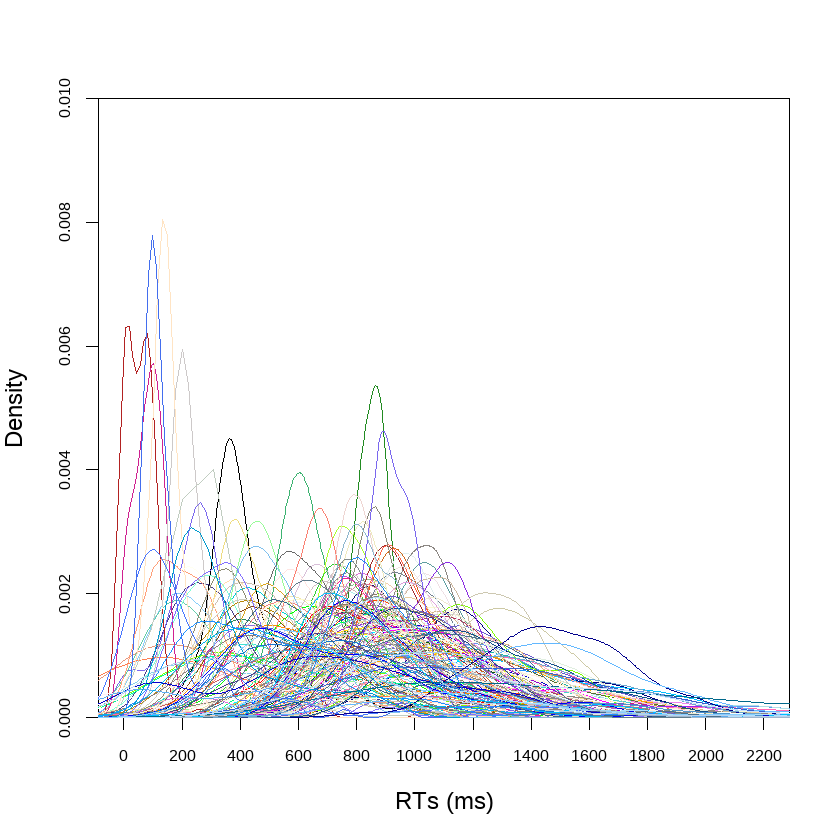

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    490    1102    1250    1502    1567   21759 

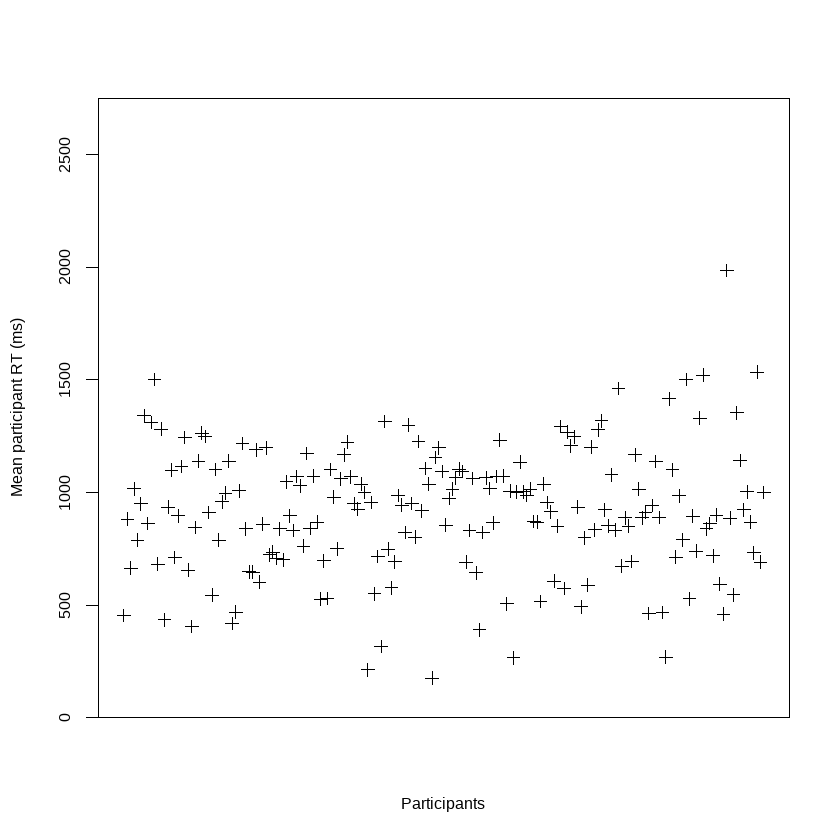

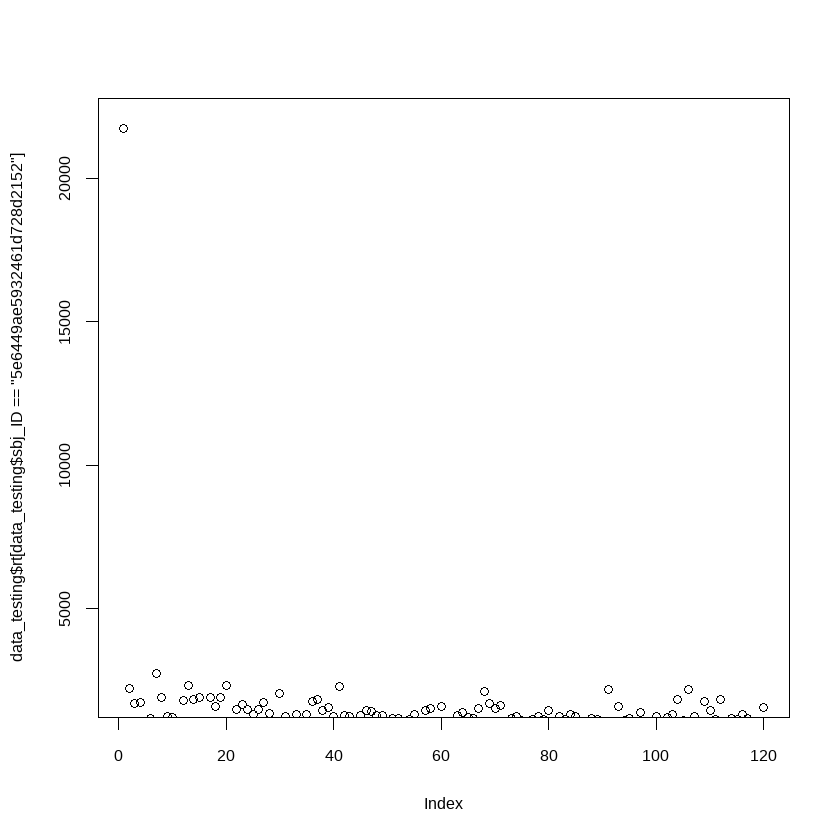

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    641    1034    1532    1986    2182   21398 

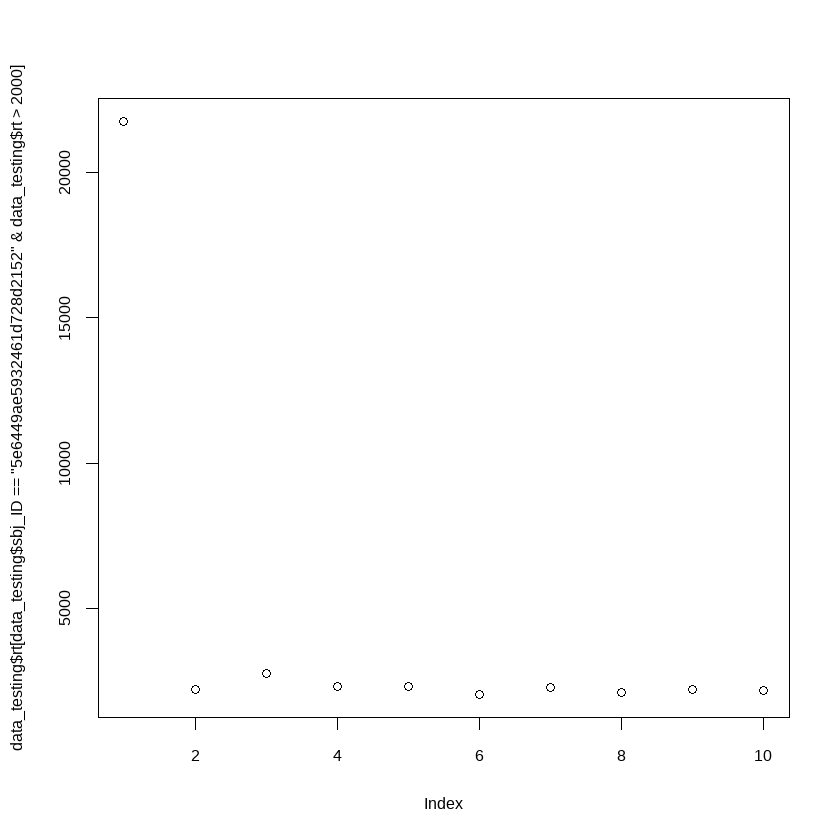

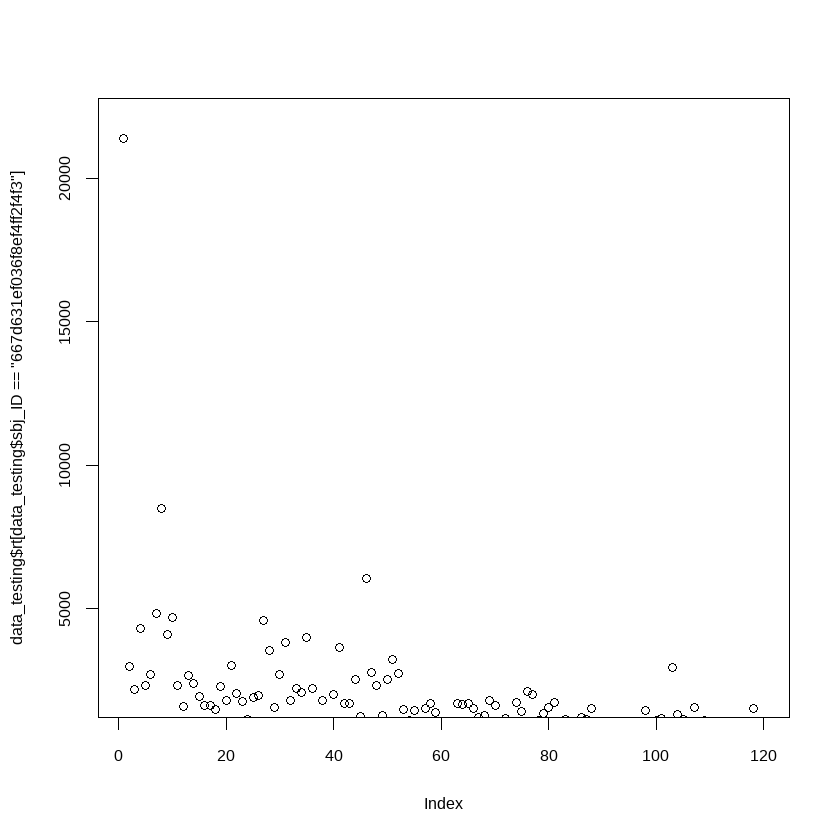

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   59.75  101.00  174.47  149.25 3474.00 

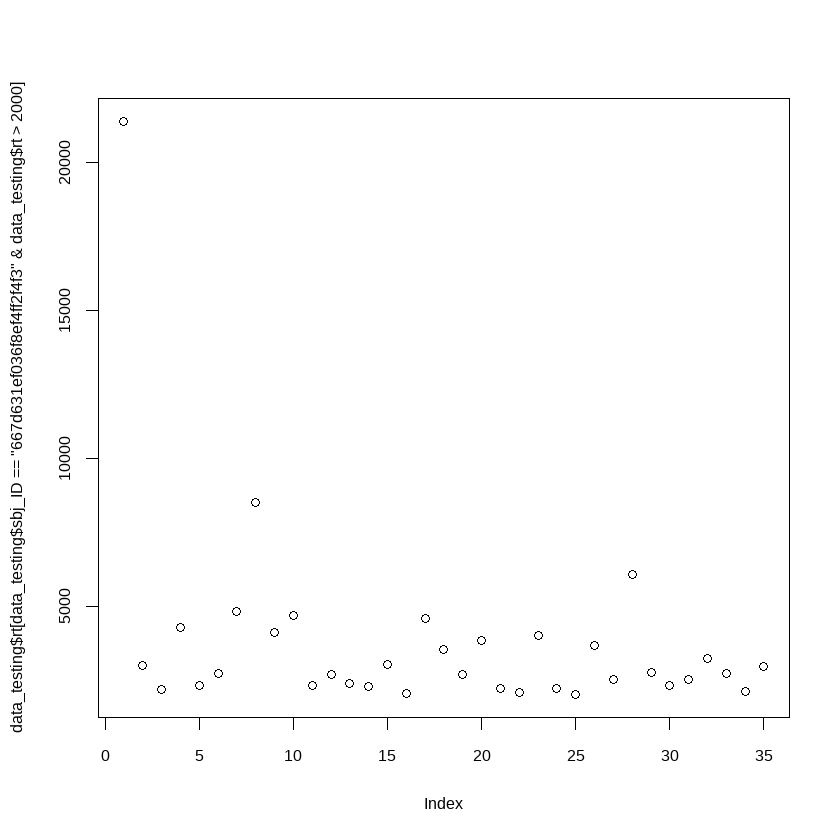

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  211.6   730.1   920.1   912.5  1092.6  1533.9 

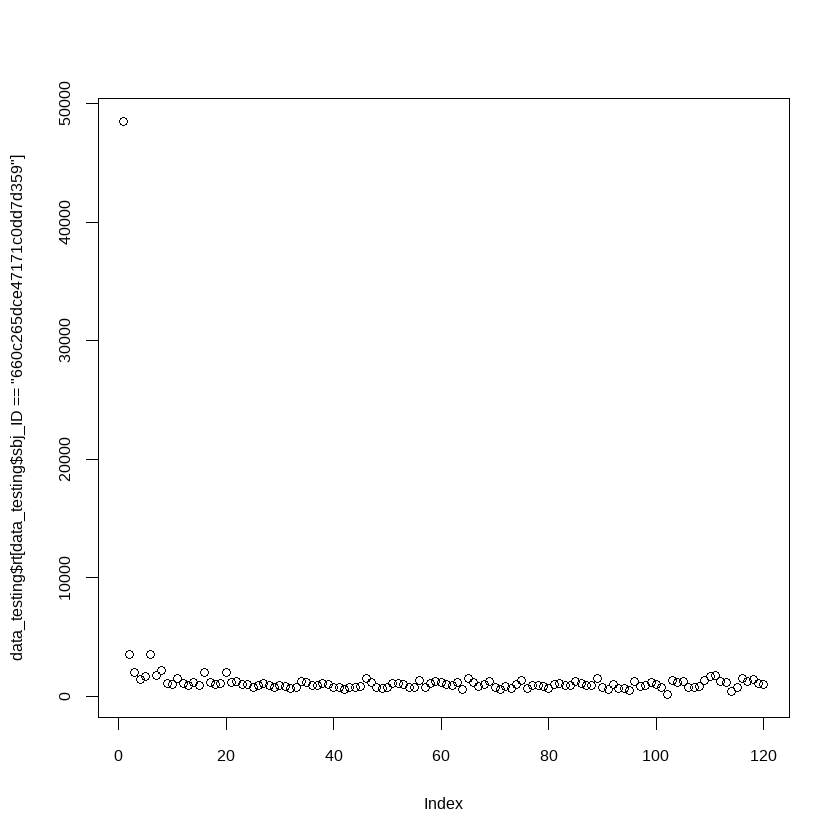

In [174]:
IDs <- list(data_testing$sbj_ID);
IDs <- sapply(IDs, unique);
plot(density(data_testing$rt[data_testing$sbj_ID==IDs[1]],na.rm=TRUE),xlim=c(0,2200),ylim=c(0,0.01),xlab="RTs (ms)",main="",xaxt = "n",col=cols2[27],yaxs="i",lwd=1,cex.lab=1.5);
axis(1, at = c(0,200,400,600,800,1000,1200,1400,1600,1800,2000,2200));
for (x in 2:190) {
  lines(density(data_testing$rt[data_testing$sbj_ID==IDs[x]],na.rm=TRUE),col=cols2[x+26],lwd=1)
}; # good, centered around 800ms
data_testing_rt_means <- aggregate(data_testing$rt, list(data_testing$sbj_ID), FUN=mean, na.rm=TRUE);
summary(data_testing_rt_means$x); # good med & mean
plot(data_testing_rt_means$x, ylab="Mean participant RT (ms)",xlab="Participants",main="",xaxt = "n",pch=3,yaxs="i",ylim=c(0,2750))
# looks healthy overall

## problematic participant RTs ##
summary(data_testing$rt[data_testing$sbj_ID=="5e6449ae5932461d728d2152"]);
plot(data_testing$rt[data_testing$sbj_ID=="5e6449ae5932461d728d2152"],ylim=c(2000,22000));
plot(data_testing$rt[data_testing$sbj_ID=="5e6449ae5932461d728d2152"&data_testing$rt>2000]);
# include 5e6449ae5932461d728d2152: mean RT of 1502 slow, but only 10 trials too slow

summary(data_testing$rt[data_testing$sbj_ID=="667d631ef036f8ef4ff2f4f3"]);
plot(data_testing$rt[data_testing$sbj_ID=="667d631ef036f8ef4ff2f4f3"],ylim=c(2000,22000));
plot(data_testing$rt[data_testing$sbj_ID=="667d631ef036f8ef4ff2f4f3"&data_testing$rt>2000]);
# exclude 667d631ef036f8ef4ff2f4f3: mean RT of 1986 slow, and 35 trials too slow
data_testing <- data_testing[!data_testing$sbj_ID %in% c('667d631ef036f8ef4ff2f4f3'),];
data_testing_rt_means <- data_testing_rt_means[!data_testing_rt_means$Group.1 %in% c('667d631ef036f8ef4ff2f4f3'),]
# now n=189

summary(data_testing$rt[data_testing$sbj_ID=="6488afe97766c9083ffc3171"]);
# exclude 6488afe97766c9083ffc3171: mean RT of 175ms too fast
data_testing <- data_testing[!data_testing$sbj_ID %in% c('6488afe97766c9083ffc3171'),];
data_testing_rt_means <- data_testing_rt_means[!data_testing_rt_means$Group.1 %in% c('6488afe97766c9083ffc3171'),]
# now n=188

plot(data_testing$rt[data_testing$sbj_ID=="660c265dce47171c0dd7d359"]);
#fine to include: very long with the first item (50s!) but others all around 1s afterwards

summary(data_testing_rt_means$x);
#min:212 Q1:730 med:922 mean:915 Q3:1093 max:1534

## Testing Responses

In [175]:
mean_yes <- aggregate(data_testing$observed,by=list(data_testing$sbj_ID), FUN=function(x) sum(x == 'within_lang'));
names(mean_yes) <- c("sbj_ID", "yes");
summary(mean_yes$yes);
#min:0 Q1:61 med:68 mean:70 Q3:79 max:120
#never said "yes": 660310c1b1a7ea09dee682e2
#always said "yes": 5faacca24cd0384c1fa08be1, 65f7be6ac59662b24ac0f9b0, 664b7cd6b5a772dd1eddca37
data_testing <- data_testing[!data_testing$sbj_ID %in% c('660310c1b1a7ea09dee682e2','5faacca24cd0384c1fa08be1','65f7be6ac59662b24ac0f9b0','664b7cd6b5a772dd1eddca37'),];
data_testing_rt_means <- data_testing_rt_means[!data_testing_rt_means$Group.1 %in% c('660310c1b1a7ea09dee682e2','5faacca24cd0384c1fa08be1','65f7be6ac59662b24ac0f9b0','664b7cd6b5a772dd1eddca37'),]
# now n=184

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   61.00   68.00   69.77   79.00  120.00 

### 0M Responses

In [176]:
data_testing_0M_yes <- aggregate(data_testing$observed[data_testing$testing_condition=='0M'], by=list(data_testing$sbj_ID[data_testing$testing_condition=='0M']), FUN = function(x) sum(x == 'within_lang'));
names(data_testing_0M_yes) <- c("sbj_ID","yes_0M");
data_testing_0M_yes$yes_0M <- data_testing_0M_yes$yes_0M/40*100; #transform into percent
summary(data_testing_0M_yes$yes_0M);
#min:7.5 Q1:42.5 med:52.5 mean:52.3 Q3:62.5 max:87.5
t.test(data_testing_0M_yes$yes_0M, mu=50);
#t=1.944 p=0.053 df=183 CI=[49.97;54.54] est=52.26 -> 0M "yes" not sig above chance
data_testing <- merge(data_testing,data_testing_0M_yes,by="sbj_ID");

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   7.50   42.50   52.50   52.26   62.50   87.50 


	One Sample t-test

data:  data_testing_0M_yes$yes_0M
t = 1.9448, df = 183, p-value = 0.05334
alternative hypothesis: true mean is not equal to 50
95 percent confidence interval:
 49.96725 54.54362
sample estimates:
mean of x 
 52.25543 


### 1M Responses

In [177]:
data_testing_1M_yes <- aggregate(data_testing$observed[data_testing$testing_condition=='1M'], by=list(data_testing$sbj_ID[data_testing$testing_condition=='1M']), FUN = function(x) sum(x == 'within_lang'));
names(data_testing_1M_yes) <- c("sbj_ID","yes_1M");
data_testing_1M_yes$yes_1M <- data_testing_1M_yes$yes_1M/40*100; #transform into percent
summary(data_testing_1M_yes$yes_1M);
#min:18 Q1:50 med:57.5 mean:58.0 Q3:67.5 max:90
t.test(data_testing_1M_yes$yes_1M, mu=50);
#t=8.15 p=5.65e-14 CI=[56.06;59.94] est=58.00 -> sig above chance
data_testing <- merge(data_testing,data_testing_1M_yes,by="sbj_ID");

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   17.5    50.0    57.5    58.0    67.5    90.0 


	One Sample t-test

data:  data_testing_1M_yes$yes_1M
t = 8.1476, df = 183, p-value = 5.65e-14
alternative hypothesis: true mean is not equal to 50
95 percent confidence interval:
 56.06480 59.94063
sample estimates:
mean of x 
 58.00272 


### 2M Responses

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  30.00   52.50   62.50   63.07   72.50   95.00 


	One Sample t-test

data:  data_testing_2M_yes$yes_2M
t = 12.443, df = 183, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 50
95 percent confidence interval:
 60.99818 65.14313
sample estimates:
mean of x 
 63.07065 


`summarise()` has grouped output by 'expected'. You can override using the `.groups` argument.


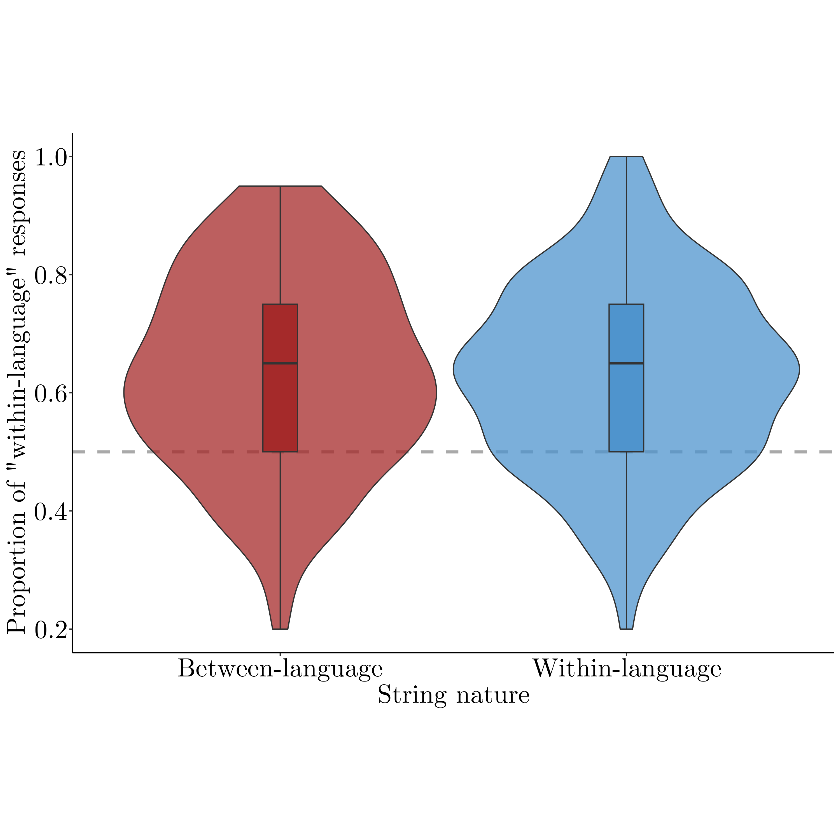

In [178]:
data_testing_2M_yes <- aggregate(data_testing$observed[data_testing$testing_condition=='2M'], by=list(data_testing$sbj_ID[data_testing$testing_condition=='2M']), FUN = function(x) sum(x == 'within_lang'));
names(data_testing_2M_yes) <- c("sbj_ID","yes_2M");
data_testing_2M_yes$yes_2M <- data_testing_2M_yes$yes_2M/40*100; #transform into percent
summary(data_testing_2M_yes$yes_2M);
#min:30 Q1:52.5 med:62.5 mean:63.1 Q3:72.5 max:95
t.test(data_testing_2M_yes$yes_2M, mu=50);
#t=12.44 df=183 p<2.2-16 CI=[61.00;65.14] est=63.07 -> sig above chance
data_testing <- merge(data_testing,data_testing_2M_yes,by="sbj_ID");

data_testing_2M_aggr <- data_testing %>% 
  mutate(correct01 = case_when(correct == TRUE ~ 1,
                               correct == FALSE ~ 0),
         yesno01 = case_when(observed == 'between_lang' ~ 0,
                             observed == 'within_lang' ~ 1)) %>% 
  filter(testing_condition == '2M') %>% 
  group_by(expected, sbj_ID) %>% 
  dplyr::summarise(meanCorrect = mean(correct01), se = sd(correct01/sqrt(n())),
                   meanYes = mean(yesno01), se = sd(yesno01/sqrt(n()))) %>% 
  mutate(meanNo = 1 - meanYes);

data_testing_2M_aggr <- data_testing_2M_aggr %>%
  pivot_longer(
    cols = c(meanYes, meanNo),
    names_to = "response",
    values_to = "meanValue"
  );

data_testing_2M_aggr$response <- as.factor(data_testing_2M_aggr$response);

ggplot(data_testing_2M_aggr[ which(data_testing_2M_aggr$response=='meanYes'),], aes(x=expected, y=meanValue, fill=expected)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,width=1) +
  geom_boxplot(width=0.1,position=position_dodge(width=1)) +
  scale_fill_manual(values=c(cols2[100],cols2[200]),
                    name="Participant response",labels=c("Between-language","Within-language")) +
  scale_x_discrete(labels=c('Between-language', 'Within-language')) +
  labs(x = "String nature", y = 'Proportion of "within-language" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="none",
        legend.background=element_rect(fill=NA));

### 2M Scores

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2250  0.4500  0.5000  0.4954  0.5500  0.7000 

[1] 0.005982641

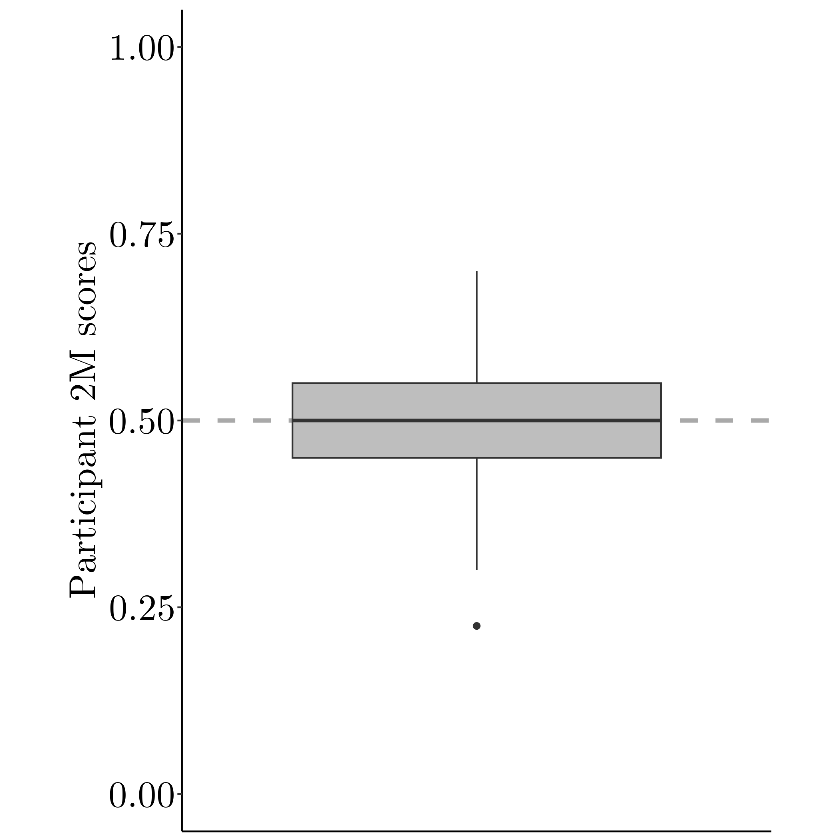

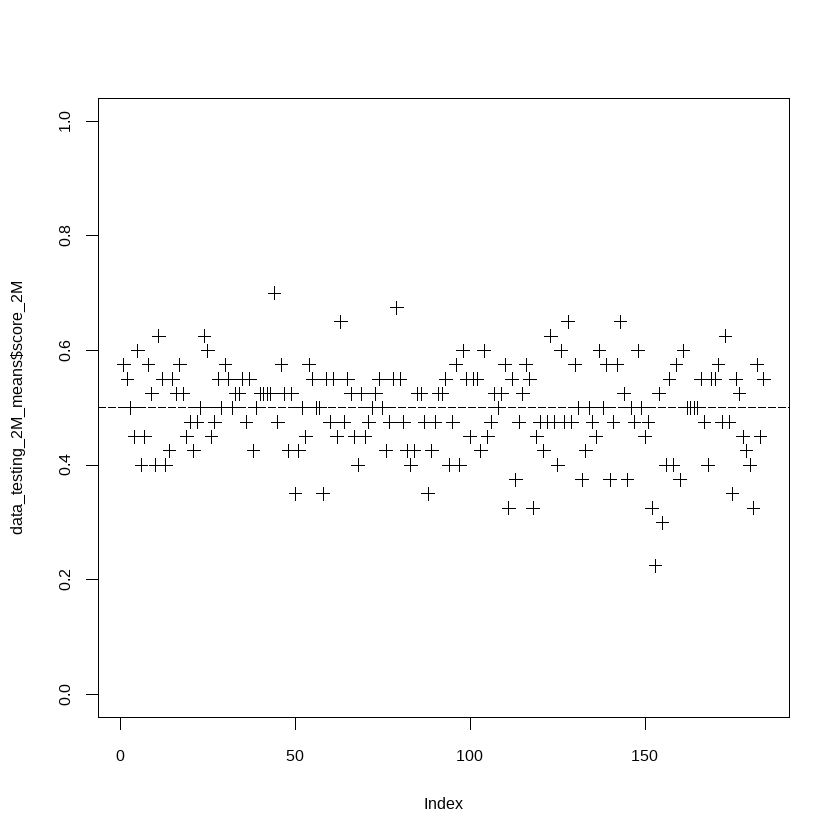


	One Sample t-test

data:  data_testing_2M_means$score_2M
t = -0.81015, df = 183, p-value = 0.4189
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.4841301 0.5066308
sample estimates:
mean of x 
0.4953804 


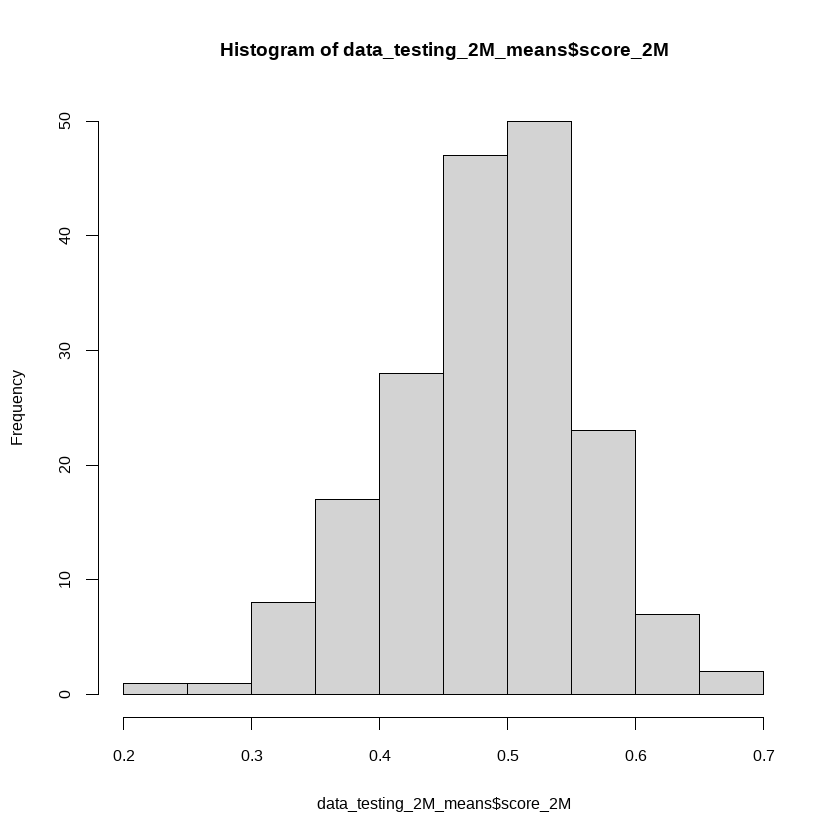

In [179]:
data_testing_2M_means <- aggregate(data_testing$correct[data_testing$testing_condition=='2M'], list(data_testing$sbj_ID[data_testing$testing_condition=='2M']), FUN=mean, na.rm=TRUE);
names(data_testing_2M_means) <- c("sbj_ID","score_2M");

ggplot(data_testing_2M_means, aes(x="", y=score_2M)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_boxplot(fill="grey") +
  ylim(0,1) +
  labs(y='Participant 2M scores') +
  theme(axis.title.x=element_blank(),axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

summary(data_testing_2M_means$score_2M);
#min:0.23 Q1:0.45 med:0.5 mean:0.50 Q3:0.55 max:0.7
var(data_testing_2M_means$score_2M); #var=0.006
plot(data_testing_2M_means$score_2M,pch=3,ylim=c(0,1));
abline(h=0.5, lty=5); # clustered around chance
hist(data_testing_2M_means$score_2M); # normally distributed
t.test(data_testing_2M_means$score_2M, mu=0.50);
#t=-0.81 p=0.42 df=183 CI=[0.48;0.51] est=0.50 -> not sig different from chance
data_testing <- merge(data_testing,data_testing_2M_means,by="sbj_ID");

### d' Computations

In [180]:
data_testing_2M <- data_testing[data_testing$testing_condition == '2M',];

data_testing_2M$expected_bi[data_testing_2M$expected == "between_lang"] <- 0;
data_testing_2M$expected_bi[data_testing_2M$expected == "within_lang"] <- 1;
data_testing_2M$observed_bi[data_testing_2M$observed == "between_lang"] <- 0;
data_testing_2M$observed_bi[data_testing_2M$observed == "within_lang"] <- 1;

dprimes2M <- dPrime(data_testing_2M$sbj_ID, data_testing_2M$expected_bi, data_testing_2M$observed_bi);
names(dprimes2M) <- c("sbj_ID","dprime","log_beta","c");
summary(dprimes2M);
# mean(d') = -0.03, mean(c) = -0.35
data_testing <- merge(data_testing,dprimes2M,by="sbj_ID");
cor.test(data_testing$dprime,data_testing$c, method="pearson"); 
# t=4.32 df=22078 p=1.53e-5 CI=[0.02;0.04] est=0.03
# significant but tiny positive correlation
# more "YES" responses doesn't help you respond accurately

    sbj_ID              dprime           log_beta              c          
 Length:184         Min.   :-1.7060   Min.   :-1.26600   Min.   :-1.5800  
 Class :character   1st Qu.:-0.2745   1st Qu.:-0.06700   1st Qu.:-0.5790  
 Mode  :character   Median : 0.0000   Median : 0.00000   Median :-0.3080  
                    Mean   :-0.0255   Mean   : 0.01408   Mean   :-0.3541  
                    3rd Qu.: 0.2710   3rd Qu.: 0.08375   3rd Qu.:-0.0600  
                    Max.   : 0.9940   Max.   : 1.04400   Max.   : 0.5020  


	Pearson's product-moment correlation

data:  data_testing$dprime and data_testing$c
t = 4.3249, df = 22078, p-value = 1.533e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.01591042 0.04226858
sample estimates:
       cor 
0.02909456 


### "Yes" Responses across Conditions 


	Pearson's Chi-squared test

data:  conditions_table
X-squared = 176.68, df = 2, p-value < 2.2e-16



	Pearson's product-moment correlation

data:  data_testing_2M_means$score_2M and data_testing_rt_means$x
t = 1.2668, df = 182, p-value = 0.2068
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.05186913  0.23497640
sample estimates:
       cor 
0.09349341 


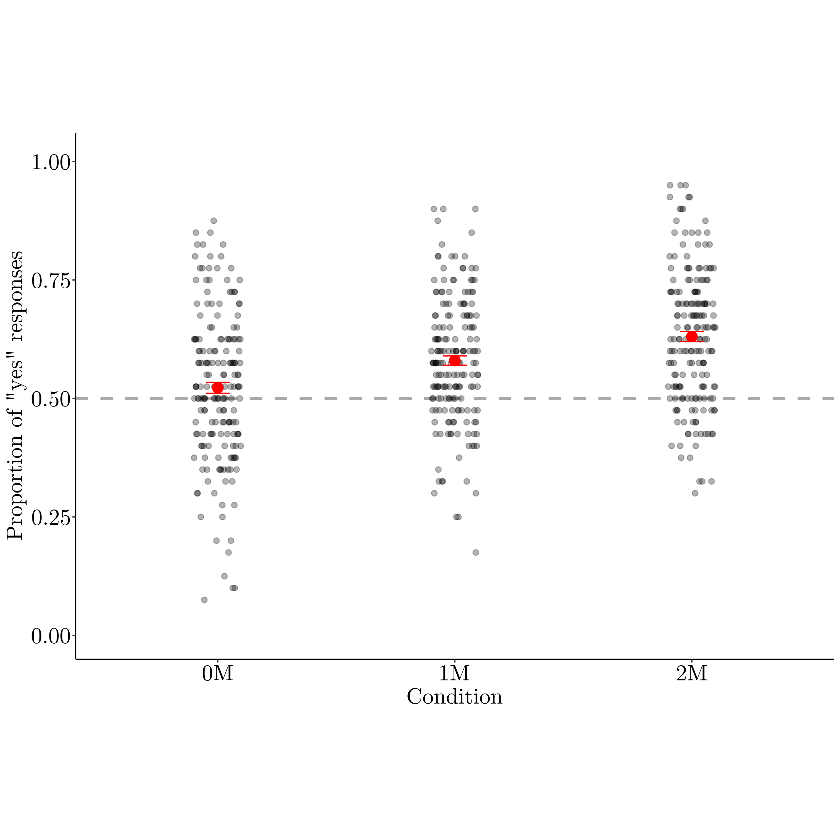

In [181]:
# evaluating the differences between conditions
data_testing_conditions <- merge(data_testing_0M_yes,data_testing_1M_yes, by='sbj_ID');
data_testing_conditions <- merge(data_testing_conditions,data_testing_2M_yes, by='sbj_ID');
conditions_table <- table(data_testing$testing_condition, data_testing$observed);
chisq.test(conditions_table);
# X-squared=177, df=2, p<2.2e-16
data_testing_conditions <- data_testing_conditions %>%
  gather(condition, score, -sbj_ID);
data_testing_conditions$score <- data_testing_conditions$score/100;

# plotting all "yes" responses across conditions
ggplot(data_testing_conditions, aes(x = condition, y = score, color = condition)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_jitter(width = 0.1, height = 0, alpha = 0.3,color= "black",size=2) +
  labs(x = "Condition", y = 'Proportion of "yes" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20)) +
  ylim(0,1.01) +
  stat_summary(geom = "point",fun = "mean",col = "red",size = 4,shape = 19) +
  stat_summary(geom = "errorbar", fun.data = "mean_se", width = 0.1,col="red",position = position_dodge(width = 0.5)) +
  scale_x_discrete(labels=c("0M", "1M", "2M"));

# 2M accuracy*RTs
cor.test(data_testing_2M_means$score_2M, data_testing_rt_means$x, method="pearson"); # r = 0.04 ()
# t=1.27 df=182 p=0.21 CI=[-0.05;0.23] est=0.09
# non-significant correlation

## Strategies

In [182]:
strats <- subset(data_testing, select = c(sbj_ID, strategy));
strats <- strats[!duplicated(strats),];
write.csv(strats,"BASL_exp2_strats.csv", row.names = FALSE);

### Chunks

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3250  0.4250  0.5250  0.4938  0.5500  0.6500 


	One Sample t-test

data:  data_chunkIDstrategists$score_2M
t = -0.40935, df = 31, p-value = 0.6851
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.4626105 0.5248895
sample estimates:
mean of x 
  0.49375 


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.96700 -0.40400  0.12250  0.00675  0.32700  0.84800 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.5800 -0.6790 -0.4930 -0.4780 -0.1693  0.4560 

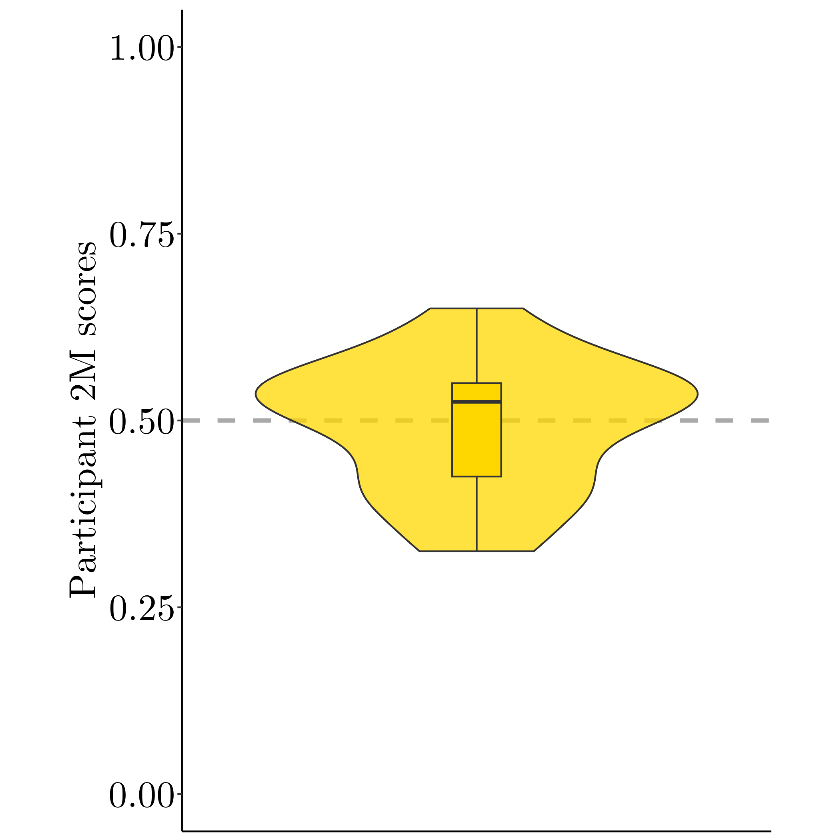

In [183]:
chunkID_strategists <- list('5ed14691e983f5067842fd20','5ef0b54037a90c618ad9e97f','602d2adcef81ce6b843da09b','6046435099c3d00becdb2dfb','6057a8fe2d302939fc759940','60bf28df4926a8b6391df575','60d26e7cd9f0761e4d12b9f8','60db9c9850c39eea109ef1d3','611d180283c1129def9284e6','6134d182408816f4c1284496','6136a1e1159dc808ad660d89','6148b49d6ac652cefd310332','6171946a19f6673fb215c0c7','628ed30ae7ff849e8bc91c86','631a1795de5efe7d3395caa3','63c5335da2b625ab1ade7e7c','6495a5f76daf70e418baf5f7','64e9d6f596308448ac67bb95','65361483b7f9881afa9b4cda','65672c69a3737224f1d0bbfa','65a97217d4fb858939a16b0f','65c23d4dbad7238169292b54','65dce7715387badaf80e875d','65e7259b24116547c5512668','660c265dce47171c0dd7d359','661c24ab06db7f1ff0146700','6634f754adfec54a4b1aaed4','664f70fcf77160132d600e2c','6661bf2ef4b2d0892ad7a007','666306b0bf2de127943c419f','668992b2f868cb89829346c2','6692b87aad65e83d4230c307');
data_chunkIDstrategists <- data_testing[data_testing$sbj_ID %in% chunkID_strategists,];
data_chunkIDstrategists <- data_chunkIDstrategists[data_chunkIDstrategists$testing_condition=='2M',];
data_chunkIDstrategists <- data_chunkIDstrategists[!duplicated(data_chunkIDstrategists$sbj_ID), ];
data_chunkIDstrategists$strat <- "chunkID";
summary(data_chunkIDstrategists$score_2M); 
# min:0.33 Q1:0.43 med:0.53 mean:0.49 Q3:0.55 max:0.65
t.test(data_chunkIDstrategists$score_2M, mu=0.50);
#t=-0.41 df=31 p=0.69 CI=[0.46;0.52] est=0.49 -> not sig different from chance
summary(data_chunkIDstrategists$dprime);
summary(data_chunkIDstrategists$c);
# dprime:0.01 c:-0.48

ggplot(data_chunkIDstrategists, aes(x="", y=score_2M)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,fill="gold1") +
  geom_boxplot(width=0.1,fill="gold1") +
  ylim(0,1) +
  labs(y='Participant 2M scores') +
  theme(axis.title.x=element_blank(),axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

### Intuition

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3000  0.4500  0.5000  0.4858  0.5250  0.6750 


	One Sample t-test

data:  data_intuitionstrategists$score_2M
t = -1.6932, df = 78, p-value = 0.0944
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.4690159 0.5025031
sample estimates:
mean of x 
0.4857595 


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-1.00400 -0.31600  0.00000 -0.07311  0.15400  0.87900 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-1.4650 -0.5160 -0.2490 -0.2935  0.0000  0.5020 

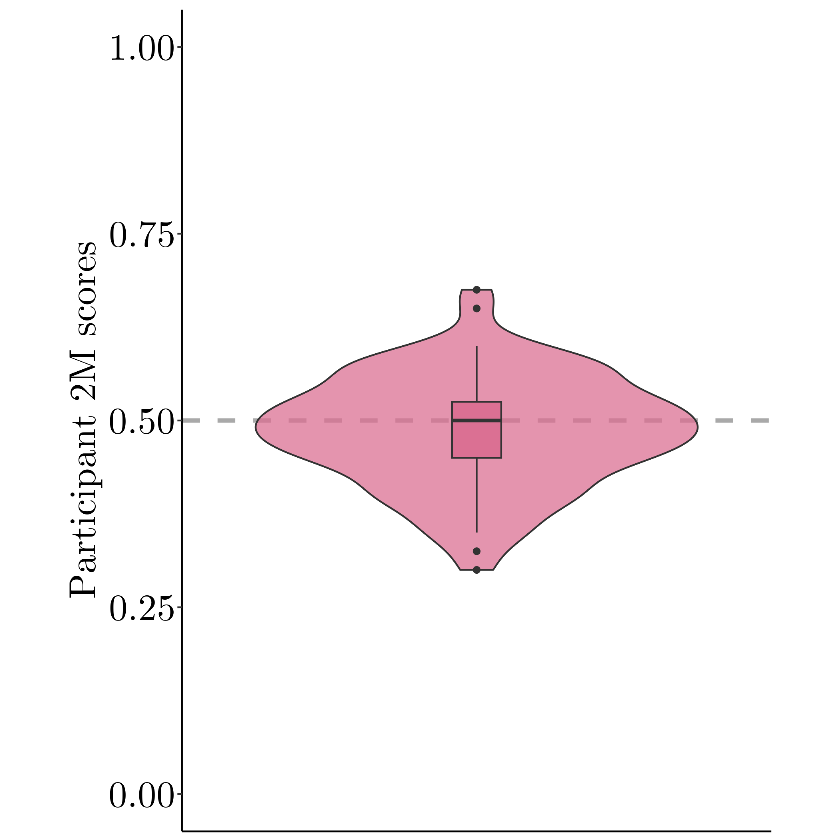

In [184]:
intuition_strategists <- list('579e18fc4a84da00014c6f4f','5c840aedbad8fb000106cb44','5d696d1c55742f001af29220','5e248b6f0c0b31718a9d3f31','5e2b03f0005f2a02c5a64f7b','5ebd8f8679146d0a116bc257','5eee55e93867d30a7771e616','5f1165307d03fb0009716b8e','5f21c29511084913913af654','5f35782429beab53ef93cc2d','5f6f3d061214fe49ec2b9619','5f8af153e27f001bcc23ffc4','5f8b724dc36e8c2ac6d5fb6e','5fade36bdde8092117469a42','5ffd4230d96f6b2649d31f72','60379326171365000ac6ae93','604d5e61486bd0622d2102c0','60907b8091341e8724ba80ed','60c873a65a9883b52f70db6c','60ca0b60979a23c83652c303','60d9dfd4dcc09cf57dc92cb1','60e586145b73b702a608bace','60e5ac4f3d93f294f5fa543b','60f9739250a5c6f6e4726336','6102ee48644f517877d64d2b','6106ac34408681f3b0d07396','610d45e26c9b141264755d3c','611e00dc377e4fb7a27725e8','61242dd5be1a06b174975a1f','61248a51eefb6797024ecb85','612cc44439ccefbbd5d4b278','613054cf8dffc8bbb1fc9cc4','613758e7a80409ba7f5affb6','613ca0a2040055a4e87c5d71','6166ef334de9e433e83bfb79','616ad7ac6299f99ce33cdc78','61717173748006894b2b54ff','6413799cf7721ee0ce637e09','646e0d2370c16a7561ae7dcb','649264e0b601af80c5677791','6492c23a1a7735dfaab2b095','6497e970e2621e753513a695','64e8bd55c9089d5bf26c90cd','64e8c14bbe184c20cb9d0583','64f7a35c5f6503caaa59f79f','6505a9adbb769aeea736a2f5','650aed9eb9cc2c717ba70c30','65352001dbe3e18eae5a8300','653fb764c9aed77c01457531','654632f222cb15acd453c0d3','65523123662559399b1aa48a','6557def45fc0ffbd46ad01de','655f5b404a09c686df3b0143','655f8b959477c803eb906622','657bfe6e245848c8fef0b389','6597e935328d41ae3aeef33b','6598994f0e7e5db183bfe3ee','659ada2d6df23a57d8e56752','65a97afe116a650acc588c5b','65b96f3bbecf5e7d0f5853cd','65cf6d92ac6f7932b1470fb4','65f33b94cd6885d54029582d','66031000461c44484ac359a8','6606c9d692990fbf223f63bb','66168e55cb60649609600268','661ff04db0e4a8222d5c4dd7','663e08a82c273a8ea28be4e7','664f48afa42c9a4a7ed2bb88','6659ca4701d47b95a09ba736','665f79d15be62c63a74883d6','6662d40766c8aa595834461d','6666cf176a54945ba62e8ca9','6667488c5f46f3da0c085419','6672ee650699d871b742ca6b','667dd7126e7a9073e0af73fd','6681625ff9dfa8a95bb0359d','66844cc1407c6afd0e100482','6693f13e028361f102a9ed86','66951e094b5bd0caf94e844f');
data_intuitionstrategists <- data_testing[data_testing$sbj_ID %in% intuition_strategists,];
data_intuitionstrategists <- data_intuitionstrategists[data_intuitionstrategists$testing_condition=='2M',];
data_intuitionstrategists <- data_intuitionstrategists[!duplicated(data_intuitionstrategists$sbj_ID), ];
data_intuitionstrategists$strat <- "intuition";
summary(data_intuitionstrategists$score_2M); 
# min:0.30 Q1:0.45 med:0.50 mean:0.49 Q3:0.53 max:0.68
t.test(data_intuitionstrategists$score_2M, mu=0.50);
#t=-1.69 df=78 p=0.09 CI=[0.47;0.50] -> not sig different from chance
summary(data_intuitionstrategists$dprime);
summary(data_intuitionstrategists$c);
# dprime:-0.07 c:-0.29

ggplot(data_intuitionstrategists, aes(x="", y=score_2M)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,fill="palevioletred") +
  geom_boxplot(width=0.1,fill="palevioletred") +
  ylim(0,1) +
  labs(y='Participant 2M scores') +
  theme(axis.title.x=element_blank(),axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

### Comparison

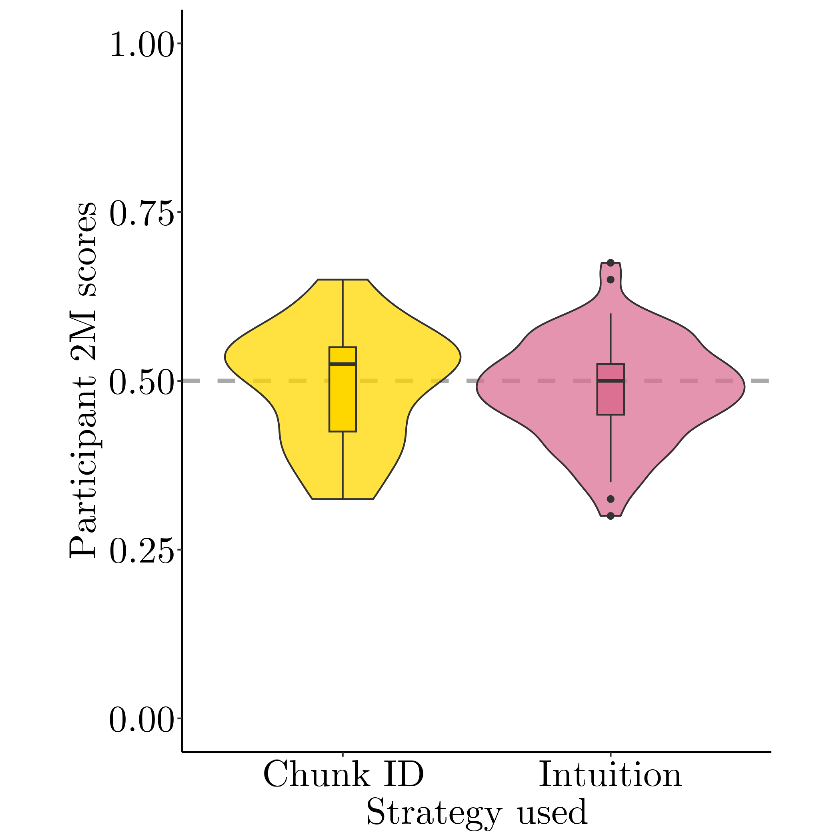

In [185]:
scores_strategies <- rbind(data_chunkIDstrategists,data_intuitionstrategists);

ggplot(scores_strategies, aes(x=strat, y=score_2M, fill=strat)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,width=1) +
  geom_boxplot(width=0.1,position=position_dodge(width=1)) +
  ylim(0,1) +
  scale_fill_manual(values=c("gold1","palevioletred")) +
  scale_x_discrete(labels=c('Chunk ID', 'Intuition')) +
  labs(x="Strategy used",y="Participant 2M scores") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="none",legend.background=element_rect(fill=NA));

# FAMILIARITY

In [186]:
data_all_familiarity <- read.csv("exp2_familiarity_preprocessed.csv",header=T,sep=",");
data_all_familiarity <- subset(data_all_familiarity, select = -c(X)) # remove redundant column added by Pavlovia
data_familiarity <- data_all_familiarity[data_all_familiarity$sbj_ID %in% participants,]; # n = 187 participants
data_familiarity <- data_familiarity[!data_familiarity$sbj_ID %in% c('667d631ef036f8ef4ff2f4f3','6488afe97766c9083ffc3171','666f0fb7d9900bb03f5d99a1','660310c1b1a7ea09dee682e2','5faacca24cd0384c1fa08be1', '65f7be6ac59662b24ac0f9b0', '664b7cd6b5a772dd1eddca37'),];

# make some variables factors
data_familiarity$sbj_ID <- as.factor(data_familiarity$sbj_ID);
data_familiarity$task <- as.factor(data_familiarity$task);
data_familiarity$correct <- as.logical(data_familiarity$correct);
data_familiarity$target <- as.factor(data_familiarity$target);
data_familiarity$confound <- as.factor(data_familiarity$confound);

## Familiarity Accuracy

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3667  0.5000  0.5667  0.5737  0.6333  0.9333 


	One Sample t-test

data:  data_familiarity_means$fam_mean
t = 10.196, df = 183, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.5594642 0.5879995
sample estimates:
mean of x 
0.5737319 


[1] 0.009621941

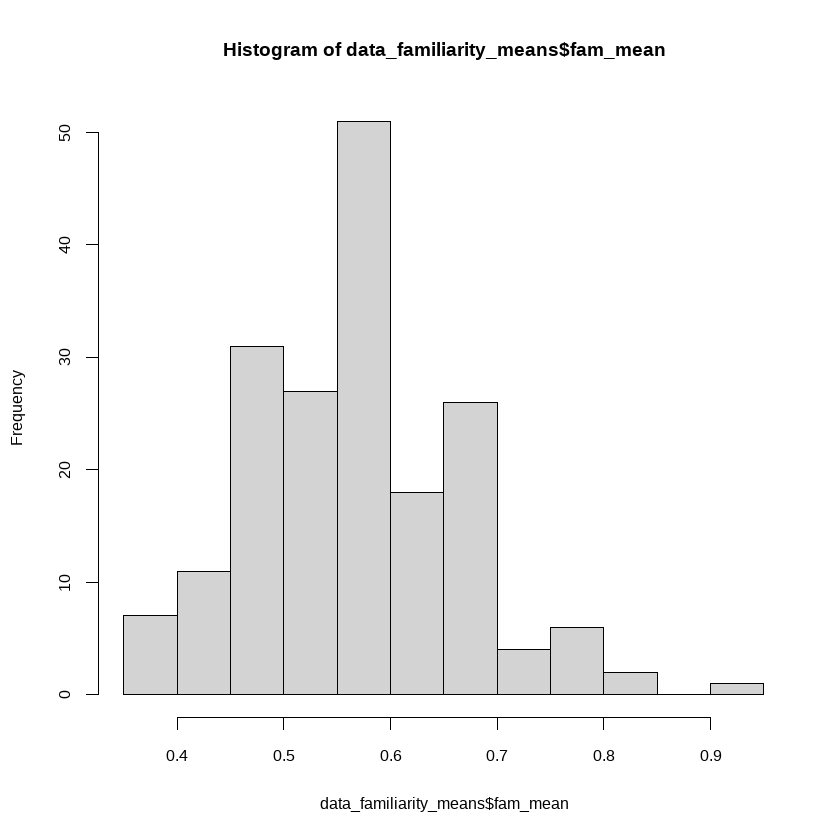

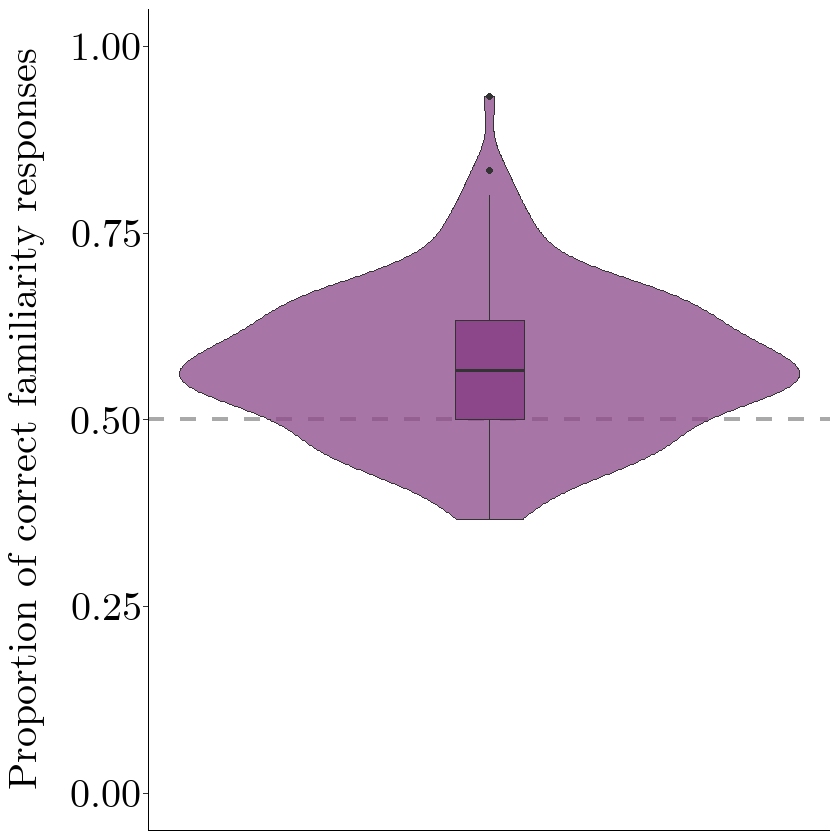

In [187]:
data_familiarity_means <- aggregate(data_familiarity$correct, list(data_familiarity$sbj_ID), FUN=mean);
colnames(data_familiarity_means)[colnames(data_familiarity_means)=="Group.1"]="sbj_ID";
colnames(data_familiarity_means)[colnames(data_familiarity_means)=="x"]="fam_mean";
summary(data_familiarity_means$fam_mean);
# min:0.37 Q1:0.50 med:0.57 mean:0.57 Q3:0.63 max:0.93
hist(data_familiarity_means$fam_mean); # mostly normally distributed
t.test(data_familiarity_means$fam_mean, mu=0.50);
# t=10.20 df=183 p<2.2e-16 CI=[0.56;0.59] est=0.57 -> sig above chance
var(data_familiarity_means$fam_mean); # var = 0.01
data_familiarity <- merge(data_familiarity,data_familiarity_means,by="sbj_ID");

# familiarity accuracy violin plot
ggplot(data_familiarity_means, aes(y=fam_mean, x=x)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_violin(alpha=0.75,fill="orchid4") +
  geom_boxplot(width=0.1,fill="orchid4") +
  ylim(0,1) +
  scale_fill_manual(values=cols2[350]) +
  labs(y = 'Proportion of correct familiarity responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),legend.position = "none",
        axis.title.x=element_blank(),axis.text.x=element_blank(),
        axis.ticks.x=element_blank());

## Familiarity RTs

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  153.5  1212.5  1655.0  1681.2  1982.0  4519.3 


	Pearson's product-moment correlation

data:  data_familiarity_means$fam_mean and data_familiarity_rt_means$x
t = 4.3115, df = 182, p-value = 2.653e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1671181 0.4301383
sample estimates:
      cor 
0.3044196 


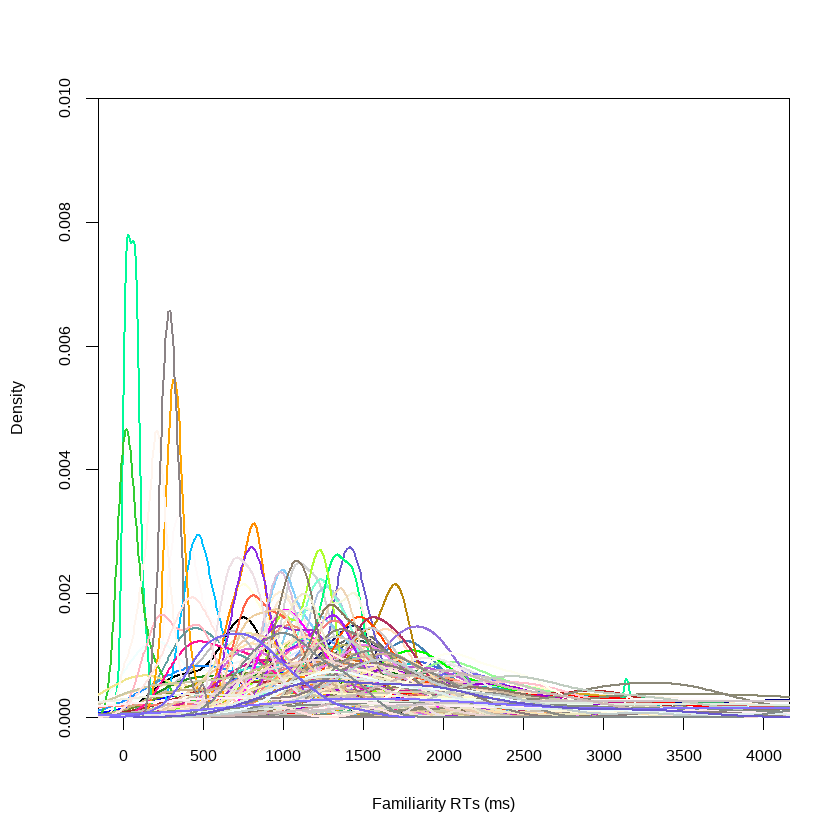

In [188]:
IDs <- list(data_familiarity$sbj_ID);
IDs <- sapply(IDs, unique);
plot(density(data_familiarity$rt[data_familiarity$sbj_ID==IDs[1]]),xlim=c(0,4000),ylim=c(0,0.01),xlab="Familiarity RTs (ms)",main="",xaxt = "n",col=cols2[1],lwd=2,yaxs="i");
axis(1, at = c(0,500,1000,1500,2000,2500,3000,3500,4000));
for (x in 2:184) {
  lines(density(data_familiarity$rt[data_familiarity$sbj_ID==IDs[x]]),col=cols2[x],lwd=2)
};
data_familiarity_rt_means <- aggregate(data_familiarity$rt, list(data_familiarity$sbj_ID), FUN=mean, na.rm=TRUE);
summary(data_familiarity_rt_means$x);
#min:154 Q1:1213 med:1655 mean:1681 Q3:1982 max:4519

# familiarity accuracy*RTs
cor.test(data_familiarity_means$fam_mean, data_familiarity_rt_means$x, method="pearson") # r = 0.20
# t=4.31 df=182 p=2.65e-5 CI=[0.17;0.43] est=0.30
# slower at responding = better accuracy

## Comparisons with Testing


	Pearson's product-moment correlation

data:  data_familiarity_means$fam_mean and data_testing_2M_means$score_2M
t = 0.26893, df = 182, p-value = 0.7883
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1250914  0.1641181
sample estimates:
       cor 
0.01993027 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3667  0.5333  0.6000  0.6000  0.6333  0.9333 


	One Sample t-test

data:  data_strategistsfam$fam_mean[data_strategistsfam$strat == "chunks"]
t = 4.8729, df = 31, p-value = 3.091e-05
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.5581454 0.6418546
sample estimates:
mean of x 
      0.6 


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3667  0.5000  0.5667  0.5688  0.6333  0.8333 


	One Sample t-test

data:  data_strategistsfam$fam_mean[data_strategistsfam$strat == "intuition"]
t = 6.4391, df = 78, p-value = 9e-09
alternative hypothesis: true mean is not equal to 0.5
95 percent confidence interval:
 0.5475122 0.5900406
sample estimates:
mean of x 
0.5687764 


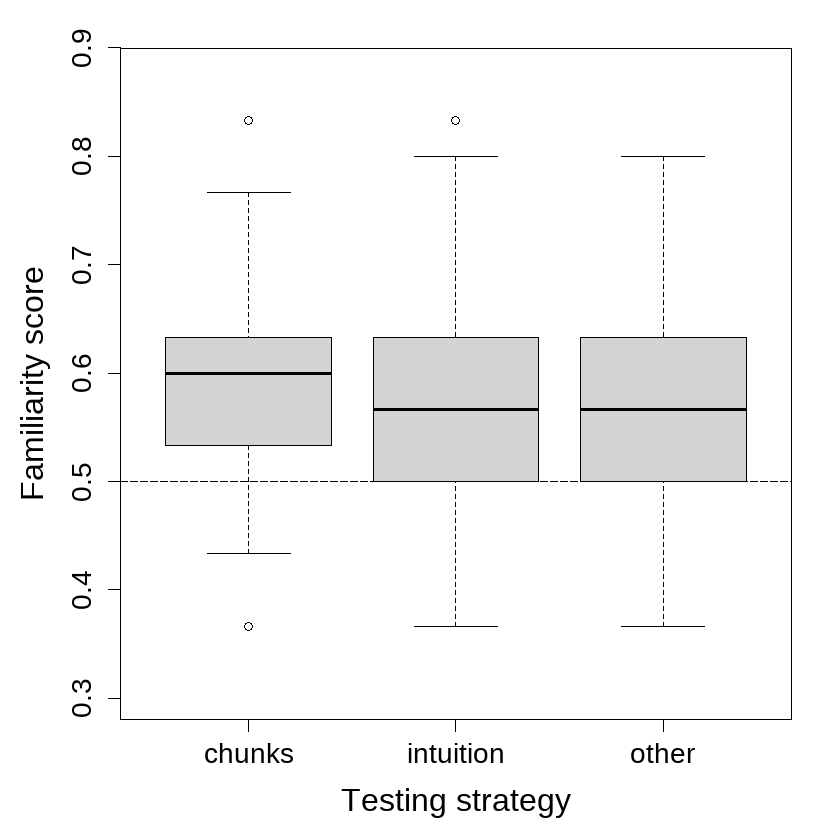

In [189]:
# familiarity accuracy*testing accuracy
cor.test(data_familiarity_means$fam_mean, data_testing_2M_means$score_2M, method="pearson"); # r = 0.11
# t=0.27 df=182 p=0.79 CI=[-0.13;0.16] est=0.02
# no correlation

# familiarity accuracy by testing strategy
data_strategistsfam <- data_familiarity_means;
data_strategistsfam$strat[data_strategistsfam$sbj_ID %in% intuition_strategists] <- 'intuition';
data_strategistsfam$strat[data_strategistsfam$sbj_ID %in% chunkID_strategists] <- 'chunks';
data_strategistsfam$strat[data_strategistsfam$sbj_ID %in% chunkID_strategists] <- 'chunks';
data_strategistsfam$strat <- data_strategistsfam$strat %>% replace_na('other');

summary(data_strategistsfam$fam_mean[data_strategistsfam$strat=='chunks']);
# min:0.37 Q1:0.53 med:0.60 mean:0.60 Q3:0.63 max:0.93
t.test(data_strategistsfam$fam_mean[data_strategistsfam$strat=='chunks'],mu=0.50);
#t=4.87 df=31 p=3.10e-5 CI=[0.56;0.64] est=0.60 -> sig above chance

summary(data_strategistsfam$fam_mean[data_strategistsfam$strat=='intuition']);
# min:0.37 Q1:0.50 med:0.57 mean:0.57 Q3:0.63 max:0.83
t.test(data_strategistsfam$fam_mean[data_strategistsfam$strat=='intuition'],mu=0.50);
#t=6.44 df=78 p=9e-9 CI=[0.55;0.59] est=0.57 -> sig above chance

par(mar=c(5,5,2,2));
boxplot(data_strategistsfam$fam_mean~data_strategistsfam$strat,ylab = "Familiarity score",xlab="Testing strategy",ylim=c(0.28,0.9),cex.lab=2,cex.axis=1.75,yaxs="i");
abline(h=0.5, lty=5);
par(mar=c(5, 4, 4, 2) + 0.1); # back to default

# BLP

In [191]:
data_all_BLP <- read.csv("exp2_BLP_preprocessed.csv",header=T,sep=",");
data_all_BLP <- subset(data_all_BLP, select = -c(X)); # remove redundant column added by Pavlovia
data_BLP <- data_all_BLP[data_all_BLP$sbj_ID %in% participants,]; # n = 190 participants
data_BLP <- data_BLP[!data_BLP$sbj_ID %in% c('667d631ef036f8ef4ff2f4f3','6488afe97766c9083ffc3171','666f0fb7d9900bb03f5d99a1','660310c1b1a7ea09dee682e2','5faacca24cd0384c1fa08be1', '65f7be6ac59662b24ac0f9b0', '664b7cd6b5a772dd1eddca37'),];

BLP_correction <- function(data_BLP)
{
  data_BLP[data_BLP == "polish"] <- "Polish";
  data_BLP[data_BLP == "english"|data_BLP=="English "|data_BLP=="ENGLISH"|data_BLP=="Englsih"|data_BLP=="Englsh"|data_BLP=="British"|data_BLP=="Engllish"|data_BLP=="ENGLISH "] <- "English";
  data_BLP[data_BLP == "portuguese"|data_BLP=="Potuguese"] <- "Portuguese";
  data_BLP[data_BLP =="SPANISH"|data_BLP=="Spnsh"|data_BLP=="spanish"] <- "Spanish";
  data_BLP[data_BLP == "ITALIAN"|data_BLP=="italian"] <- "Italian";
  data_BLP[data_BLP == "sotho"] <- "Sotho";
  data_BLP[data_BLP == "Gree"|data_BLP=="GREEK"] <- "Greek";
  data_BLP[data_BLP == "tshivenda"] <- "Tshivenda";
  data_BLP[data_BLP == "Gujrau"] <- "Gujarati"; # to check
  data_BLP[data_BLP == "ukrainian"|data_BLP=="ukranian"] <- "Ukrainian";
  data_BLP[data_BLP == "SETSWANA"] <- "Setswana";
  data_BLP[data_BLP == "afrikaans"] <- "Afrikaans";
  data_BLP[data_BLP == "punjabi"] <- "Punjabi";
  data_BLP[data_BLP == "siswati"] <- "Siswati";
  data_BLP[data_BLP == "Germany"|data_BLP=="german"|data_BLP=="germany"|data_BLP=="GERMANY"] <- "German";
  data_BLP[data_BLP == "russian"] <- "Russian";
  data_BLP[data_BLP == "Isiulu"] <- "IsiZulu";
  data_BLP[data_BLP == "ZULU"|data_BLP=="zulu"] <- "Zulu";
  data_BLP[data_BLP == "northern sotho"] <- "Northern Sotho";
  data_BLP[data_BLP == "chinese"] <- "Chinese";
  data_BLP[data_BLP == "sesotho"] <- "Sesotho";
  data_BLP[data_BLP == "sepedi"] <- "Sepedi";
  data_BLP[data_BLP == "TSHIVENDA"] <- "Tshivenda";
  data_BLP[data_BLP == "XHOSA"] <- "Xhosa";
  data_BLP[data_BLP == "french"] <- "French";
  data_BLP[data_BLP == "hungarian"] <- "Hungarian";
  data_BLP[data_BLP == "POLISH"] <- "Polish";
  data_BLP[data_BLP == "croatian"] <- "Croatian";
  data_BLP[data_BLP == "bosnian"] <- "Bosnian";
  data_BLP[data_BLP == "madarin"] <- "Mandarin";
  data_BLP[data_BLP == "Icelandic and German"] <- "Icelandic";
  data_BLP[data_BLP == "a little bit of russian"] <- "Russian";
  data_BLP[data_BLP == "NDEBELE"] <- "Ndebele";
  data_BLP[data_BLP == "urdu"] <- "Urdu";
  data_BLP[data_BLP == "latvian"] <- "Latvian";
  data_BLP[data_BLP == "Malayam"] <- "Malayan";
  data_BLP[data_BLP == "swahili"] <- "Swahili";
  data_BLP[data_BLP == "serbian"] <- "Serbian";
  data_BLP[data_BLP == "SEPEDI"] <- "Sepedi";
  data_BLP[data_BLP == "japanese"] <- "Japanese";
  data_BLP[data_BLP == "N/A"|data_BLP=="---"] <- "n/a";
  data_BLP["L1"][is.na(data_BLP["L1"])] <- "n/a";
  data_BLP["L2"][is.na(data_BLP["L2"])] <- "n/a";
  data_BLP["L3"][is.na(data_BLP["L3"])] <- "n/a";
  data_BLP["L4"][is.na(data_BLP["L4"])] <- "n/a";
  
  # correcting some participants' demographic information - correction based off of Prolific's information
  data_BLP["Age"][data_BLP["sbj_ID"] == "60c4a402716a8f9074fcd92e"] <- "21";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6103cbc5310ffddfafa01661"] <- "25";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6598994f0e7e5db183bfe3ee"] <- "23";
  data_BLP["Age"][data_BLP["sbj_ID"] == "66168e55cb60649609600268"] <- "22";
  data_BLP["Age"][data_BLP["sbj_ID"] == "579e18fc4a84da00014c6f4f"] <- "23";
  data_BLP["Age"][data_BLP["sbj_ID"] == "5c1a6bd8f9250d0001b7c589"] <- "24";
  data_BLP["Age"][data_BLP["sbj_ID"] == "5f6f3d061214fe49ec2b9619"] <- "22";
  data_BLP["Age"][data_BLP["sbj_ID"] == "60ca0b60979a23c83652c303"] <- "24";
  data_BLP["Age"][data_BLP["sbj_ID"] == "653fb764c9aed77c01457531"] <- "20";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6557def45fc0ffbd46ad01de"] <- "18";
  data_BLP["Age"][data_BLP["sbj_ID"] == "657bfe6e245848c8fef0b389"] <- "20";
  data_BLP["Age"][data_BLP["sbj_ID"] == "65abe33e1c79ea32da32ab0f"] <- "19";
  data_BLP["Age"][data_BLP["sbj_ID"] == "65f33b94cd6885d54029582d"] <- "23";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6634e4d4f1950b4dcd44d4d9"] <- "19";
  data_BLP["Age"][data_BLP["sbj_ID"] == "664b7cd6b5a772dd1eddca37"] <- "25";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6659ca4701d47b95a09ba736"] <- "19";
  data_BLP["Age"][data_BLP["sbj_ID"] == "667dd7126e7a9073e0af73fd"] <- "23";
  data_BLP["Age"][data_BLP["sbj_ID"] == "6681625ff9dfa8a95bb0359d"] <- "21";
  
  return (data_BLP)
};

data_BLP <- BLP_correction(data_BLP);

# make some variables factors
data_BLP$task <- as.factor(data_BLP$task)
data_BLP$sbj_ID <- as.factor(data_BLP$sbj_ID);
data_BLP$Age <- as.numeric(data_BLP$Age);
data_BLP$Gender <- as.factor(data_BLP$Gender);
data_BLP$Education <- as.factor(data_BLP$Education);
data_BLP$L1 <- as.factor(data_BLP$L1);
data_BLP$L2 <- as.factor(data_BLP$L2);
data_BLP$L3 <- as.factor(data_BLP$L3);
data_BLP$L4 <- as.factor(data_BLP$L4);
data_BLP$otherLs <- as.factor(data_BLP$otherLs);
data_BLP$AttentionL1 <- as.factor(data_BLP$AttentionL1);
data_BLP$AttentionL2 <- as.factor(data_BLP$AttentionL2);
data_BLP$AttentionL3 <- as.factor(data_BLP$AttentionL3);
data_BLP$AttentionL4 <- as.factor(data_BLP$AttentionL4);
summary(data_BLP);
# 93/91 M/F split
# mean age = 22.22
# Eng top L1 & L2 lang

                      sbj_ID         Age          Gender             Education 
 579e18fc4a84da00014c6f4f:  1   Min.   :18.00   Man  :93   College        :55  
 5b6aa4aa0d748b0001fb5260:  1   1st Qu.:21.00   Woman:91   HighSchool     :50  
 5c1a6bd8f9250d0001b7c589:  1   Median :22.00              Masters        :18  
 5c437f6a4fe4f800016e3d52:  1   Mean   :22.22              MinusCollege   :32  
 5c840aedbad8fb000106cb44:  1   3rd Qu.:24.00              MinusHighSchool: 1  
 5d696d1c55742f001af29220:  1   Max.   :25.00              PhD            : 1  
 (Other)                 :178                              PlusCollege    :27  
          L1             L2            L3             L4         otherLs  
 English   :56   English  :122   n/a    :91   n/a      :142   no     :60  
 Polish    :29   n/a      : 20   German :23   Spanish  :  9   n/a    :41  
 Portuguese:15   Afrikaans:  5   Spanish:12   French   :  3   No     :36  
 Spanish   : 9   Sesotho  :  3   Zulu   : 8   German   :  3 

## PCA

In [192]:
scores_list <- subset(data_BLP, select=c('sbj_ID','L1Score','L2Score','L3Score','L4Score')); # combine scores into 1 list
write.csv(scores_list,"BASL_exp2_scores.csv", row.names = FALSE);
use_scores_list <- subset(data_BLP, select=c('sbj_ID','UseL1Score','UseL2Score','UseL3Score','UseL4Score')); # combine use scores into 1 list
write.csv(use_scores_list,"BASL_exp2_usescores.csv", row.names = FALSE);

In [193]:
# correlations of BLP scores
BLP_scores <- subset(data_BLP,select=c(HistoryL1Score,HistoryL2Score,HistoryL3Score,HistoryL4Score,
                                   UseL1Score,UseL2Score,UseL3Score,UseL4Score,
                                   ProficiencyL1Score,ProficiencyL2Score,ProficiencyL3Score,ProficiencyL4Score,
                                   AttitudeL1Score,AttitudeL2Score,AttitudeL3Score,AttitudeL4Score));

agg_record_1966220800 
                    2

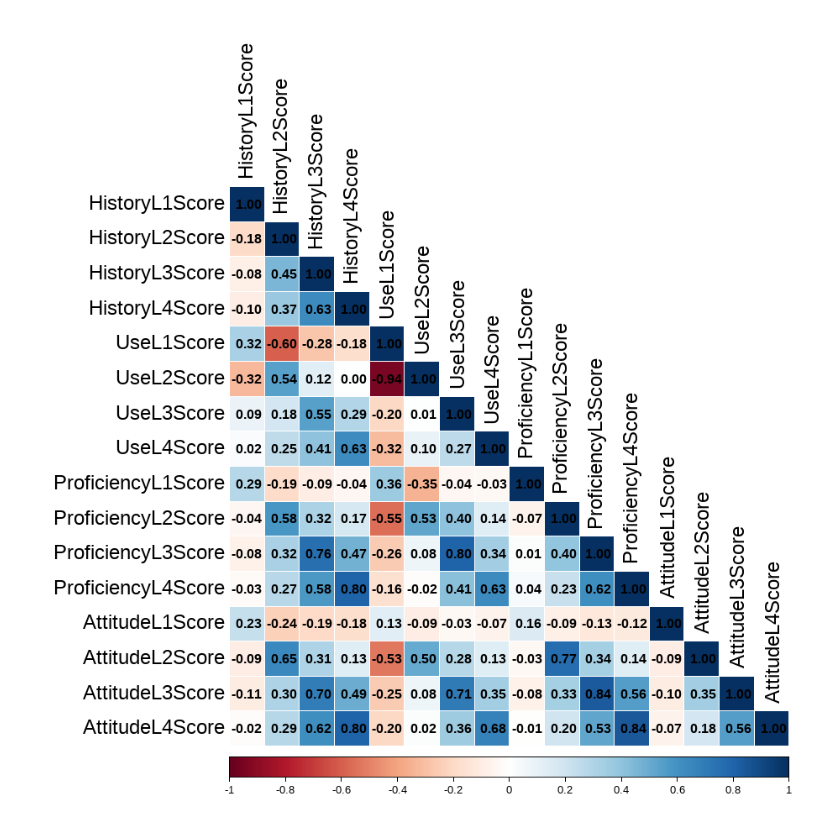

In [194]:
png('exp2_corrPlot_BLP.png', width=1000, height=1000);
corrplot::corrplot(cor(BLP_scores),type="lower", order="original", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black',tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_BLP.png"));

agg_record_759479912 
                   2

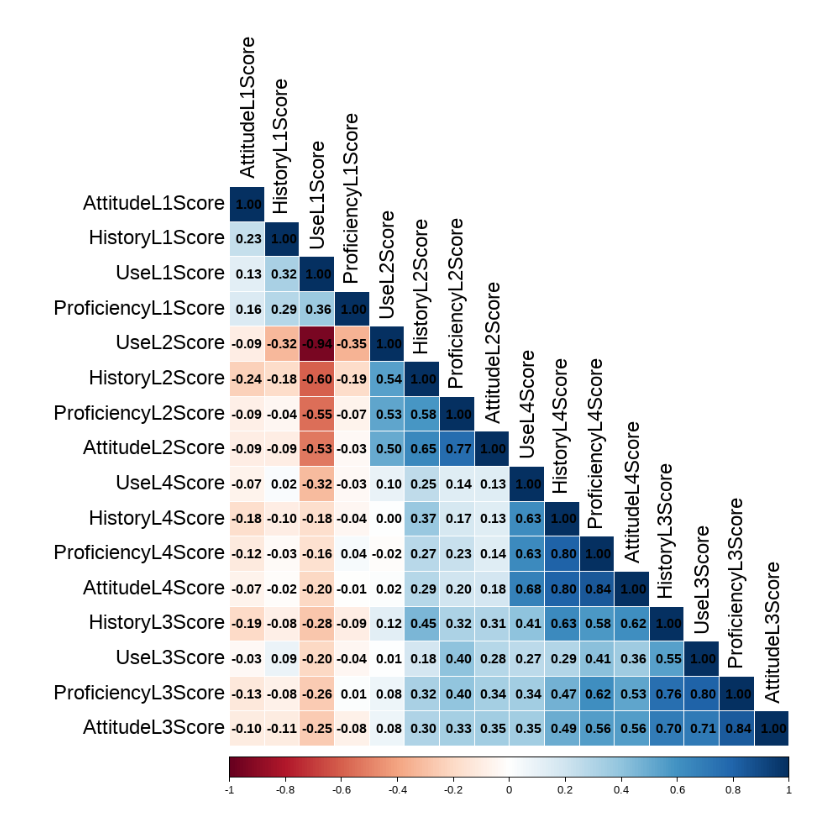

In [195]:
png('exp2_corrPlot_BLP_hclust.png', width=1000, height=1000);
corrplot::corrplot(cor(BLP_scores),type="lower", order="hclust", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black',tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_BLP_hclust.png"));

In [196]:
# BLP scores PCA
pca_varimax <- psych::principal(BLP_scores, nfactors=16, rotate='varimax');
data_BLP <- cbind(data_BLP, pca_varimax$scores[,c('RC1','RC3','RC2','RC7','RC9')]);
colnames(data_BLP)[which(names(data_BLP) == "RC1")] <- "RC1_L4";
colnames(data_BLP)[which(names(data_BLP) == "RC3")] <- "RC3_L3";
colnames(data_BLP)[which(names(data_BLP) == "RC2")] <- "RC2_use_L1vsL2";
colnames(data_BLP)[which(names(data_BLP) == "RC7")] <- "RC7_hist_L2";
colnames(data_BLP)[which(names(data_BLP) == "RC9")] <- "RC9_use_L4";

Warning message in scale_x_discrete(limits = c(seq(from = 1, to = 16))):
"Continuous limits supplied to discrete scale.
ℹ Did you mean `limits = factor(...)` or `scale_*_continuous()`?"


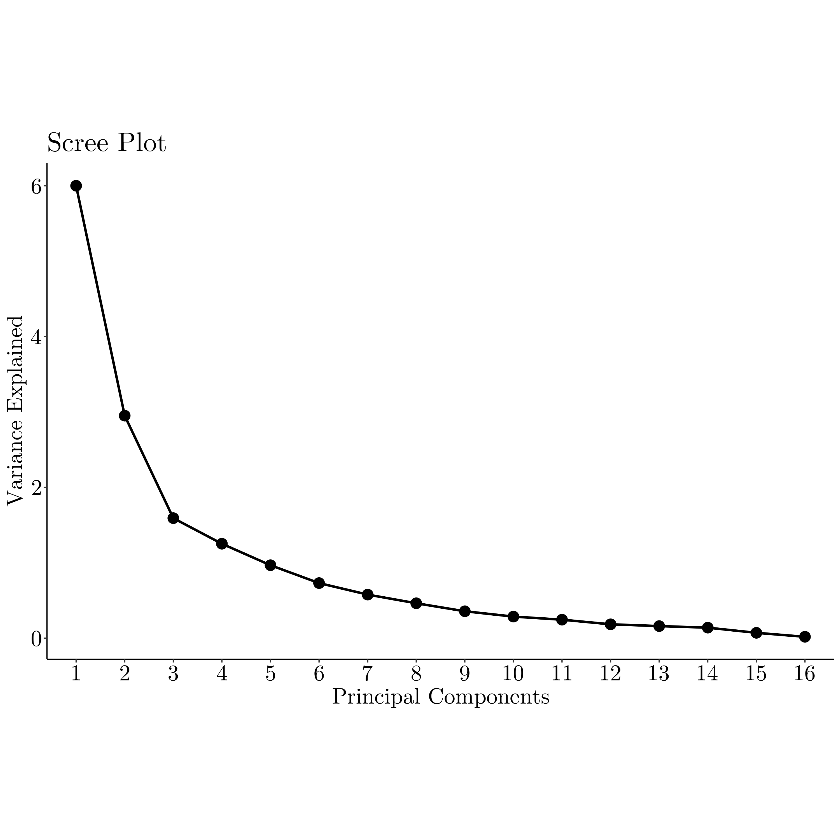

In [197]:
# scree plot
scree_data <- data.frame(Component = 1:16,Variance = pca_varimax$values[1:16]);

ggplot(scree_data, aes(x = Component, y = Variance)) +
  geom_line(linewidth=1) +
  geom_point(size=4) +
  labs(title = "Scree Plot", x = "Principal Components", y = "Variance Explained") +
  scale_x_discrete(limits=c(seq(from=1,to=16))) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

In [198]:
# biplot of 1st 2 PCs
#biplot(pca_varimax, main="Biplot of First Two Principal Components");

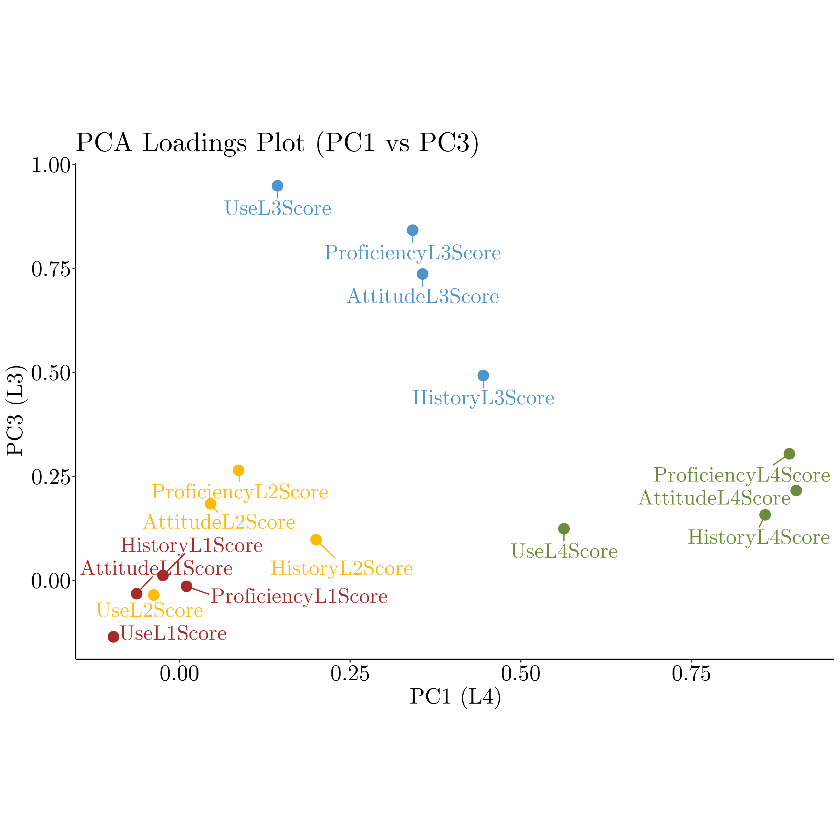

In [199]:
# loadings plot for 1st 2 PCs
loadings_data <- as.data.frame(pca_varimax$loadings[1:16, ]);
loadings_data$BLP_var <- c("L1 History","L2 History", "L3 History", "L4 History",
                       "L1 Use","L2 Use","L3 Use","L4 Use",
                       "L1 Proficiency","L2 Proficiency","L3 Proficiency","L4 Proficiency",
                       "L1 Attitude","L2 Attitude","L3 Attitude","L4 Attitude");
loadings_data$lang <- c(rep(c("L1","L2","L3","L4"),times=4));

ggplot(loadings_data, aes(x=RC1, y=RC3)) +
  geom_point(size=4,colour=c(rep(c(cols2[100],cols2[310],cols2[200],cols2[285]),times=4))) +
  geom_text_repel(aes(label=rownames(loadings_data)),vjust=2,family="CMU Serif",
            position=position_dodge(width=0.01),force=2,size=20,
            colour=c(rep(c(cols2[100],cols2[310],cols2[200],cols2[285]),times=4))) +
  labs(title="PCA Loadings Plot (PC1 vs PC3)",x="PC1 (L4)",y="PC3 (L3)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),legend.position="none",
        legend.background=element_rect(fill=NA));

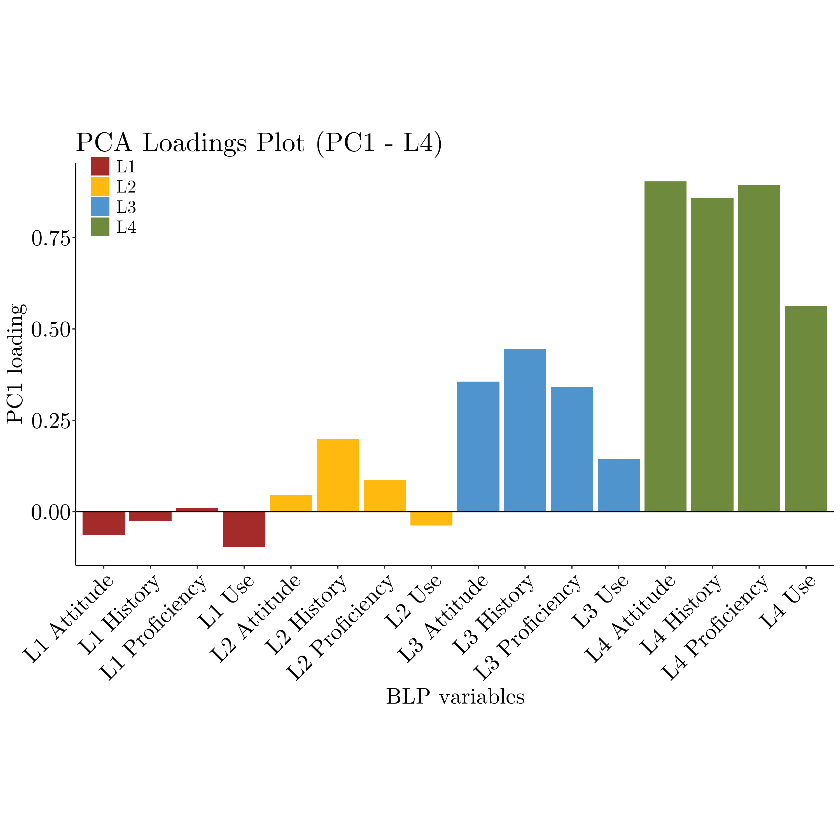

In [200]:
# PC1
ggplot(loadings_data, aes(x=BLP_var, y=RC1, fill=lang)) +
  geom_bar(stat="identity") +
  geom_hline(yintercept=0) +
  scale_fill_manual(values=c("L1"=cols2[100],"L2"=cols2[310],"L3"=cols2[200],"L4"=cols2[285]),
                    name="") +
  labs(title="PCA Loadings Plot (PC1 - L4)",y="PC1 loading",x="BLP variables") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),axis.text.x=element_text(angle=45,vjust=1,hjust=1),
        legend.position=c(0.05,0.95),legend.background=element_rect(fill=NA));

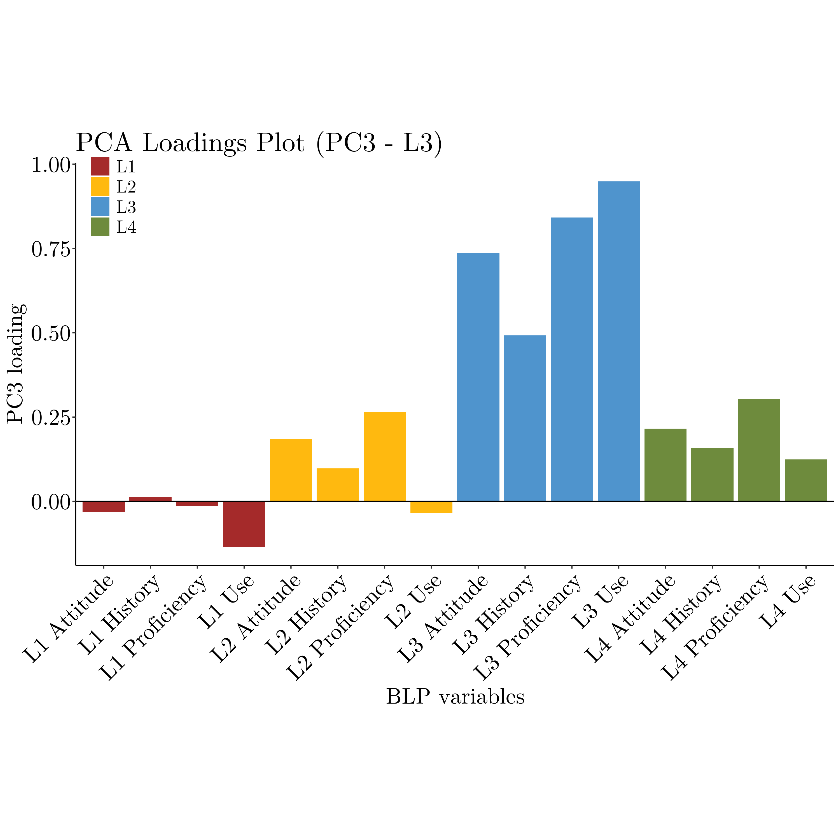

In [201]:
# PC3
ggplot(loadings_data, aes(x=BLP_var, y=RC3, fill=lang)) +
  geom_bar(stat="identity") +
  geom_hline(yintercept=0) +
  scale_fill_manual(values=c("L1"=cols2[100],"L2"=cols2[310],"L3"=cols2[200],"L4"=cols2[285]),
                    name="") +
  labs(title="PCA Loadings Plot (PC3 - L3)",y="PC3 loading",x="BLP variables") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),axis.text.x=element_text(angle=45,vjust=1,hjust=1),
        legend.position=c(0.05,0.95),legend.background=element_rect(fill=NA));

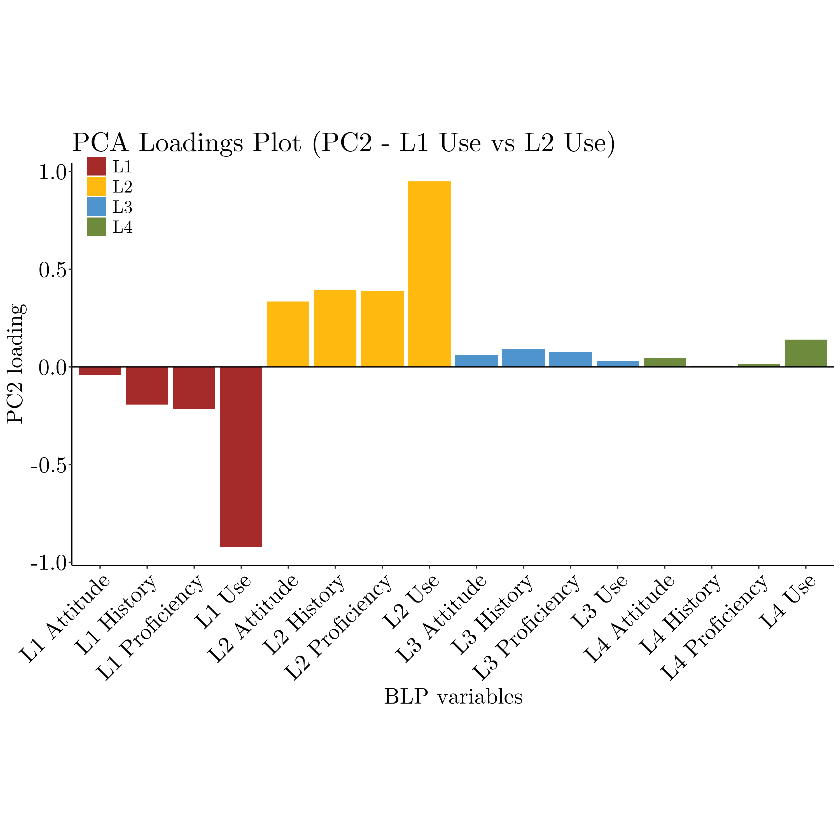

In [202]:
# PC2
ggplot(loadings_data, aes(x=BLP_var, y=RC2, fill=lang)) +
  geom_bar(stat="identity") +
  geom_hline(yintercept=0) +
  scale_fill_manual(values=c("L1"=cols2[100],"L2"=cols2[310],"L3"=cols2[200],"L4"=cols2[285]),
                    name="") +
  labs(title="PCA Loadings Plot (PC2 - L1 Use vs L2 Use)",y="PC2 loading",x="BLP variables") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),axis.text.x=element_text(angle=45,vjust=1,hjust=1),
        legend.position=c(0.05,0.95),legend.background=element_rect(fill=NA));

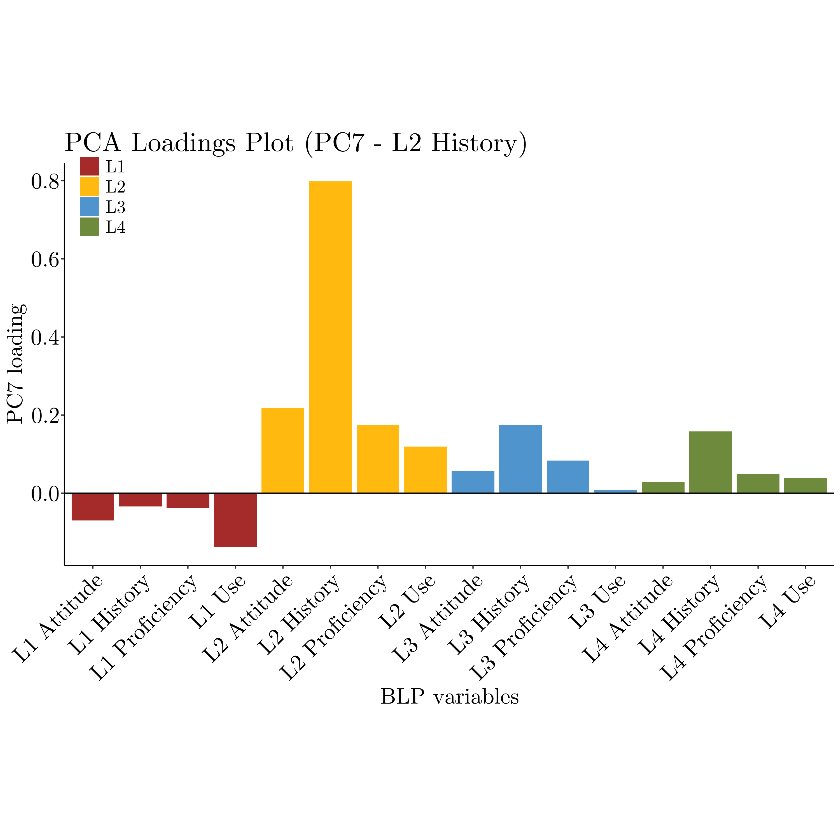

In [203]:
# PC7
ggplot(loadings_data, aes(x=BLP_var, y=RC7, fill=lang)) +
  geom_bar(stat="identity") +
  geom_hline(yintercept=0) +
  scale_fill_manual(values=c("L1"=cols2[100],"L2"=cols2[310],"L3"=cols2[200],"L4"=cols2[285]),
                    name="") +
  labs(title="PCA Loadings Plot (PC7 - L2 History)",y="PC7 loading",x="BLP variables") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),axis.text.x=element_text(angle=45,vjust=1,hjust=1),
        legend.position=c(0.05,0.95),legend.background=element_rect(fill=NA));

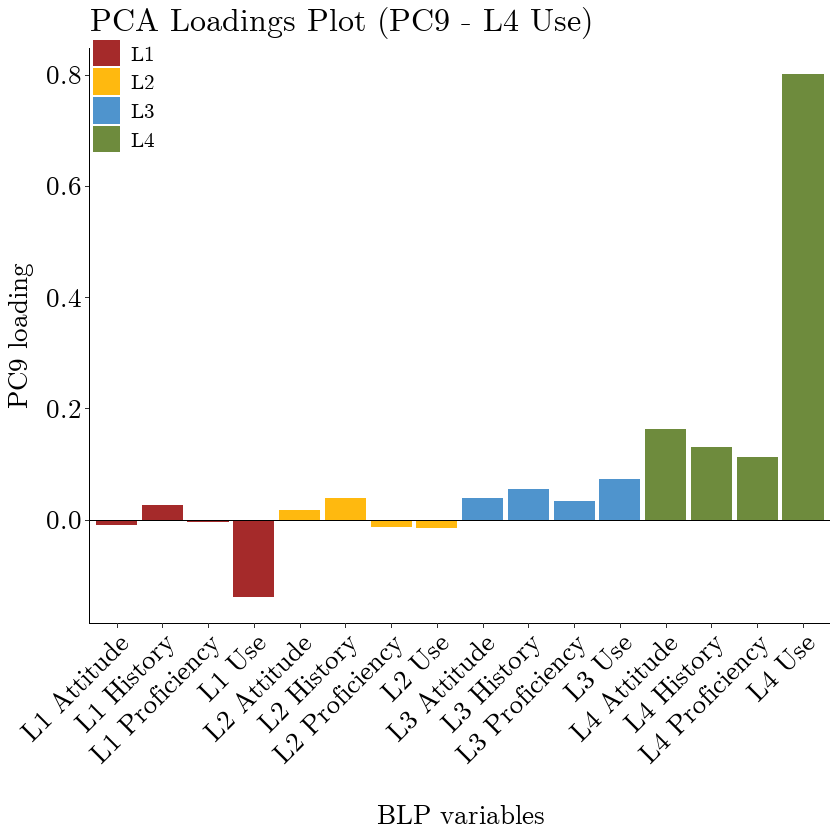

In [239]:
# PC9
ggplot(loadings_data, aes(x=BLP_var, y=RC9, fill=lang)) +
  geom_bar(stat="identity") +
  geom_hline(yintercept=0) +
  scale_fill_manual(values=c("L1"=cols2[100],"L2"=cols2[310],"L3"=cols2[200],"L4"=cols2[285]),
                    name="") +
  labs(title="PCA Loadings Plot (PC9 - L4 Use)",y="PC9 loading",x="BLP variables") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),axis.text.x=element_text(angle=45,vjust=1,hjust=1),
        legend.position=c(0.05,0.95),legend.background=element_rect(fill=NA));

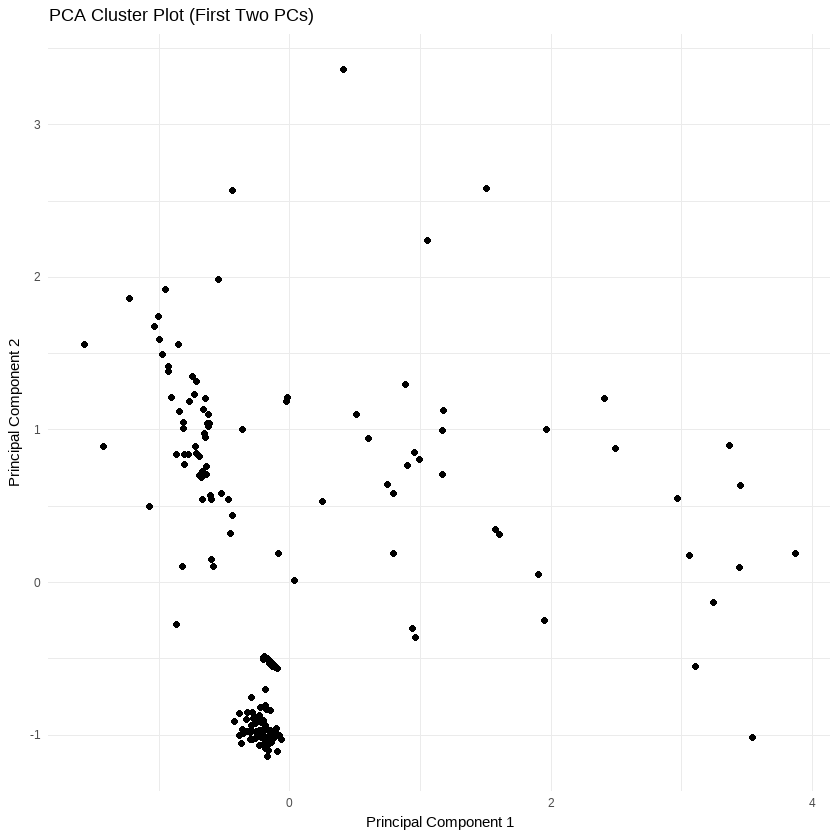

In [205]:
# Cluster plot of 1st 2 PCs
cluster_data <- data.frame(pca_varimax$scores[, 1:2]);
colnames(cluster_data) <- c("PC1", "PC2");
ggplot(cluster_data, aes(x = PC1, y = PC2)) +
  geom_point() +
  labs(title = "PCA Cluster Plot (First Two PCs)", x = "Principal Component 1", y = "Principal Component 2") +
  theme_minimal();

## Multilingual Metrics

In [206]:
multilingual_metrics <- data.frame();
for (i in 1:184) {
  temp <- scores_list[which(scores_list$sbj_ID==unique(scores_list$sbj_ID)[i]),];
  sbj_ID <- temp$sbj_ID[1];
  temp_scores <- as.list(temp);
  temp_scores <- temp_scores[-1];
  temp_scores <- unlist(temp_scores);
  
  use_temp <- use_scores_list[which(use_scores_list$sbj_ID==unique(use_scores_list$sbj_ID)[i]),];
  use_temp_scores <- as.list(use_temp);
  use_temp_scores <- use_temp_scores[-1];
  use_temp_scores <- unlist(use_temp_scores);
  
  # variance
  variance <- var(temp_scores,na.rm=TRUE);
  
  # entropy
  entropy <- Entropy(temp_scores,na.rm=TRUE);
  use_entropy <- Entropy(use_temp_scores,na.rm=TRUE);
  
  # multilingual experience
  multiexp <- sum(temp_scores);
  
  # L1 - L2 score
  L1L2 <- abs(temp_scores[[1]]-temp_scores[[2]]);
  
  multilingual_metrics <- rbind(multilingual_metrics, 
      list(sbj_ID,variance,entropy,use_entropy,multiexp,L1L2));
};
names(multilingual_metrics) <- c("sbj_ID","var","ent","use_ent","multiexp","L1_L2_diff");
data_BLP <- merge(data_BLP,multilingual_metrics,by="sbj_ID");

### Cosine Similarity

In [207]:
cossim <- read.csv("distances_exp2_NOLOWSCORES.csv",header=T,sep=",");
cossim <- subset(cossim, select = -c(X)); # remove redundant column added by Python
names(cossim) <- c('sbj_ID','cossim');
data_BLP <- merge(data_BLP,cossim,by="sbj_ID");

use_cossim <- read.csv("distances_exp2_usescores.csv",header=T,sep=",");
use_cossim <- subset(use_cossim, select = -c(X)); # remove redundant column added by Python
names(use_cossim) <- c('sbj_ID','use_cossim');
data_BLP <- merge(data_BLP,use_cossim,by="sbj_ID");

### Multilingual Category

In [208]:
data_BLP$category <- "mono";
data_BLP$category[data_BLP$L2Score>0] <- "bi";
data_BLP$category[data_BLP$L3Score>0] <- "tri";
data_BLP$category[data_BLP$L4Score>0] <- "quadri";
data_BLP$category <- factor(data_BLP$category,levels=c("mono","bi","tri","quadri"));
summary(data_BLP$category);

mono     bi    tri quadri 
    22     70     51     41

### Script

In [209]:
diff_script_sbjID <- c('5e8b85a61e16e9057a996e36','60c715c89bb47f3847a690f0','655f8b959477c803eb906622','65a97afe116a650acc588c5b','65cba84263ac644fa79702ca','65fae6b84fa6b3101d2ca4b1','66031000461c44484ac359a8','66271b4aaaf60fd058302f09','6667488c5f46f3da0c085419','667972671949d2e1c0c9ff54');
# n=10
mixed_script_sbjID <- c('5ebd8f8679146d0a116bc257','5eff8b9ad19111064484eff7','5f5a5d4618746310515e2828','6057a8fe2d302939fc759940','60907b8091341e8724ba80ed','60f9739250a5c6f6e4726336','6106ac34408681f3b0d07396','61242dd5be1a06b174975a1f','6492c23a1a7735dfaab2b095','64e9d6f596308448ac67bb95','650330fa0cbc534b423f41e9','65352001dbe3e18eae5a8300','65672c69a3737224f1d0bbfa','65a97217d4fb858939a16b0f','65dce7715387badaf80e875d','660c265dce47171c0dd7d359','663a5bb8f7f79c7e04abc9b3','668992b2f868cb89829346c2');
# n=18
sbj_IDs_included <- list(unique(data_BLP$sbj_ID))[[1]];
same_script_sbjID <- sbj_IDs_included[!sbj_IDs_included %in% diff_script_sbjID];
same_script_sbjID <- same_script_sbjID[!same_script_sbjID %in% mixed_script_sbjID];
# n=156
data_BLP$script[data_BLP$sbj_ID %in% diff_script_sbjID] <- 'mixed/diff';
data_BLP$script[data_BLP$sbj_ID %in% mixed_script_sbjID] <- 'mixed/diff';
data_BLP$script[data_BLP$sbj_ID %in% same_script_sbjID] <- 'same';
data_BLP$script <- factor(data_BLP$script,levels=c("same","mixed/diff"));

### Metric Comparisons

In [210]:
#var
summary(data_BLP$var);
#min=379, Q1=6402, med=8262, mean=7726, Q3=9728, max=11875
var(data_BLP$var);
#var = 7898408

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  378.7  6402.1  8261.6  7726.3  9727.9 11874.5 

[1] 7898408

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.930   1.118   1.165   1.542   1.991 

[1] 0.3093324


	Pearson's product-moment correlation

data:  data_BLP$var and data_BLP$ent
t = -20.294, df = 182, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.8723484 -0.7823719
sample estimates:
       cor 
-0.8327799 


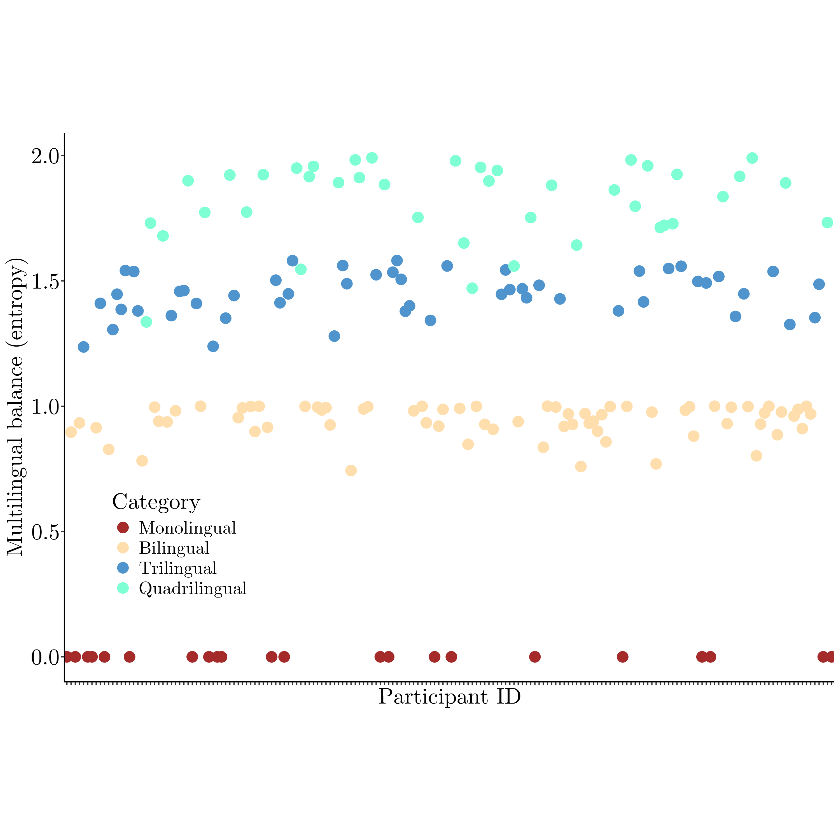

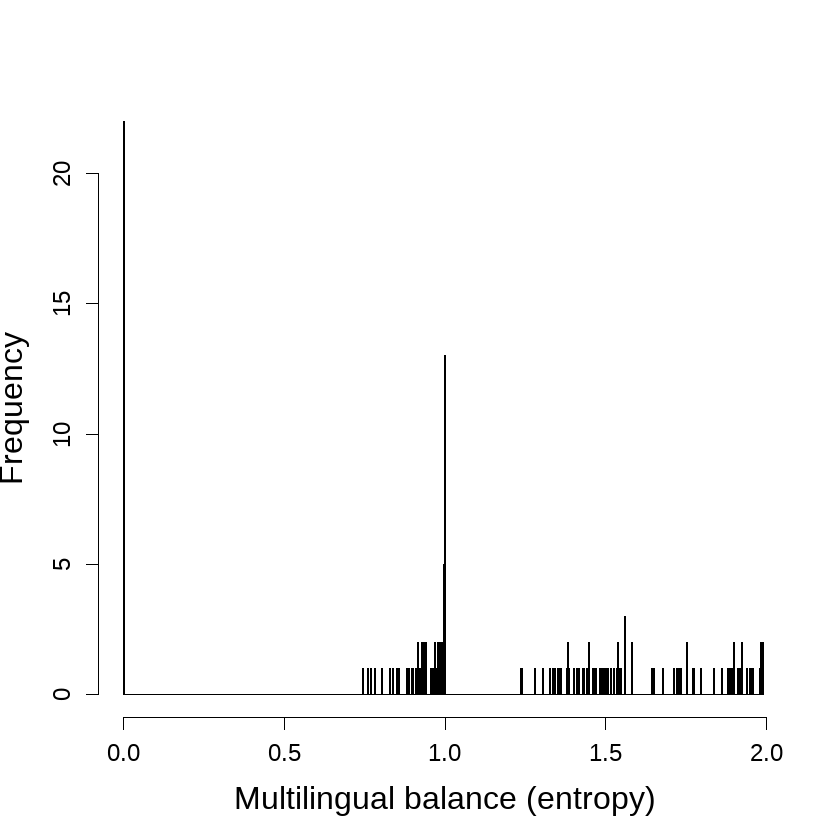

In [211]:
#ent
summary(data_BLP$ent);
#min=0, Q1=0.93, med=1.12, mean=1.17, Q3=1.54, max=1.99
var(data_BLP$ent);
#var = 0.31

cor.test(data_BLP$var,data_BLP$ent,method="pearson"); 
# t=-20.29 df=182 p<2.2e-16 CI=[-0.87;-0.78] est=-0.83
# significantly very strongly negatively correlated 

ggplot(data_BLP, aes(x=sbj_ID,y=ent,colour=category)) +
  geom_point(size=4) +
  labs(x = "Participant ID", y = "Multilingual balance (entropy)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        axis.text.x=element_blank(),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.15,0.25),legend.background=element_rect(fill=NA)) +
  scale_color_manual(values=c(cols2[100],cols2[150],cols2[200],cols2[250]),
                     name="Category",
                     labels=c("Monolingual","Bilingual","Trilingual","Quadrilingual"));

hist(data_BLP$ent,breaks=1000,xlab="Multilingual balance (entropy)",
     main="",cex.lab=2,cex.axis=1.5);
# lots at 0 and 1

In [212]:
#use_ent
summary(data_BLP$use_ent);
#min=0, Q1=0.40, med=0.94, mean=0.88, Q3=1.27, max=1.92
var(data_BLP$use_ent);
#var = 0.26

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.4022  0.9427  0.8761  1.2670  1.9229 

[1] 0.2575335

In [213]:
#multiexp
summary(data_BLP$multiexp);
#min=154, Q1=303, med=346, mean=361, Q3=413, max=702
var(data_BLP$multiexp);
#var = 9348

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  153.9   303.2   346.3   361.2   412.9   701.9 

[1] 9347.634

In [214]:
#L1_L2_diff
summary(data_BLP$L1_L2_diff);
#min=0, Q1=38, med=70, mean=82, Q3=110, Q4=218
var(data_BLP$L1_L2_diff);
#var = 3686

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00   37.99   69.97   82.29  110.39  217.94 

[1] 3686.283

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.8402  0.9349  0.9659  0.9593  0.9960  1.0000 

[1] 0.001427596

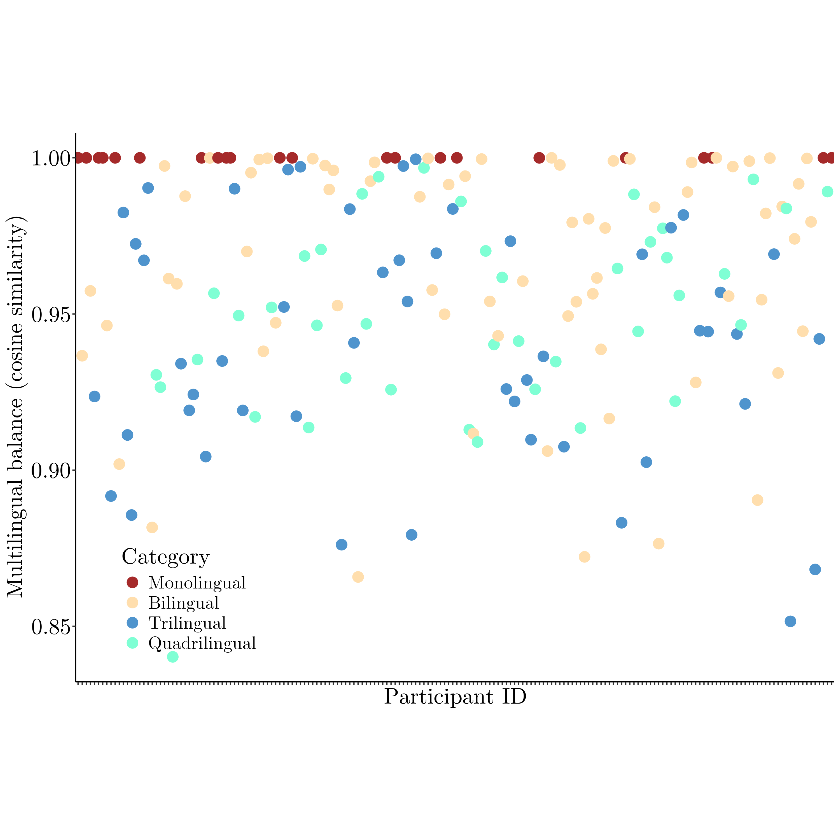

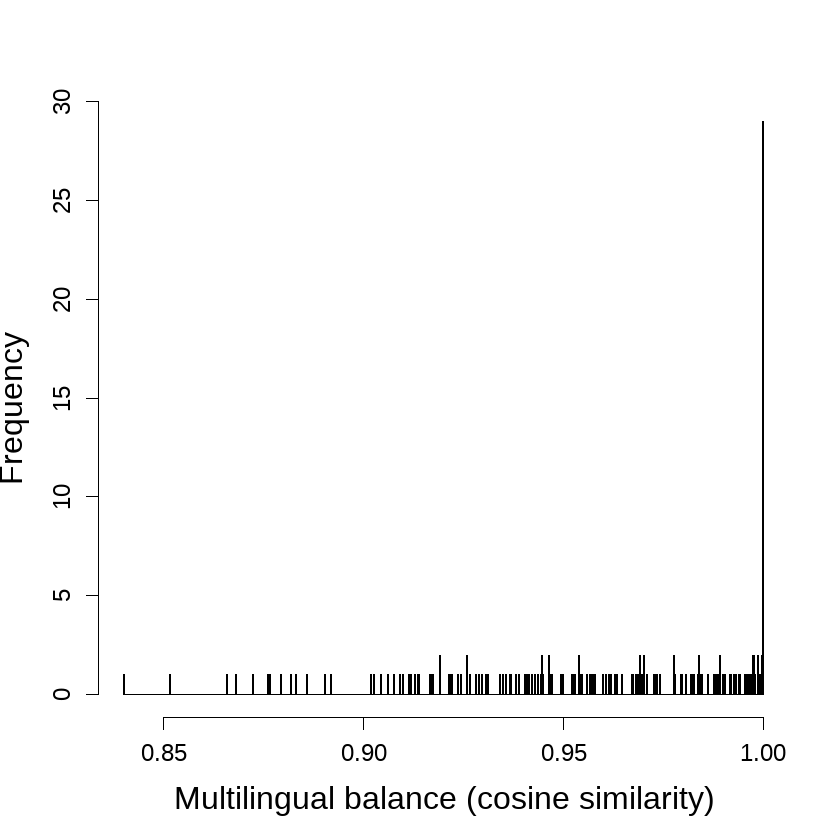

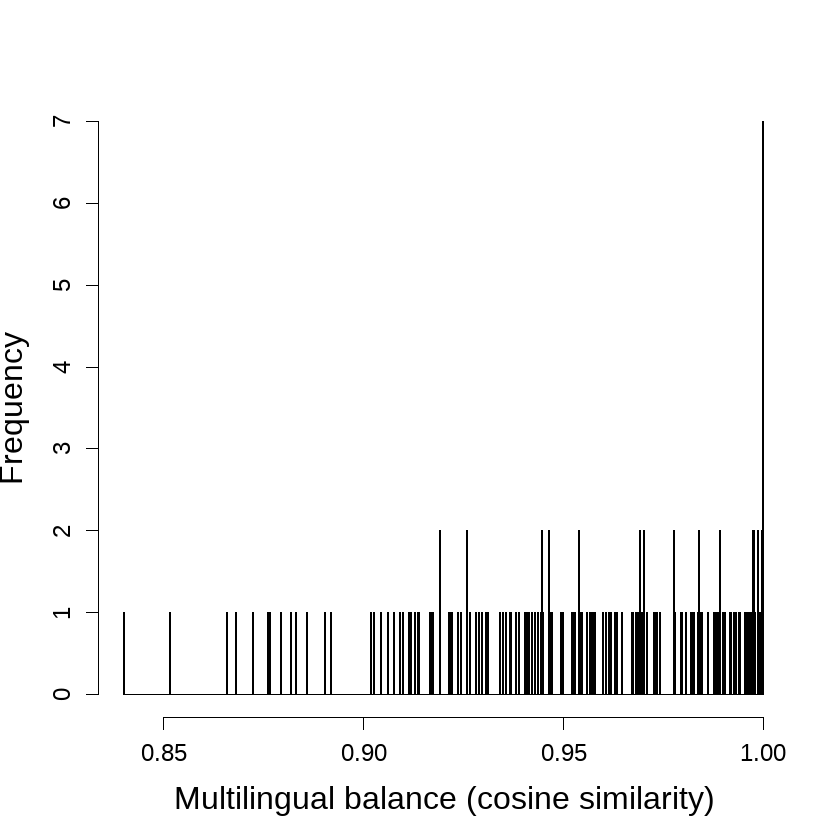

In [215]:
#cossim
summary(data_BLP$cossim);
#min=0.84, Q1=0.93, med=0.97, mean=0.96, Q3=0.996, max=1
var(data_BLP$cossim);
#var = 0.001

ggplot(data_BLP, aes(x=sbj_ID,y=cossim,colour=category)) +
  geom_point(size=4) +
  labs(x = "Participant ID", y = "Multilingual balance (cosine similarity)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        axis.text.x=element_blank(),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.15,0.15),legend.background=element_rect(fill=NA)) +
  scale_color_manual(values=c(cols2[100],cols2[150],cols2[200],cols2[250]),
                     name="Category",
                     labels=c("Monolingual","Bilingual","Trilingual","Quadrilingual"));

hist(data_BLP$cossim,breaks=1000,
     xlab="Multilingual balance (cosine similarity)",main="",
     cex.lab=2,cex.axis=1.5);
# lots at 1
hist(data_BLP$cossim[data_BLP$category!="mono"],breaks=1000,
     xlab="Multilingual balance (cosine similarity)",main="",
     cex.lab=2,cex.axis=1.5);
# exponential distribution

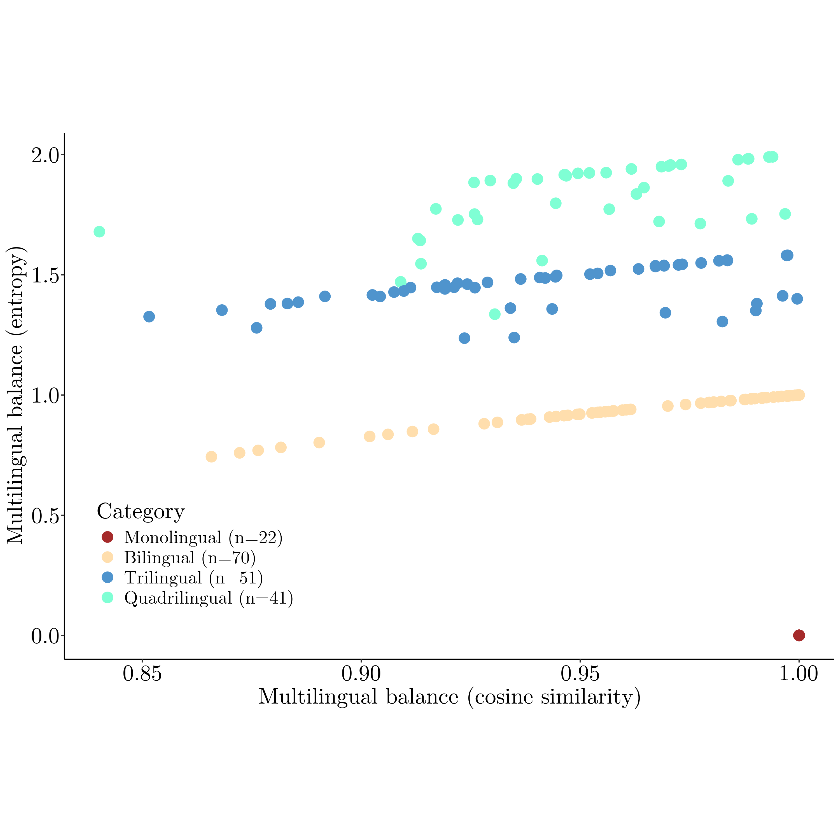

In [216]:
plt_cossim_ent <- ggplot(data_BLP, aes(x=cossim,y=ent,colour=category)) +
  geom_point(size=4) +
  labs(x = "Multilingual balance (cosine similarity)", y = "Multilingual balance (entropy)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 60, color = "black"),
        text=element_text(family="CMU Serif",size=60),
        legend.position=c(0.17,0.2),legend.background=element_rect(fill=NA)) +
  scale_color_manual(values=c(cols2[100],cols2[150],cols2[200],cols2[250]),
                     name="Category",
                     labels=c("Monolingual (n=22)","Bilingual (n=70)",
                              "Trilingual (n=51)","Quadrilingual (n=41)"));
ggsave("exp2_ent_cossim.png",plt_cossim_ent,path=output_folder,
       width=10,height=7,device="png");
grid.raster(readPNG(paste(output_folder,"/exp2_ent_cossim.png",sep="")));

In [217]:
#use_cossim
summary(data_BLP$use_cossim);
#min=0.63, Q1=0.76, med=0.85, mean=0.86, Q3=0.95, max=1
var(data_BLP$use_cossim);
#var = 0.01

# cossim & use_cossim
cor.test(data_BLP$cossim,data_BLP$use_cossim,method="pearson");
# t=10.76 df=182 p<2.2e-16 CI=[0.53;0.70] est=0.62
# significantly strongly positively correlated

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6258  0.7637  0.8484  0.8557  0.9547  1.0000 

[1] 0.01106089


	Pearson's product-moment correlation

data:  data_BLP$cossim and data_BLP$use_cossim
t = 10.764, df = 182, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5265440 0.7047709
sample estimates:
      cor 
0.6236977 



	Pearson's product-moment correlation

data:  data_BLP$ent and data_BLP$multiexp
t = 30.175, df = 182, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8851475 0.9342010
sample estimates:
      cor 
0.9129133 


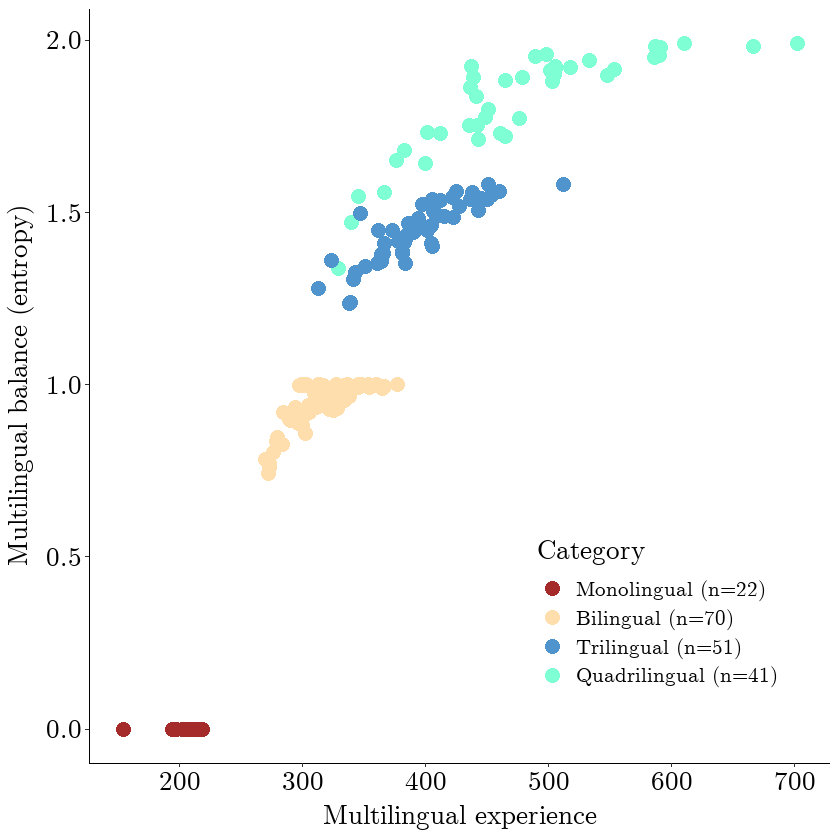

In [236]:
#ent & multiexp
cor.test(data_BLP$ent,data_BLP$multiexp,method="pearson");
# t=30.18 df=182 p<2.2e-16 CI=[0.89;0.93], est=0.91
# significantly very strongly positively correlated

ggplot(data_BLP, aes(x=multiexp,y=ent,colour=category)) +
  geom_point(size=4) +
  labs(x = "Multilingual experience", y = "Multilingual balance (entropy)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.8,0.2),legend.background=element_rect(fill=NA)) +
  scale_color_manual(values=c(cols2[100],cols2[150],cols2[200],cols2[250]),
                     name="Category",
                     labels=c("Monolingual (n=22)","Bilingual (n=70)",
                              "Trilingual (n=51)","Quadrilingual (n=41)"));


	Pearson's product-moment correlation

data:  data_BLP$cossim and data_BLP$multiexp
t = -1.617, df = 182, p-value = 0.1076
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.25920922  0.02609954
sample estimates:
       cor 
-0.1190108 


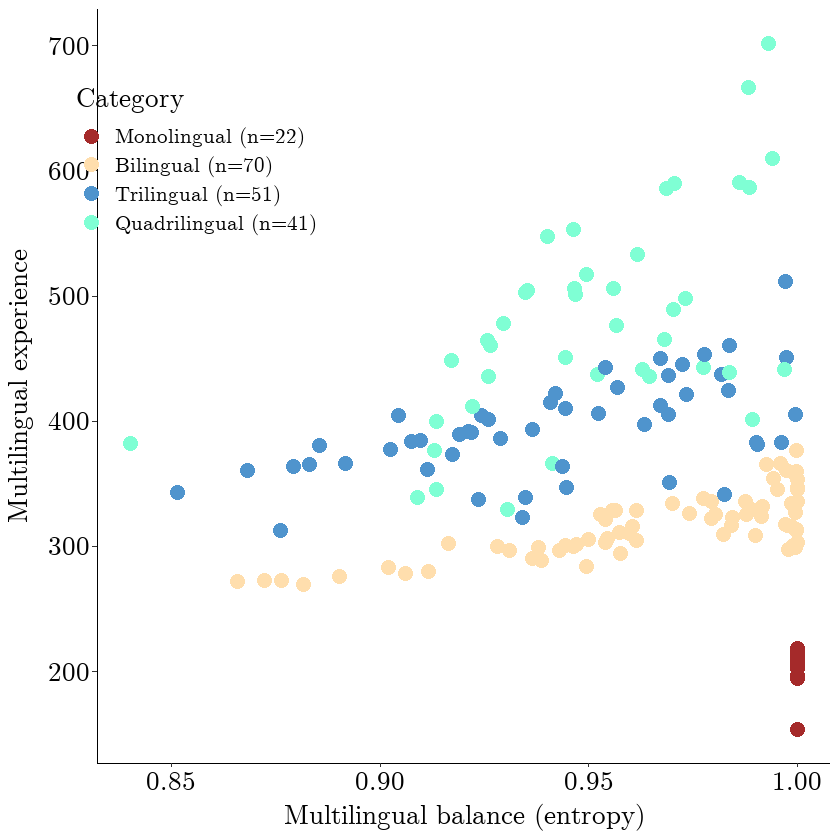

In [237]:
#cossim & multiexp
cor.test(data_BLP$cossim,data_BLP$multiexp,method="pearson");
# t=-1.62 df=182 p=0.11 CI=[-0.26;0.03], est=-0.12
# not significant

ggplot(data_BLP, aes(x=cossim,y=multiexp,colour=category)) +
  geom_point(size=4) +
  labs(y = "Multilingual experience", x = "Multilingual balance (entropy)") +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.17,0.8),legend.background=element_rect(fill=NA)) +
  scale_color_manual(values=c(cols2[100],cols2[150],cols2[200],cols2[250]),
                     name="Category",
                     labels=c("Monolingual (n=22)","Bilingual (n=70)",
                              "Trilingual (n=51)","Quadrilingual (n=41)"));

In [220]:
#cossim & ent
cor.test(data_BLP$cossim,data_BLP$ent,method="pearson");
#t=-4.85 df=182 p=2.63e-6 CI=[-0.46;-0.20] est=-0.34
# no monos:
cor.test(data_BLP$cossim[data_BLP$category!="mono"],data_BLP$ent[data_BLP$category!="mono"],method="pearson");
# t=-0.66 df=160 p=0.51 CI=[-0.20;0.10] est=-0.05
# no corr


	Pearson's product-moment correlation

data:  data_BLP$cossim and data_BLP$ent
t = -4.8513, df = 182, p-value = 2.625e-06
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.4605072 -0.2036992
sample estimates:
       cor 
-0.3383888 



	Pearson's product-moment correlation

data:  data_BLP$cossim[data_BLP$category != "mono"] and data_BLP$ent[data_BLP$category != "mono"]
t = -0.66071, df = 160, p-value = 0.5097
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.2047118  0.1028599
sample estimates:
        cor 
-0.05216291 


In [221]:
#ent & use_ent
cor.test(data_BLP$ent,data_BLP$use_ent,method="pearson");
# t=24.10 df=182 p<2.2e-16 CI=[0.83;0.90] est=0.87
# significantly strongly positively correlated


	Pearson's product-moment correlation

data:  data_BLP$ent and data_BLP$use_ent
t = 24.096, df = 182, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.8330447 0.9032087
sample estimates:
      cor 
0.8725549 


agg_record_835091921 
                   2

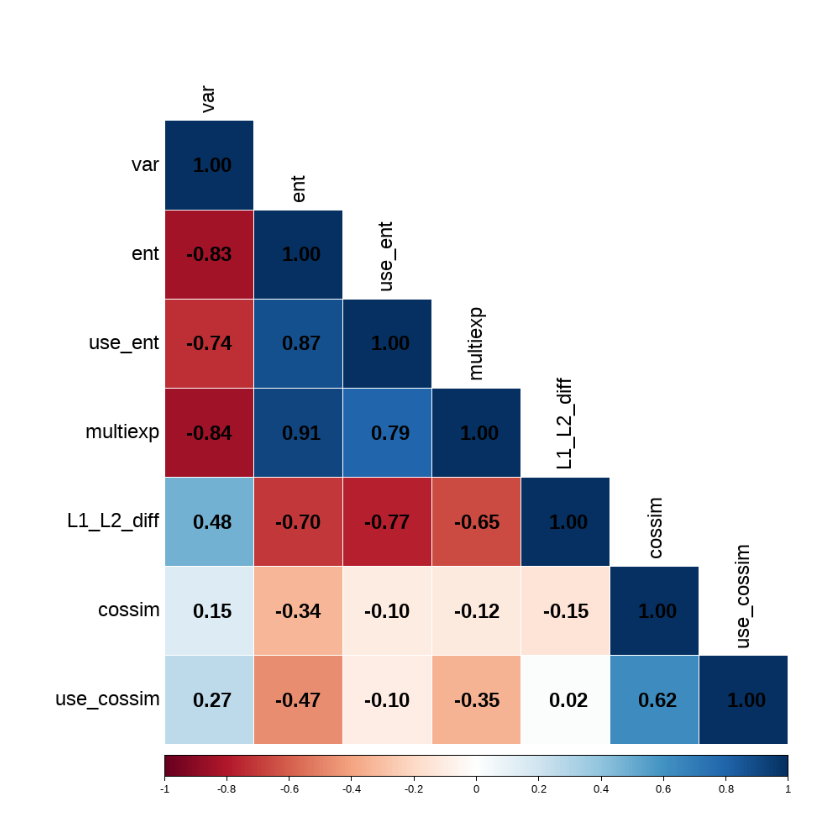

In [222]:
# correlations of multilingual metrics
M <- cor(subset(data_BLP,select=c('var','ent','use_ent','multiexp','L1_L2_diff','cossim','use_cossim')));
png('exp2_corrPlot_multimetrics.png', width=1000, height=1000);
corrplot::corrplot(M,type="lower", order="original", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black',number.cex=1.5,tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_multimetrics.png"));

agg_record_452194238 
                   2

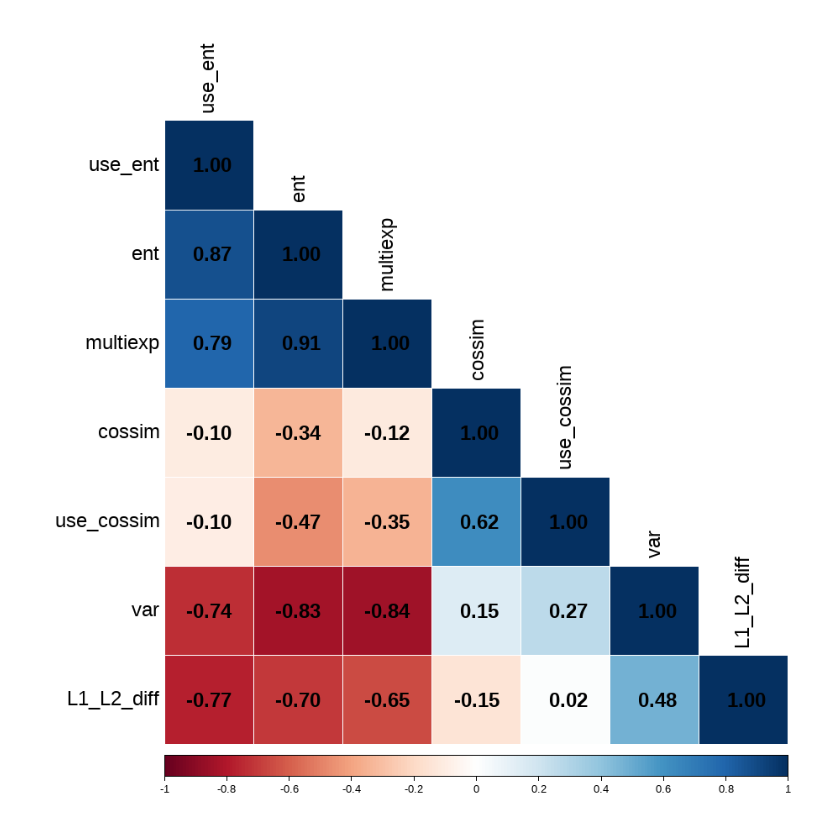

In [223]:
png('exp2_corrPlot_multimetrics_hclust.png', width=1000, height=1000);
corrplot::corrplot(M,type="lower", order="hclust", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black', number.cex=1.5,tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_multimetrics_hclust.png"));

In [224]:
# export BLP dataframe
write.csv(data_BLP,"BASL_exp2_BLP.csv", row.names = FALSE);

In [225]:
# combining BLP & testing scores
data_BLP_shortened <- subset(data_BLP, select=c(sbj_ID,Gender,Age,
                                                HistoryL1Score,HistoryL2Score,HistoryL3Score,HistoryL4Score,
                                                UseL1Score,UseL2Score,UseL3Score,UseL4Score,
                                                ProficiencyL1Score,ProficiencyL2Score,ProficiencyL3Score,ProficiencyL4Score,
                                                AttitudeL1Score,AttitudeL2Score,AttitudeL3Score,AttitudeL4Score,
                                                L1Score,L2Score,L3Score,L4Score,
                                                var,ent,use_ent,multiexp,L1_L2_diff,cossim,use_cossim,
                                                RC1_L4,RC3_L3,RC2_use_L1vsL2,RC7_hist_L2,RC9_use_L4,
                                                category,script));
data_BLP_testing <- list(data_testing,data_BLP_shortened) %>% reduce(inner_join, by='sbj_ID');
data_BLP_familiarity <- list(data_familiarity,data_BLP_shortened) %>% reduce(inner_join, by='sbj_ID');

agg_record_1454915896 
                    2

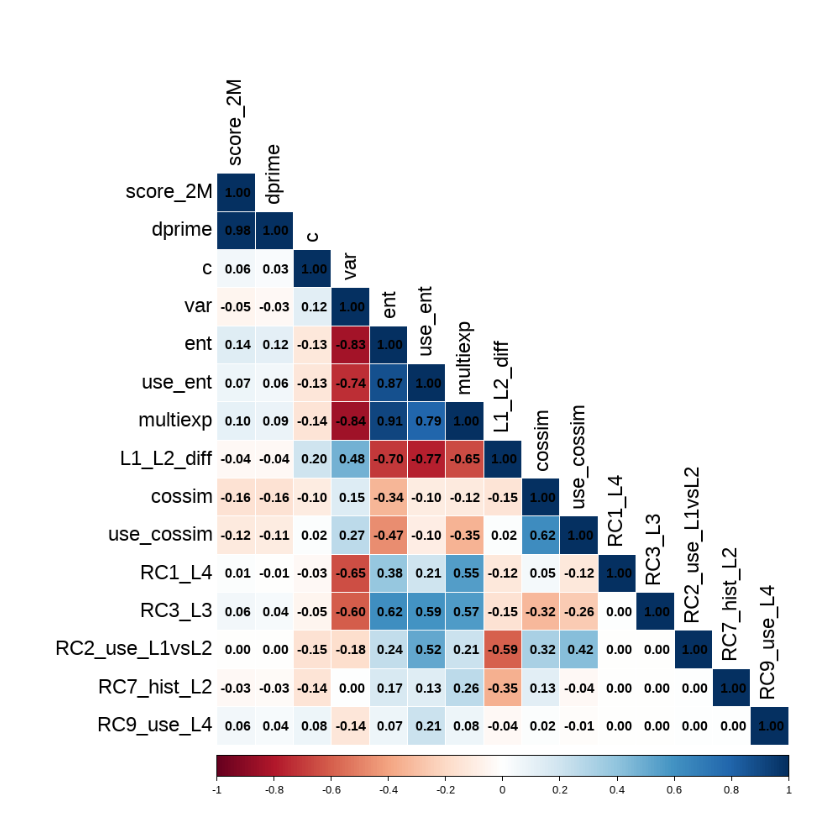

In [227]:
# correlations of BLP metrics with testing scores
M <- cor(subset(data_BLP_testing,select=c(score_2M,dprime,c,
                                          var,ent,use_ent,multiexp,L1_L2_diff,cossim,use_cossim,
                                          RC1_L4,RC3_L3,RC2_use_L1vsL2,RC7_hist_L2,RC9_use_L4)));
png('exp2_corrPlot_BLP_testing.png', width=1000, height=1000);
corrplot::corrplot(M,type="lower", order="original", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black',tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_BLP_testing.png"));

agg_record_395419240 
                   2

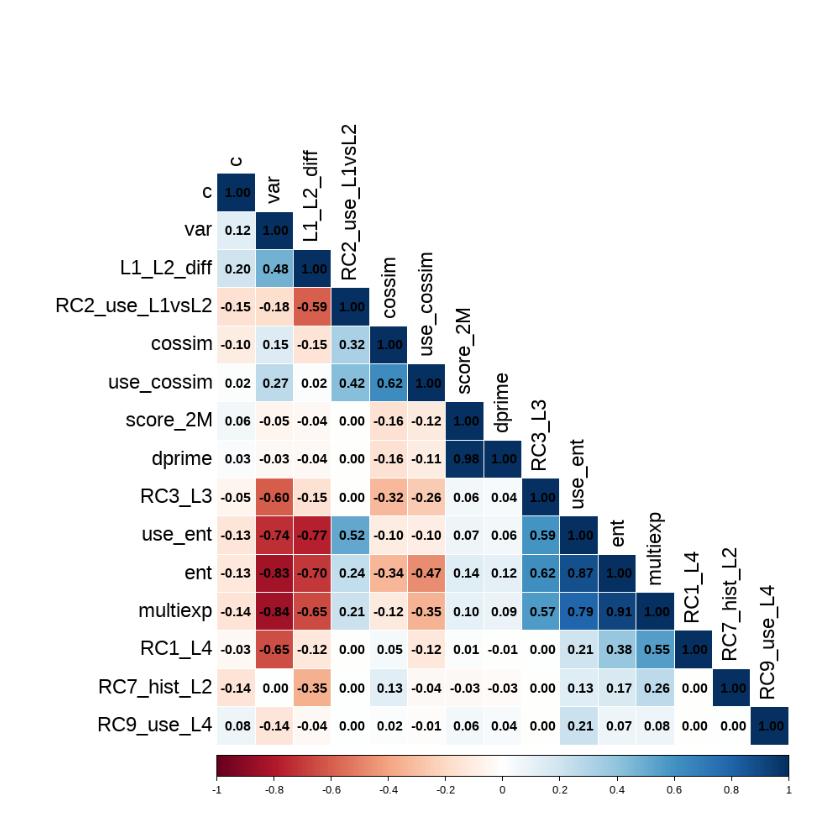

In [228]:
png('exp2_corrPlot_BLP_testing_hclust.png', width=1000, height=1000);
corrplot::corrplot(M,type="lower", order="hclust", diag=T, method="color", outline=F, addgrid.col=F, tl.col='black', tl.pos='ld', addCoef.col='black',tl.cex=1.5);
dev.off();
grid.raster(readPNG("exp2_corrPlot_BLP_testing_hclust.png"));

In [229]:
# export BLP testing dataframe
write.csv(data_BLP_testing,"BASL_exp2_BLPtesting.csv", row.names = FALSE);

# LINEAR MODELLING

## "Yes" Responses LMERs

### Testing Conditions

In [ ]:
lm_TestingConditions <- glmer(observed ~ scale(trialn) + testing_condition + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_TestingConditions); 
# all conditions sig
effect_conditions <- as.data.frame(effect('testing_condition',
                                          lm_TestingConditions, confint=list(alpha=.95)),
                                   xlevels = list(testing_condition=c('0M','1M','2M')));
export_output(model=lm_TestingConditions,name="Exp. 2 `Yes' responses - Conditions",
              pred_levels=c('0M','1M','2M'),pred_type='categorical',
              outcome_levels=c('0M','1M','2M'));

### Gender

In [ ]:
lm_Gender <- glmer(observed ~ scale(trialn) + testing_condition*Gender + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_Gender); 
# Gender non sig as main effect (p=0.78)
# 1M:Woman sig (0.048)
export_output(model=lm_Gender,name="Exp. 2 `Yes' responses - Gender",
              pred_levels=c('Man','Woman'),pred_type='categorical',
              outcome_levels=c('0M','1M','2M'));

### Age

In [ ]:
lm_Age <- glmer(observed ~ scale(trialn) + testing_condition*scale(Age) + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_Age); 
# Age non sig as main effect (0.96)
# 2M:Age sig (p=0.04)
export_output(model=lm_Age,name="Exp. 2 `Yes' responses - Age",
              pred_levels=c('scale(Age)'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### PC1

In [ ]:
lm_RC1 <- glmer(observed ~ scale(trialn) + testing_condition*RC1_L4 + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_RC1); 
# RC1 marg. sig as main effect (p=0.07)
# 1M:RC1 non sig (p=0.51)
# 2M:RC1 non sig (0.31)
export_output(model=lm_RC1,name="Exp. 2 `Yes' responses - PC1 (L4)",
              pred_levels=c('PC1_L4'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### PC3

In [ ]:
lm_RC3 <- glmer(observed ~ scale(trialn) + testing_condition*RC3_L3 + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_RC3); 
# RC3 non sig as main effect (p=0.25)
# 1M:RC3 marg. sig (p=0.08)
# 2M:RC3 non sig (p=0.72)
export_output(model=lm_RC3,name="Exp. 2 `Yes' responses - PC3 (L3)",
              pred_levels=c('PC3_L3'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### PC2

In [ ]:
lm_RC2 <- glmer(observed ~ scale(trialn) + testing_condition*RC2_use_L1vsL2 + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_RC2); 
# RC2 non sig as main effect (p=0.85)
# 1M:RC2 non sig (p=0.19)
# 2M:RC2 sig (p=0.04)
export_output(model=lm_RC2,name="Exp. 2 `Yes' responses - PC2 (L1 vs L2 Use)",
              pred_levels=c('PC2_L1vsL2_Use'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### PC7

In [ ]:
lm_RC7 <- glmer(observed ~ scale(trialn) + testing_condition*RC7_hist_L2 + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_RC7); 
# RC7 sig as main effect (p=0.03)
# 1M:RC7 non sig (p=0.87)
# 2M:RC7 non sig (p=0.87)
export_output(model=lm_RC7,name="Exp. 2 `Yes' responses - PC7 (L2 History)",
              pred_levels=c('PC7_L2_History'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### PC9

In [ ]:
lm_RC9 <- glmer(observed ~ scale(trialn) + testing_condition*RC9_use_L4 + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_RC9); 
# RC9 non sig as main effect (p=0.81)
# 1M:RC9 non sig (p=0.58)
# 2M:RC9 non sig (p=0.74)
export_output(model=lm_RC9,name="Exp. 2 `Yes' responses - PC9 (L4 Use)",
              pred_levels=c('PC9_L4_Use'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### Entropy

In [ ]:
lm_ent <- glmer(observed ~ testing_condition*ent + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_ent); 
# ent marg. sig as main effect (p=0.07)
# 1M:ent marg. sig (p=0.07)
# 2M:ent non sig (p=0.75)
export_output(model=lm_ent,name="Exp. 2 `Yes' responses - Multilingual balance (Entropy)",
              pred_levels=c('Entropy'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### Use Entropy

In [ ]:
lm_use_ent <- glmer(observed ~ testing_condition*use_ent + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_use_ent); 
# use_ent marg. sig as main effect (p=0.06)
# 1M:use_ent marg. sig (p=0.08)
# 2M:use_ent non sig (p=0.64)

### Multilingual Experience

In [ ]:
lm_multiexp <- glmer(observed ~ scale(trialn) + testing_condition*scale(multiexp) + (1|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_multiexp); 
# multiexp sig as main effect (p=0.0008)
# 1M:multiexp sig (p=0.02)
# 2M:multiexp non sig (p=0.52)
export_output(model=lm_multiexp,name="Exp. 2 `Yes' responses - Multilingual experience",
              pred_levels=c('scale(Multilingual experience)'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### L1-L2 Difference

In [ ]:
lm_L1L2diff <- glmer(observed ~ scale(trialn) + testing_condition*scale(L1_L2_diff) + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_L1L2diff); 
# L1L2diff sig as main effect (p=0.04)
# 1M:L1L2 non sig (p=0.36)
# 2M:L1L2 non sig (p=0.23)
export_output(model=lm_L1L2diff,name="Exp. 2 `Yes' responses - Bilingual balance (L1-L2 difference)",
              pred_levels=c('scale(L1-L2 difference)'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

### Cosine Similarity

In [ ]:
lm_cossim <- glmer(observed ~ testing_condition*cossim + (1|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial',control=glmerControl(optimizer="bobyqa",optCtrl=list(maxfun=2e5)));
summary(lm_cossim); 
# FAILS TO CONVERGE
export_output(model=lm_cossim,name="Exp. 2 `Yes' responses - Multilingual balance (cosine similarity)",
              pred_levels=c('Cosine similarity'),pred_type='continuous',
              outcome_levels=c('0M','1M','2M'));

In [ ]:
lm_cossim_nomonos <- glmer(observed ~ testing_condition*cossim + (1|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000 & category != "mono"), family='binomial',control=glmerControl(optimizer="bobyqa",optCtrl=list(maxfun=2e5)));
summary(lm_cossim_nomonos); 
# FAILS TO CONVERGE

### Use Cosine Similarity

In [ ]:
lm_use_cossim <- glmer(observed ~ testing_condition*use_cossim + (1|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial',control=glmerControl(optimizer="bobyqa",optCtrl=list(maxfun=2e5)));
summary(lm_use_cossim);
# FAILS TO CONVERGE

### Script

In [ ]:
lm_script <- glmer(observed ~ testing_condition*script + (1+testing_condition|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial');
summary(lm_script); 
# script non sig as main effect (p=0.55)
# 1M:scipt marg. sig (p=0.095)
# 2M:script non sig (p=0.37)
export_output(model=lm_script,name="Exp. 2 `Yes' responses - Script",
              pred_levels=c('Same script','Different script'),pred_type='categorical',
              outcome_levels=c('0M','1M','2M'));

### Category

In [ ]:
lm_category <- glmer(observed ~ testing_condition*category + (1|sbj_ID), data=subset(data_BLP_testing, rt>300 & rt<3000), family='binomial',control=glmerControl(optimizer="bobyqa",optCtrl=list(maxfun=2e5)));
summary(lm_category); 
# FAILS TO CONVERGE
export_output(model=lm_category,name="Exp. 2 `Yes' responses - Category",
              pred_levels=c('Monolingual','Bilingual','Trilingual','Quadrilingual'),
              pred_type='categorical',
              outcome_levels=c('0M','1M','2M'));

## 2M Responses LMERs

In [ ]:
lm_2M <- glmer(observed ~ scale(trialn) + expected + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M);
effect_2M <- as.data.frame(effect('expected',lm_2M,confint=list(alpha=.95)),
                           xlevels = list(expected=c(0,1)));
export_output(model=lm_2M,name="Exp. 2 2M",
              pred_levels=c('between_language','within_language'),
              pred_type='categorical',
              outcome_levels=c('between_language','within_language'));

### Gender

In [ ]:
lm_2M_Gender <- glmer(observed ~ scale(trialn) + expected*Gender + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_Gender); 
# Gender non sig as main effect (p=0.31)
# expected:Gender non sig (p=0.58)
export_output(model=lm_2M_Gender,name="Exp. 2 2M - Gender",
              pred_levels=c('Man','Woman'),pred_type='categorical',
              outcome_levels=c('between_language','within_language'));

### Age

In [ ]:
lm_2M_Age <- glmer(observed ~ scale(trialn) + expected*scale(Age) + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_Age); 
# Age non sig as main effect (p=0.13)
# expected:Age non sig (p=0.74)
export_output(model=lm_2M_Age,name="Exp. 2 2M - Age",
              pred_levels=c('scale(Age)'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### PC1

In [ ]:
lm_2M_RC1 <- glmer(observed ~ scale(trialn) + expected*RC1_L4 + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_RC1); 
# RC1 non sig as main effect (p=0.73)
# expected:RC1 non sig (p=0.88)
export_output(model=lm_2M_RC1,name="Exp. 2 2M - PC1 (L4)",
              pred_levels=c('PC1_L4'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### PC3

In [ ]:
lm_2M_RC3 <- glmer(observed ~ scale(trialn) + expected*RC3_L3 + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_RC3); 
# RC3 non sig as main effect (p=0.81)
# expected:RC3 non sig (p=0.41)
export_output(model=lm_2M_RC3,name="Exp. 2 2M - PC3 (L3)",
              pred_levels=c('PC3_L3'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### PC2

In [ ]:
lm_2M_RC2 <- glmer(observed ~ scale(trialn) + expected*RC2_use_L1vsL2 + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_RC2); 
# RC2 marg. sig as main effect (p=0.06)
# expected:RC2 non sig (p=0.93)
export_output(model=lm_2M_RC2,name="Exp. 2 2M - PC2 (L1 vs L2 Use)",
              pred_levels=c('PC2_L1vsL2_Use'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### PC7

In [ ]:
lm_2M_RC7 <- glmer(observed ~ scale(trialn) + expected*RC7_hist_L2 + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_RC7); 
# RC7 marg. sig as main effect (p=0.06)
# expected:RC7 non sig (p=0.62)
export_output(model=lm_2M_RC7,name="Exp. 2 2M - PC7 (L2 History)",
              pred_levels=c('PC7_L2_History'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### PC9

In [ ]:
lm_2M_RC9 <- glmer(observed ~ scale(trialn) + expected*RC9_use_L4 + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_RC9); 
# R9 non sig as main effect (p=0.18)
# expected:RC9 non sig (p=0.38)
export_output(model=lm_2M_RC9,name="Exp. 2 2M - PC9 (L4 Use)",
              pred_levels=c('PC9_L4_Use'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### Entropy

In [ ]:
lm_2M_ent <- glmer(observed ~ scale(trialn) + expected*ent + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_ent); 
# ent non sig as main effect (p=0.48)
# expected:ent marg. sig(p=0.07)
export_output(model=lm_2M_ent,name="Exp. 2 2M - Multilingual balance (Entropy)",
              pred_levels=c('Entropy'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### Use Entropy

In [ ]:
lm_2M_use_ent <- glmer(observed ~ scale(trialn) + expected*use_ent + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_use_ent); 
# use_ent non sig as main effect (p=0.24)
# expected:use_ent non sig(p=0.33)

### Multilingual Experience

In [ ]:
lm_2M_multiexp <- glmer(observed ~ scale(trialn) + expected*scale(multiexp) + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_multiexp); 
# multiexp non sig as main effect (p=0.27)
# expected:multiexp non sig (p=0.16)
export_output(model=lm_2M_multiexp,name="Exp. 2 2M - Multilingual experience",
              pred_levels=c('scale(Multilingual experience)'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### L1-L2 Difference

In [ ]:
lm_2M_L1L2diff <- glmer(observed ~ scale(trialn) + expected*scale(L1_L2_diff) + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_L1L2diff); 
# L1_L2_diff sig as main effect (p=0.02)
# expected:L1L2diff non sig (p=0.66)
export_output(model=lm_2M_L1L2diff,name="Exp. 2 2M - Bilingual Balance (L1-L2 difference)",
              pred_levels=c('scale(L1-L2 difference)'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

### Cosine Similarity

In [ ]:
lm_2M_cossim <- glmer(observed ~ scale(trialn) + expected*scale(cossim) + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_cossim); 
# cossim sig as main effect (p=0.03)
# expected:cossim sig (p=0.03)
export_output(model=lm_2M_cossim,name="Exp. 2 2M - Multilingual balance (cosine similarity)",
              pred_levels=c('scale(Cosine similarity)'),pred_type='continuous',
              outcome_levels=c('between_language','within_language'));

In [ ]:
lm_2M_cossim_nomonos <- glmer(observed ~ scale(trialn) + expected*scale(cossim) + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000&data_BLP_testing$category!='mono',], family='binomial');
summary(lm_2M_cossim_nomonos); 
# cossim sig as main effect (p=0.03)
# expected:cossim sig (p=0.03)

### Use Cosine Similarity

In [ ]:
lm_2M_use_cossim <- glmer(observed ~ scale(trialn) + expected*scale(use_cossim) + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_use_cossim); 
# use_cossim non sig as main effect (p=0.64)
# expected:use_cossim non sig (p=0.12)

### Script

In [ ]:
lm_2M_script <- glmer(observed ~ scale(trialn) + expected*script + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_script); 
# script non sig as main effect (p=0.89)
# expected:script sig (p=0.01)
export_output(model=lm_2M_script,name="Exp. 2 2M - Script",
              pred_levels=c('Same script','Different script'),pred_type='categorical',
              outcome_levels=c('between_language','within_language'));

plot_model(lm_2M_script,type = 'pred', terms = c('expected', 'script'));

### Category

In [ ]:
lm_2M_category <- glmer(observed ~ scale(trialn) + expected*category + (1|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M' & data_BLP_testing$rt>300 & data_BLP_testing$rt<3000,], family='binomial');
summary(lm_2M_category); 
# category non sig as main effect (bi p=0.95, tri p=0.68, quadri p=0.96)
# expected:bi marg. sig (p=0.09)
# expected:tri non sig (p=0.19)
# expected:quadri sig (p=0.01)
export_output(model=lm_2M_category,name="Exp. 2 2M - Category",
              pred_levels=c('Monolingual','Bilingual','Trilingual','Quadrilingual'),
              pred_type='categorical',
              outcome_levels=c('between_language','within_language'));

plot_model(lm_2M_category,type = 'pred', terms = c('expected', 'category'));

## Familiarity LMERs

In [ ]:
data_BLP_familiarity$correct_numerical <- as.numeric(data_BLP_familiarity$correct);

### Gender

In [ ]:
lm_fam_Gender <- glmer(correct ~ scale(trialn) + Gender + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_Gender); 
# Gender non sig (p=0.66)
export_output(model=lm_fam_Gender,name="Exp. 2 Familiarity - Gender",
              pred_levels=c('Man','Woman'),pred_type='categorical',
              outcome_levels=c('wrong','right'));

### Age

In [ ]:
lm_fam_Age <- glmer(correct ~ scale(trialn) + scale(Age) + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_Age); 
# Age non sig (p=0.13)
export_output(model=lm_fam_Age,name="Exp. 2 Familiarity - Age",
              pred_levels=c('scale(Age)'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### PC1

In [ ]:
lm_fam_RC1 <- glmer(correct ~ scale(trialn) + RC1_L4 + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_RC1); 
# RC1_L4 non sig (p=0.96)
export_output(model=lm_fam_RC1,name="Exp. 2 Familiarity - PC1 (L4)",
              pred_levels=c('PC1_L4'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### PC3

In [ ]:
lm_fam_RC3 <- glmer(correct ~ scale(trialn) + RC3_L3 + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_RC3); 
# RC3_L3 non sig (p=0.19)
export_output(model=lm_fam_RC3,name="Exp. 2 Familiarity - PC3 (L3)",
              pred_levels=c('PC3_L3'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### PC2

In [ ]:
lm_fam_RC2 <- glmer(correct ~ scale(trialn) + RC2_use_L1vsL2 + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_RC2); 
# RC2_use_L1vsL2 non sig (p=0.71)
export_output(model=lm_fam_RC2,name="Exp. 2 Familiarity - PC2 (L1 vs L2 Use)",
              pred_levels=c('PC2_L1vsL2_Use'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### PC7

In [ ]:
lm_fam_RC7 <- glmer(correct ~ scale(trialn) + RC7_hist_L2 + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_RC7); 
# RC7_hist_L2 non sig (p=0.70)
export_output(model=lm_fam_RC7,name="Exp. 2 Familiarity - PC7 (L2 History)",
              pred_levels=c('PC7_L2_History'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### PC9

In [ ]:
lm_fam_RC9 <- glmer(correct ~ scale(trialn) + RC9_use_L4 + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_RC9); 
# RC9_use_L4 sig (p=0.02)
export_output(model=lm_fam_RC9,name="Exp. 2 Familiarity - PC9 (L4 Use)",
              pred_levels=c('PC4_L4_Use'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### Entropy

In [ ]:
lm_fam_ent <- glmer(correct ~ scale(trialn) + ent + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_ent); 
# ent marg. sig (p=0.09)
export_output(model=lm_fam_ent,name="Exp. 2 Familiarity - Multilingual balance (entropy)",
              pred_levels=c('Entropy'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### Use Entropy

In [ ]:
lm_fam_use_ent <- glmer(correct ~ scale(trialn) + use_ent + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_use_ent); 
# use_ent non sig (p=0.13)

### Multilingual Experience

In [ ]:
lm_fam_multiexp <- glmer(correct ~ scale(trialn) + scale(multiexp) + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_multiexp); 
# multiexp non sig (p=0.25)
export_output(model=lm_fam_multiexp,name="Exp. 2 Familiarity - Multilingual experience",
              pred_levels=c('scale(Multilingual experience)'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### L1-L2 Difference

In [ ]:
lm_fam_L1L2diff <- glmer(correct ~ scale(trialn) + scale(L1_L2_diff) + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_L1L2diff); 
# L1_L2_diff non sig (p=0.62)
export_output(model=lm_fam_L1L2diff,name="Exp. 2 Familiarity - Bilingual balance (L1-L2 difference)",
              pred_levels=c('scale(L1-L2 difference)'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### Cosine Similarity

In [ ]:
lm_fam_cossim <- glmer(correct ~ scale(trialn) + cossim + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_cossim); 
# cossim non sig (p=0.23)
export_output(model=lm_fam_cossim,name="Exp. 2 Familiarity - Multilingual balance (cosine similarity)",
              pred_levels=c('Cosine similarity'),pred_type='continuous',
              outcome_levels=c('wrong','right'));

### Use Cosine Similarity

In [ ]:
lm_fam_use_cossim <- glmer(correct ~ scale(trialn) + use_cossim + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_use_cossim); 
# use_cossim non sig (p=0.22)

### Script

In [ ]:
lm_fam_script <- glmer(correct ~ scale(trialn) + script + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_script); 
# script non sig (p=0.18)
export_output(model=lm_fam_script,name="Exp. 2 Familiarity - Script",
              pred_levels=c('Same script','Different script'),pred_type='categorical',
              outcome_levels=c('wrong','right'));

### Category

In [ ]:
lm_fam_category <- glmer(correct ~ scale(trialn) + category + (1|sbj_ID), data=data_BLP_familiarity, family='binomial');
summary(lm_fam_category); 
# quadri marg. sig (p=0.07)
export_output(model=lm_fam_category,name="Exp. 2 Familiarity - Category",
              pred_levels=c('Monolingual','Bilingual','Trilingual','Quadrilingual'),
              pred_type='categorical',outcome_levels=c('wrong','right'));

# EXPLORATION OF SIGNIFICANT EFFECTS

In [232]:
data_testing_conditions_BLP <- merge(data_testing_conditions,subset(data_BLP,select=c(sbj_ID,Gender,Age,RC2_use_L1vsL2,RC7_hist_L2,multiexp,L1_L2_diff,script,category)),by="sbj_ID");

## "Yes" Responses

In [ ]:
data_testing_conditions_BLP <- merge(data_testing_conditions,subset(data_BLP,select=c(sbj_ID,Gender,Age,RC2_use_L1vsL2,RC8_hist_L2,RC3_prof_L2,multiexp,L1_L2_diff,ent)),by="sbj_ID");

### "Yes" - Testing Conditions

In [ ]:
ggplot(data_testing_conditions, aes(x=condition, y=score, fill=condition)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_violin(alpha=0.75) +
  
  geom_errorbar(aes(x=1,ymin=effect_conditions$lower[[1]],
                    ymax=effect_conditions$upper[[1]]),width=.1) + # 0M
  annotate("point",x=1,y=effect_conditions$fit[[1]],colour=cols2[100],size=2) + # 0M
  
  geom_errorbar(aes(x=2,ymin=effect_conditions$lower[[2]],
                    ymax=effect_conditions$upper[[2]]),width=.1) + # 1M
  annotate("point",x=2,y=effect_conditions$fit[[2]],colour=cols2[200],size=2) + # 1M
  
  geom_errorbar(aes(x=3,ymin=effect_conditions$lower[[3]],
                    ymax=effect_conditions$upper[[3]]),width=.1) + # 2M
  annotate("point",x=3,y=effect_conditions$fit[[3]],colour="#004D40FF",size=2) + # 2M
  
  ylim(0,1.01) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF")) +
  labs(x = "Testing condition", y = 'Proportion of "yes" responses') +
  scale_x_discrete(labels=c("0M", "1M", "2M")) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position = "none");

### "Yes" - Gender

In [ ]:
ggplot(data_testing_conditions_BLP, aes(x=condition,y=score,fill=Gender,group=interaction(condition,Gender))) +
  scale_fill_manual(values=c(cols2[400],cols2[310])) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_boxplot(alpha = 0.75, width=0.75) +
  geom_point(position = position_dodge(width=0.75),size=2) +
  labs(x = "Condition", y = 'Proportion of "yes" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.9,0.1),legend.background=element_rect(fill=NA)) +
  ylim(0,1.05) +
  coord_cartesian(expand = FALSE) +
  scale_x_discrete(labels=c("0M", "1M", "2M"));
# Women say "yes" more in 1M

### "Yes" - Age

In [ ]:
effect_Age <- as.data.frame(effect('testing_condition*scale(Age)',
                                   lm_Age, confint=list(alpha=.95)),
                            xlevels = list(Age = 18:25,
                                           testing_condition=c('0M','1M','2M')));

ggplot(effect_Age, aes(x=Age,y=fit)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_line(aes(color = testing_condition), lwd = 2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = testing_condition), alpha = .5) +
  scale_color_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                     name="Condition",labels=c("0M","1M","2M")) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                    name="Condition",labels=c("0M","1M","2M")) +
  labs(x = "Age", y = 'Proportion of "yes" responses', title = 'Fitted Line - Lme4') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.1,0.1),legend.background=element_rect(fill=NA));
# Older -> bigger morph familiarity effect

### "Yes" - PC2

In [ ]:
effect_RC2 <- as.data.frame(effect('testing_condition*RC2_use_L1vsL2',
                                   lm_RC2, confint=list(alpha=.95)),
                            xlevels = list(RC2_use_L1vsL2 = -1.9:3.9,
                                           testing_condition=c('0M','1M','2M')))

ggplot(effect_RC2, aes(x=RC2_use_L1vsL2,y=fit)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_line(aes(color = testing_condition), lwd = 2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = testing_condition), alpha = .5) +
  scale_color_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                     name="Condition",labels=c("0M","1M","2M")) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                    name="Condition",labels=c("0M","1M","2M")) +
  labs(x = "RC2: L1 vs L2 Use", y = 'Proportion of "yes" responses', title = 'Fitted Line - Lme4') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.1,0.9),legend.background=element_rect(fill=NA));
# More L2 use = greater morph fam effect (not overlapping so not 100% sure)

### "Yes" - PC7

In [ ]:
effect_RC7 <- as.data.frame(effect('testing_condition*RC7_hist_L2',
                                   lm_RC7, confint=list(alpha=.95)),
                            xlevels = list(RC7_hist_L2 = -2.1:3.1,
                                           testing_condition=c('0M','1M','2M')));

ggplot(effect_RC7, aes(x=RC7_hist_L2,y=fit)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_line(aes(color = testing_condition), lwd = 2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = testing_condition), alpha = .5) +
  scale_color_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                     name="Condition",labels=c("0M","1M","2M")) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                    name="Condition",labels=c("0M","1M","2M")) +
  labs(x = "RC7: L2 History", y = 'Proportion of "yes" responses', title = 'Fitted Line - Lme4') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.1,0.9),legend.background=element_rect(fill=NA));
# Earlier bilingual = more "yes" responses overall

### "Yes" - Multilingual Experience

In [ ]:
effect_multiexp <- as.data.frame(effect('testing_condition*scale(multiexp)',
                                        lm_multiexp, confint=list(alpha=.95)),
                                 xlevels = list(L1_L2_diff = 154:702,
                                                testing_condition=c('0M','1M','2M')))

ggplot(effect_multiexp, aes(x = multiexp, y = fit)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_line(aes(color = testing_condition), lwd = 2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = testing_condition), alpha = .5) +
  scale_color_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                     name="Condition",labels=c("0M","1M","2M")) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                    name="Condition",labels=c("0M","1M","2M")) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.9,0.9),legend.background=element_rect(fill=NA)) +
  labs(x = 'Mulilingual experience', y = 'Proportion of "yes" responses', title = 'Fitted Line - Lme4');
# More multiexp = more "yes" responses overall

### "Yes" - L1-L2 Difference

In [ ]:
effect_L1L2diff <- as.data.frame(effect('testing_condition*scale(L1_L2_diff)',
                                        lm_L1L2diff, confint=list(alpha=.95)),
                                 xlevels = list(L1_L2_diff = 0:210,
                                                testing_condition=c('0M','1M','2M')));

ggplot(effect_L1L2diff, aes(x = L1_L2_diff, y = fit)) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_line(aes(color = testing_condition), lwd = 2) +
  geom_ribbon(aes(ymin = lower, ymax = upper, fill = testing_condition), alpha = .5) +
  scale_color_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                     name="Condition",labels=c("0M","1M","2M")) +
  scale_fill_manual(values=c(cols2[100],cols2[200],"#004D40FF"),
                    name="Condition",labels=c("0M","1M","2M")) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.9,0.9),legend.background=element_rect(fill=NA)) +
  labs(x = 'Bilingual balance (L1-L2 difference)', y = 'Proportion of "yes" responses', title = 'Fitted Line - Lme4');
# More balanced bi = more sig morph fam effect & 2M "yes" more different from 1M "yes"

### "Yes" - Script

In [ ]:
ggplot(data_testing_conditions_BLP, aes(x=condition,y=score,fill=script,group=interaction(condition,script))) +
  scale_fill_manual(values=c(cols2[400],cols2[310])) +
  geom_hline(yintercept=0.5, linetype="dashed", 
             color = "darkgray",lwd=1.25) +
  geom_boxplot(alpha = 0.75, width=0.75) +
  geom_point(position = position_dodge(width=0.75),size=2) +
  labs(x = "Condition", y = 'Proportion of "yes" responses') +
  ylim(0,1.05) +
  coord_cartesian(expand = FALSE) +
  scale_x_discrete(labels=c("0M", "1M", "2M")) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position=c(0.9,0.1),legend.background=element_rect(fill=NA));
# Very slight 1M boxplot for mixed/diff lower... not really anything, especially
# with small mixed/diff sample size

## 2M Responses

In [233]:
BLP_2Mscores <- data_BLP_testing[!duplicated(data_BLP_testing$sbj_ID), ];

data_testing_2M_aggr <- data_testing_2M_aggr[data_testing_2M_aggr$response=="meanYes",];

In [234]:
ggplot(data_testing_2M_aggr, aes(x=expected, y=meanValue, fill=expected)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,width=1) +
  
  geom_errorbar(aes(x=1,ymin=effect_2M$lower[[1]],ymax=effect_2M$upper[[1]]),
                width=.1) + # false alarm
  annotate("point",x=1,y=effect_2M$fit[[1]],colour="darkred",size=2) + # false alarm
  
  geom_errorbar(aes(x=2,ymin=effect_2M$lower[[2]],ymax=effect_2M$upper[[2]]),
                width=.1) + # hit
  annotate("point",x=2,y=effect_2M$fit[[2]],colour="lightblue",size=2) + # hit
  
  scale_fill_manual(values=c(cols2[100],cols2[200])) +
  scale_x_discrete(labels=c('Between-language', 'Within-language')) +
  labs(x = "String nature", y = 'Proportion of "yes" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="none",legend.background=element_rect(fill=NA));

ERROR: Error: object 'effect_2M' not found


### 2M - L1-L2 Difference

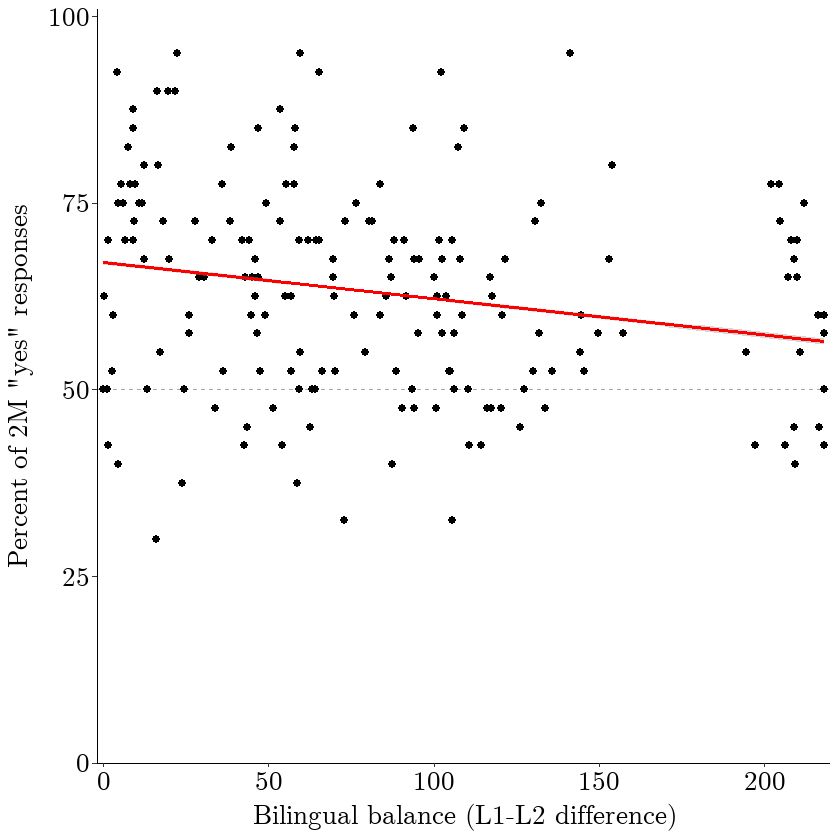

In [235]:
ggplot(data_BLP_testing, aes(x=L1_L2_diff,y=yes_2M)) +
  geom_hline(yintercept=50,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "Bilingual balance (L1-L2 difference)", y = 'Percent of 2M "yes" responses') +
  ylim(0,101) + 
  xlim(min(data_BLP_testing$L1_L2_diff)-2,max(data_BLP_testing$L1_L2_diff)+2) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

### 2M - Cosine Similarity

In [ ]:
lm_2M_cossim_nooutlier <- glmer(observed ~ scale(trialn) + expected*scale(cossim) + (1+expected|sbj_ID), data=data_BLP_testing[data_BLP_testing$testing_condition=='2M'&data_BLP_testing$score_2M>0.25,], family='binomial');
summary(lm_2M_cossim_nooutlier); # cossim sig (p=0.04); expected:cossim marg. sig (p=0.06)
# no longer sig when remove participant with lowest 2M score (22.5%)

In [ ]:
ggplot(data_BLP_testing, aes(x=cossim,y=score_2M)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "Multilingual balance (cosine similarity)", y = '2M accuracy') +
  ylim(0,1.1) + 
  xlim(min(data_BLP_testing$cossim)-0.01,max(data_BLP_testing$cossim)+0.01) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

In [ ]:
# without outlier
ggplot(data_BLP_testing[data_BLP_testing$score_2M>0.25,], aes(x=cossim,y=score_2M)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "Multilingual balance (cosine similarity) - no outlier", y = '2M accuracy') +
  ylim(0,1.1) + 
  xlim(min(data_BLP_testing$cossim)-0.01,max(data_BLP_testing$cossim)+0.01) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

In [ ]:
plot(data_BLP_testing$yes_2M~data_BLP_testing$cossim,pch=19,ylim=c(0,100),
     xlab="Multilingual balance (cosine similarity)",ylab='Percent of 2M "yes" responses',
     cex.lab=2,cex.axis=1.5);
abline(lm(data_BLP_testing$yes_2M~data_BLP_testing$cossim), col = "red",lwd=2);
abline(h=50,lty=5);

### 2M - Entropy

In [ ]:
ggplot(data_BLP_testing, aes(x=ent,y=score_2M)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "Multilingual balance (entropy)", y = '2M accuracy') +
  ylim(0,1.1) + 
  xlim(min(data_BLP_testing$ent)-0.1,max(data_BLP_testing$ent)+0.1) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="inside",legend.position.inside = c(0.85,0.09),
        legend.background=element_rect(fill=NA));

### 2M - Script

In [ ]:
ggplot(data_BLP_testing, aes(x=script,y=score_2M)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_boxplot(fill="darkgrey") +
  labs(x = "Script", y = '2M accuracy') +
  scale_x_discrete(labels=c('Same', 'Different')) +
  ylim(0,1.1) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

In [ ]:
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$script=='same'],mu=0.5);
#t=-1.72 p=0.09 CI=[0.48;0.50] df=155 -> marg. sig below chance
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$script=='diff/mixed'],mu=0.5);
# not enough x observations

In [ ]:
data_testing_2M_script_aggr <- data_BLP_testing %>% 
  mutate(correct01 = case_when(correct == TRUE ~ 1,
                               correct == FALSE ~ 0),
         yesno01 = case_when(observed == 'between_lang' ~ 0,
                             observed == 'within_lang' ~ 1)) %>% 
  filter(testing_condition == '2M') %>% 
  group_by(expected, sbj_ID, script) %>% 
  dplyr::summarise(meanCorrect = mean(correct01), se = sd(correct01/sqrt(n())),
                   meanYes = mean(yesno01), se = sd(yesno01/sqrt(n()))) %>% 
  mutate(meanNo = 1 - meanYes);
data_testing_2M_script_aggr <- data_testing_2M_script_aggr %>%
  pivot_longer(
    cols = c(meanYes, meanNo),
    names_to = "response",
    values_to = "meanValue"
  );

In [ ]:
ggplot(data_testing_2M_script_aggr[data_testing_2M_script_aggr$response=="meanYes",], aes(x=expected, y=meanValue, fill=script)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,width=1) +
  geom_boxplot(position=position_dodge(width=1),width=0.25) +
  scale_fill_manual(name="Script",labels=c('Same','Different'),values=c(cols2[400],cols2[310])) +
  scale_x_discrete(labels=c('Between-language', 'Within-language')) +
  labs(x = "String nature", y = 'Proportion of "within-language" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),legend.position="inside",
        legend.position.inside=c(0.1,0.1),legend.background=element_rect(fill=NA));

### 2M - Category

In [ ]:
ggplot(BLP_2Mscores, aes(x=category,y=score_2M)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_boxplot(fill="darkgrey") +
  labs(x = "Multilingual category", y = '2M accuracy') +
  scale_x_discrete(labels=c('Monolingual','Bilingual','Trilingual','Quadrilingual')) +
  ylim(0,1.1) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

In [ ]:
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$category=='mono'],mu=0.5);
#t=-1.78 p=0.09 CI=[0.42;0.51] df=21 est=0.46 -> marg. sig below chance
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$category=='bi'],mu=0.5);
#t=-0.31 p=0.76 CI=[0.48;0.51] df=69 est=0.50 -> non sig
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$category=='tri'],mu=0.5);
#t=-0.89 p=0.38 CI=[0.47;0.51] df=50 est=0.49 -> non sig
t.test(BLP_2Mscores$score_2M[BLP_2Mscores$category=='quadri'],mu=0.5);
#t=1.28 p=0.21 CI=[0.49;0.54] df=40 est=0.52 -> non sig

In [ ]:
t.test(BLP_2Mscores$dprime[BLP_2Mscores$category=='mono'],mu=0);
#t=-1.78 p=0.09 CI=[0.42;0.51] df=21 est=0.46 -> marg. sig below chance
t.test(BLP_2Mscores$dprime[BLP_2Mscores$category=='bi'],mu=0);
#t=-0.31 p=0.76 CI=[0.48;0.51] df=69 est=0.50 -> non sig
t.test(BLP_2Mscores$dprime[BLP_2Mscores$category=='tri'],mu=0);
#t=-0.89 p=0.38 CI=[0.47;0.51] df=50 est=0.49 -> non sig
t.test(BLP_2Mscores$dprime[BLP_2Mscores$category=='quadri'],mu=0);
#t=1.28 p=0.21 CI=[0.49;0.54] df=40 est=0.52 -> non sig

In [ ]:
data_testing_2M_category_aggr <- data_BLP_testing %>% 
  mutate(correct01 = case_when(correct == TRUE ~ 1,
                               correct == FALSE ~ 0),
         yesno01 = case_when(observed == 'between_lang' ~ 0,
                             observed == 'within_lang' ~ 1)) %>% 
  filter(testing_condition == '2M') %>% 
  group_by(expected, sbj_ID, category) %>% 
  dplyr::summarise(meanCorrect = mean(correct01), se = sd(correct01/sqrt(n())),
                   meanYes = mean(yesno01), se = sd(yesno01/sqrt(n()))) %>% 
  mutate(meanNo = 1 - meanYes);

In [ ]:
ggplot(data_testing_2M_category_aggr, aes(x=expected, y=meanCorrect, fill=expected)) +
  geom_hline(yintercept=0.5, linetype="dashed", color="darkgrey",lwd=1.25) +
  geom_violin(alpha=0.75,width=1) +
  
  geom_errorbar(aes(x=1,ymin=effect_2M$lower[[1]],ymax=effect_2M$upper[[1]]),
                width=.1) + # false alarm
  annotate("point",x=1,y=effect_2M$fit[[1]],colour="darkred",size=2) + # false alarm
  
  geom_errorbar(aes(x=2,ymin=effect_2M$lower[[2]],ymax=effect_2M$upper[[2]]),
                width=.1) + # hit
  annotate("point",x=2,y=effect_2M$fit[[2]],colour="lightblue",size=2) + # hit
  
  scale_fill_manual(values=c(cols2[100],cols2[200])) +
  scale_x_discrete(labels=c('Between-language', 'Within-language')) +
  labs(x = "String nature", y = 'Proportion of "yes" responses') +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.position="none",legend.background=element_rect(fill=NA))+
  facet_wrap(~category);

## Familiarity Responses

### Familiarity - PC9

In [ ]:
ggplot(data_BLP_familiarity, aes(x=RC9_use_L4,y=familiarity_mean)) +
  geom_hline(yintercept=0.50,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "PC9 (L4 Use)", y = 'Familiarity accuracy') +
  ylim(0,1) + 
  xlim(min(data_BLP_familiarity$RC9_use_L4)-0.1,max(data_BLP_familiarity$RC9_use_L4)+0.1) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

### Familiarity - Entropy

In [ ]:
BLP_fam <- data_BLP_familiarity[!duplicated(data_BLP_familiarity$sbj_ID), ];

In [ ]:
ggplot(data_BLP_familiarity, aes(x=ent,y=familiarity_mean)) +
  geom_hline(yintercept=0.50,linetype="dashed",color="darkgrey") +
  geom_point(size=2) +
  geom_smooth(method="lm",formula=y~x,color="red") +
  labs(x = "Multilingual balance (entropy)", y = 'Familiarity accuracy') +
  ylim(0,1) + 
  xlim(min(data_BLP_familiarity$ent)-0.1,max(data_BLP_familiarity$ent)+0.1) +
  coord_cartesian(expand = FALSE) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

### Familiarity - Category

In [ ]:
ggplot(data_BLP_familiarity, aes(x=category,y=fam_mean)) +
  geom_hline(yintercept=0.5,linetype="dashed",color="darkgrey") +
  geom_boxplot(fill="darkgrey") +
  labs(x = "Category", y = 'Familiarity accuracy') +
  scale_x_discrete(labels=c('Monolingual', 'Bilingual','Trilingual','Quadrilingual')) +
  ylim(min(data_BLP_familiarity$fam_mean)-0.05,max(data_BLP_familiarity$fam_mean)+0.05) +
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank(),
        panel.background = element_blank(), axis.line = element_line(colour = "black"),
        axis.text = element_text(family = "CMU Serif", size = 20, color = "black"),
        text=element_text(family="CMU Serif",size=20),
        legend.background=element_rect(fill=NA));

In [ ]:
t.test(BLP_fam$fam_mean[BLP_fam$category=='mono'],mu=0.5);
#t=3.85 p=0.001 CI=[0.54;0.64] df=21 est=0.59 -> sig above chance
t.test(BLP_fam$fam_mean[BLP_fam$category=='bi'],mu=0.5);
#t=6.65 p=5.64e-9 CI=[0.56;0.61] df=69 est=0.58 -> sig above chance
t.test(BLP_fam$fam_mean[BLP_fam$category=='tri'],mu=0.5);
#t=6.32 p=6.92e-8 CI=[0.55;0.60] df=50 est=0.58 -> sig above chance
t.test(BLP_fam$fam_mean[BLP_fam$category=='quadri'],mu=0.5);
#t=3.21 p=0.003 CI=[0.52;0.58] df=40 est=0.55 -> sig above chance

# Clustering Tree

In [ ]:
data_BLP_short <- subset(data_BLP, select=c(HistoryL1Score,HistoryL2Score,HistoryL3Score,HistoryL4Score,
                                            UseL1Score,UseL2Score,UseL3Score,UseL4Score,
                                            ProficiencyL1Score,ProficiencyL2Score,ProficiencyL3Score,ProficiencyL4Score,
                                            AttitudeL1Score,AttitudeL2Score,AttitudeL3Score,AttitudeL4Score,
                                            L1Score,L2Score,L3Score,L4Score,
                                            var,ent,use_ent,cossim,use_cossim,multiexp,L1_L2_diff,
                                            RC3_L3,RC1_L4,RC2_use_L1vsL2,RC7_hist_L2,RC9_use_L4));
plot(varclus(as.matrix(data_BLP_short)))